<a href="https://colab.research.google.com/github/LinaGarcia1/ProyectoGrado_MCIC-UD/blob/main/Codigos/Cauca/Dataset_imagenessatelitales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **ADQUISICIÓN DE VARIABLES ASOCIADAS A IMÁGENES SATELITALES**

In [ ]:
import os, numpy as np, pandas as pd, geopandas as gpd

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import fiona

path = '/content/drive/MyDrive/TESIS/DATASET_CAUCA/Dataset_FV2_210226.gpkg'
capas = fiona.listlayers(path)
print(f"Capas encontradas: {capas}")

Capas encontradas: ['eventos', 'ptsnodeslizamientos']


In [ ]:
df_positivos = gpd.read_file(path, layer='eventos')
df_negativos = gpd.read_file(path, layer='ptsnodeslizamientos')

In [ ]:
df_positivos.columns

Index(['OBJECTID', 'Código_SI', 'P0_evento', 'P1_excl', 'P3_excl', 'P5_excl',
       'P7_excl', 'P9_excl', 'P15_excl', 'P30_excl', 'P180_excl', 'Latitud__i',
       'Longitud__', 'Humedad_tr', 'Temperatur', 'Geologia_U', 'Elevacion',
       'Dist_vias', 'Dist_DD', 'Dist_Falla', 'CurvaturaN', 'CurvaturaT', 'TWI',
       'Eastness', 'Northness', 'Pendiente', 'Acum_flujo', 'Fecha_E',
       'geometry'],
      dtype='object')

In [ ]:
df_negativos.columns

Index(['OBJECTID', 'ID_NDES', 'Dist_vias', 'Dist_DD', 'Dist_Falla',
       'Geologia_U', 'Paisaje', 'Elevacion', 'CurvaturaN', 'CurvaturaT', 'TWI',
       'Eastness', 'Northness', 'Pendiente', 'Acum_flujo', 'PU_prob_oo',
       'Fecha_ref', 'P0_evento', 'P1_excl', 'P3_excl', 'P5_excl', 'P7_excl',
       'P9_excl', 'P15_excl', 'P30_excl', 'P180_excl', 'Humedad_T', 'Temp_T',
       'geometry'],
      dtype='object')

**Antes de generar la matriz maestra, se realizó la estandarización de nombres y formatos de las variables con el fin de garantizar la congruencia en la integración de las diferentes fuentes de información. Adicionalmente, se identificaron eventos duplicados que coincidían tanto en ubicación espacial (latitud y longitud) como en fecha de ocurrencia, los cuales corresponden a registros administrativos del mismo evento físico; por esta razón, se conservó un único registro por evento. Finalmente, se ajustó el conjunto de puntos de no deslizamiento con el propósito de equilibrar el dataset y reducir sesgos en las etapas posteriores de modelado.**

In [ ]:
# Renombrar columnas en los Negativos para que coincidan con los Positivos
df_negativos = df_negativos.rename(columns={
    'ID_NDES': 'Codigo',
    'Fecha_refe': 'Fecha_E',
})

# Renombrar columnas en los Positivos
df_positivos = df_positivos.rename(columns={
    'Código_SI': 'Codigo',
    'Fecha_refe': 'Fecha_E',
    'Latitud__i': 'Latitud',
    'Longitud__': 'Longitud',
    'Humedad_tr': 'Humedad_T',
    'Temperatur' : 'Temp_T'

})


In [ ]:
# Extraer Latitud y Longitud para los negativos desde la geometría (si no las tienen como columnas)
df_negativos = df_negativos.to_crs(epsg=4326)
df_positivos = df_positivos.to_crs(epsg=4326)

df_negativos['Latitud'] = df_negativos.geometry.y
df_negativos['Longitud'] = df_negativos.geometry.x

df_positivos['Latitud'] = df_positivos.geometry.y
df_positivos['Longitud'] = df_positivos.geometry.x

In [ ]:
df_positivos.columns

Index(['OBJECTID', 'Codigo', 'P0_evento', 'P1_excl', 'P3_excl', 'P5_excl',
       'P7_excl', 'P9_excl', 'P15_excl', 'P30_excl', 'P180_excl', 'Latitud',
       'Longitud', 'Humedad_T', 'Temp_T', 'Geologia_U', 'Elevacion',
       'Dist_vias', 'Dist_DD', 'Dist_Falla', 'CurvaturaN', 'CurvaturaT', 'TWI',
       'Eastness', 'Northness', 'Pendiente', 'Acum_flujo', 'Fecha_E',
       'geometry'],
      dtype='object')

In [ ]:
df_negativos.columns

Index(['OBJECTID', 'Codigo', 'Dist_vias', 'Dist_DD', 'Dist_Falla',
       'Geologia_U', 'Paisaje', 'Elevacion', 'CurvaturaN', 'CurvaturaT', 'TWI',
       'Eastness', 'Northness', 'Pendiente', 'Acum_flujo', 'PU_prob_oo',
       'Fecha_ref', 'P0_evento', 'P1_excl', 'P3_excl', 'P5_excl', 'P7_excl',
       'P9_excl', 'P15_excl', 'P30_excl', 'P180_excl', 'Humedad_T', 'Temp_T',
       'geometry', 'Latitud', 'Longitud'],
      dtype='object')

In [ ]:
df_positivos.head(5)[["Codigo", "Fecha_E", "Latitud", "Longitud"]]

,Codigo,Fecha_E,Latitud,Longitud
0,40407,2017-03-25,1.694591,-77.087096
1,40441,2017-03-31,1.694591,-77.087096
2,39557,2017-03-31,1.694591,-77.087096
3,40481,2017-04-20,1.854096,-76.963378
4,39588,2017-04-20,1.854096,-76.963378


In [ ]:
print("Registros totales:", len(df_positivos))

# Cantidad de eventos únicos
print(
    "Eventos únicos (Lat, Lon, Fecha):",
    df_positivos.drop_duplicates(
        subset=["Latitud", "Longitud", "Fecha_E"]
    ).shape[0]
)


Registros totales: 1499
Eventos únicos (Lat, Lon, Fecha): 1480


In [ ]:
# Respaldo de información duplicada

dup_respaldo = df_positivos[df_positivos.duplicated(
    subset=["Latitud", "Longitud", "Fecha_E"], keep=False
)]
dup_respaldo.to_csv(
    "/content/drive/MyDrive/TESIS/duplicados_eventos_reales_respaldo.csv",
    index=False
)


In [ ]:
# Tratamiento de eventos duplicados

df_positivos_limpio = (
    df_positivos
    .drop_duplicates(subset=["Latitud", "Longitud", "Fecha_E"], keep="first")
    .copy()
)

print("Antes:", len(df_positivos))
print("Después:", len(df_positivos_limpio))
print("Eliminados:", len(df_positivos) - len(df_positivos_limpio))

Antes: 1499
Después: 1480
Eliminados: 19


In [ ]:
# Verificación inicial
print("No deslizamientos antes:", len(df_negativos))

# Ordenar por probabilidad ascendente
df_negativos_sorted = df_negativos.sort_values(
    by="PU_prob_oo",
    ascending=False
)


No deslizamientos antes: 1499


In [ ]:

# Identificar los 19 registros a eliminar
df_eliminar = df_negativos_sorted.head(19)

# Mostrar códigos eliminados (trazabilidad)
print("Códigos eliminados:")
display(df_eliminar[["Codigo", "Latitud", "Longitud", "PU_prob_oo"]])

# Eliminar del dataset original
df_negativos_balanceado = df_negativos.drop(df_eliminar.index)
df_negativos_balanceado = df_negativos_balanceado.drop(columns=["PU_prob_oo"])

print("No deslizamientos después:", len(df_negativos_balanceado))


Códigos eliminados:


,Codigo,Latitud,Longitud,PU_prob_oo
787,5236,2.274364,-76.739701,0.609518
843,5920,2.591229,-76.091434,0.606389
790,5269,2.211478,-76.649698,0.598333
199,1249,2.053411,-77.216848,0.596726
1313,8120,3.035354,-76.383760,0.596064
160,873,1.811813,-77.068934,0.595000
171,986,2.049342,-77.226931,0.594070
31,214,1.499000,-76.548032,0.593294
334,2296,1.540701,-76.665147,0.591437
1436,9402,2.776010,-75.973001,0.590833


No deslizamientos después: 1480


In [ ]:
# ======================
# GUARDAR RESULTADOS
# ======================
GPKG_OUT='/content/drive/MyDrive/TESIS/DATASET_CAUCA/Dataset_FV2_210226.gpkg'
df_positivos_limpio.to_file(GPKG_OUT, layer="eventosf", driver="GPKG")
print("\nGuardado:", GPKG_OUT)

df_negativos_balanceado.to_file(GPKG_OUT, layer="ptsnodeslizamientosf", driver="GPKG")
print("\nGuardado:", GPKG_OUT)



Guardado: /content/drive/MyDrive/TESIS/DATASET_CAUCA/Dataset_FV2_210226.gpkg

Guardado: /content/drive/MyDrive/TESIS/DATASET_CAUCA/Dataset_FV2_210226.gpkg


In [ ]:
import fiona

path = '/content/drive/MyDrive/TESIS/DATASET_CAUCA/Dataset_FV2_210226.gpkg'
capas = fiona.listlayers(path)
print(f"Capas encontradas: {capas}")



Capas encontradas: ['eventos', 'ptsnodeslizamientos', 'ptsnodeslizamientosf', 'eventosf']


In [ ]:
df_positivos = gpd.read_file(path, layer='eventosf')
df_negativos = gpd.read_file(path, layer='ptsnodeslizamientosf')

/usr/local/lib/python3.12/dist-packages/pyogrio/raw.py:200: RuntimeWarning: Non-conformant content for record 1 in column Fecha_E, 2017-03-25T00:00:00.0Z, successfully parsed
  return ogr_read(


In [ ]:
# Añadir etiqueta: 1 para deslizamiento, 0 para no deslizamiento
df_positivos['clase'] = 1
df_negativos['clase'] = 0

In [ ]:
df_negativos = df_negativos.rename(columns={"Fecha_ref": "Fecha_E"})

In [ ]:
# Unir las dos tablas
columnas_comunes = df_positivos.columns.intersection(df_negativos.columns)
matriz_maestra = pd.concat([df_positivos[columnas_comunes], df_negativos[columnas_comunes]], axis=0)

In [ ]:
print(f"Matriz unificada con {matriz_maestra.shape[0]} filas y {matriz_maestra.shape[1]} columnas.")

Matriz unificada con 2960 filas y 30 columnas.


In [ ]:
matriz_maestra.head(2)

,Codigo,P0_evento,P1_excl,P3_excl,P5_excl,P7_excl,P9_excl,P15_excl,P30_excl,P180_excl,...,Elevacion,CurvaturaN,CurvaturaT,TWI,Eastness,Northness,Pendiente,Acum_flujo,geometry,clase
0,40407,5.716318,2.570153,28.335768,71.649261,76.618492,83.014481,169.734161,341.425934,1687.828003,...,1590,-0.005164,-0.00117,5.094604,-0.905066,0.425272,20.912285,0.69897,POINT (-77.0871 1.69459),1
1,40441,11.618964,40.066071,54.249153,68.398132,76.684601,102.450218,157.128922,364.965820,1713.425659,...,1590,-0.005164,-0.00117,5.094604,-0.905066,0.425272,20.912285,0.69897,POINT (-77.0871 1.69459),1


In [ ]:
matriz_maestra.columns

Index(['Codigo', 'P0_evento', 'P1_excl', 'P3_excl', 'P5_excl', 'P7_excl',
       'P9_excl', 'P15_excl', 'P30_excl', 'P180_excl', 'Latitud', 'Longitud',
       'Humedad_T', 'Temp_T', 'Fecha_E', 'Dist_vias', 'Dist_DD', 'Dist_Falla',
       'Geologia_U', 'Paisaje', 'Elevacion', 'CurvaturaN', 'CurvaturaT', 'TWI',
       'Eastness', 'Northness', 'Pendiente', 'Acum_flujo', 'geometry',
       'clase'],
      dtype='object')

In [ ]:
matriz_maestra.to_file('/content/drive/MyDrive/TESIS/DATASET_CAUCA/Final210226.gpkg', layer="DatasetFinal", driver="GPKG")
print("\nGuardado:", '/content/drive/MyDrive/TESIS/DATASET_CAUCA/DATASET/Final210226.gpkg')


Guardado: /content/drive/MyDrive/TESIS/DATASET_CAUCA/DATASET/Final210226.gpkg


## **Manejo de imágenes con conexión con GEE**

**En esta sección se establece la conexión entre Google Colab y Google Earth Engine (GEE), con el fin de acceder de manera remota a imágenes satelitales capturadas por distintos sensores remotos. Esto permite consultar y procesar series temporales de datos ópticos y radar provenientes de misiones como Landsat, Sentinel-2 y Sentinel-1, sin necesidad de descarga local de los datos. A partir de este Script, se extraen variables espectrales y de retrodispersión asociadas a la ubicación y fecha de ocurrencia de cada evento, utilizando ventanas temporales retrospectivas y resúmenes estadísticos en áreas buffer alrededor de los puntos de análisis, con el objetivo de caracterizar las condiciones ambientales previas a la ocurrencia de los eventos.**

In [ ]:
# =====================================
# Instalación de Librerías y recursos
# =====================================

!pip -q install earthengine-api geemap geopandas fiona pyproj shapely

import ee, geemap
import geopandas as gpd
import pandas as pd
from google.colab import drive
import pprint

# 1) Coneión con Drive

drive.mount('/content/drive')

# 2) Autenticación e inicialización de Earth Engine

ee.Authenticate()
ee.Initialize(project="ee-linapaolagarcia")
print("GEE listo ✅")



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 19.9 MB/s eta 0:00:00
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
GEE listo ✅


In [ ]:
# -----------------------------
# Lectura GPGK - Dataset final
# -----------------------------
gpkg_path  = "/content/drive/MyDrive/TESIS/DATASET_CAUCA/Final210226.gpkg"
layer_name = "DatasetFinal"

gdf = gpd.read_file(gpkg_path, layer=layer_name)
print("CRS original:", gdf.crs)

# Asegurar CRS WGS84
gdf = gdf.to_crs(epsg=4326)

# Lat/Lon desde geometry "Actualiza Lat y Lon de acuerdo al CRS"
gdf["Longitud"] = gdf.geometry.x
gdf["Latitud"]  = gdf.geometry.y

# Mantuene columnas mínimas
gdf = gdf[["Codigo", "Fecha_E", "Latitud", "Longitud", "geometry"]].copy()

# Tipos
gdf["Codigo"]   = gdf["Codigo"].astype(str)
gdf["Fecha_E"]  = gdf["Fecha_E"].astype(str).str.strip()
gdf["Latitud"]  = gdf["Latitud"].astype(float)
gdf["Longitud"] = gdf["Longitud"].astype(float)


# Normalizar fechas a YYYY-MM-DD (soporta 'YYYY-MM-DD HH:MM:SS' y '5/10/2005')
# First attempt to parse dates
dt1_attempt1 = pd.to_datetime(gdf["Fecha_E"], errors="coerce")

# Second attempt, trying with dayfirst=True for any remaining NaT values
dt1_attempt2 = pd.to_datetime(gdf["Fecha_E"], errors="coerce", dayfirst=True)

# Combine results, filling NaT values from attempt1 with valid dates from attempt2
dt_combined = dt1_attempt1.fillna(dt1_attempt2)

# Check for any remaining bad dates
bad_dates = dt_combined.isna().sum()
if bad_dates > 0:
    print(f"⚠️ Fechas no interpretables: {bad_dates}")
    print("Ejemplos:", gdf.loc[dt_combined.isna(), "Fecha_E"].head(10).tolist())

gdf["Fecha_E"] = dt_combined.dt.strftime("%Y-%m-%d")
gdf = gdf.dropna(subset=["Fecha_E"]).copy()

# Listado de fechas adecuadas.
print("Filas finales (fecha válida):", len(gdf))
display(gdf.head(3))


CRS original: EPSG:4326
Filas finales (fecha válida): 2960


/tmp/ipython-input-3321664284.py:32: UserWarning: Parsing dates in %Y-%m-%d %H:%M:%S%z format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  dt1_attempt2 = pd.to_datetime(gdf["Fecha_E"], errors="coerce", dayfirst=True)


,Codigo,Fecha_E,Latitud,Longitud,geometry
0,40407,2017-03-25,1.694591,-77.087096,POINT (-77.0871 1.69459)
1,40441,2017-03-31,1.694591,-77.087096,POINT (-77.0871 1.69459)
2,40481,2017-04-20,1.854096,-76.963378,POINT (-76.96338 1.8541)


In [ ]:
# -----------------------------
# GENERAR FEATURECOLLECTION
# -----------------------------
def to_ee_feature(row):
    pt = ee.Geometry.Point([row["Longitud"], row["Latitud"]])
    return ee.Feature(pt, {
        "Codigo": row["Codigo"],
        "Fecha_E": row["Fecha_E"]
    })

features = [to_ee_feature(r) for _, r in gdf.iterrows()]
fc = ee.FeatureCollection(features)

print("N puntos (GEE):", fc.size().getInfo())
print("Ejemplo:", fc.first().toDictionary().getInfo())



N puntos (GEE): 2960
Ejemplo: {'Codigo': '40407', 'Fecha_E': '2017-03-25'}


**Primera prueba con valores de buffer_(90m), ventanas temporales tanto para imágenes Ópticas como de Radar**

In [ ]:
# 5) Parámetros

SCALE    = 30     # 30 m
BUFFER_M = 90     # Aumenta coincidencia (promedia más píxeles)
OPT_DAYS = 90     # Aumenta coincidencia óptica (nubosidad) / Ventana temporal óptica
SAR_DAYS = 24     # Aumenta coincidencia SAR / 24 / Ventana temporal SAR

#-----------------------------------
# Imágenes Satelitáles ópticas
#-----------------------------------

# Se utilizará Sentinel-2 en caso de que no exista en Landsat.

def get_optical_indices(geom, d):
    start = d.advance(-OPT_DAYS, "day")
    year  = ee.Number(d.get("year"))
    use_s2 = year.gte(2015)

    # ---------- LANDSAT ----------
    # Construcción de colección Landsat
    col_ls = (ee.ImageCollection("LANDSAT/LT05/C02/T1_L2")
              .merge(ee.ImageCollection("LANDSAT/LE07/C02/T1_L2"))
              .merge(ee.ImageCollection("LANDSAT/LC08/C02/T1_L2"))
              .merge(ee.ImageCollection("LANDSAT/LC09/C02/T1_L2"))
              .filterBounds(geom).filterDate(start, d))

    def prep_landsat(img):
        # Máscara nubes/shadows/cirrus con QA_PIXEL
        qa = img.select("QA_PIXEL")
        mask = (qa.bitwiseAnd(1<<3).eq(0)        # cloud
                .And(qa.bitwiseAnd(1<<4).eq(0))  # cloud shadow
                .And(qa.bitwiseAnd(1<<2).eq(0))) # cirrus

        # Detectar L8/L9 por presencia de SR_B6
        # (L7/L5 no tienen SR_B6 en C2 L2)
        isL8 = img.bandNames().contains("SR_B6")

        # BLUE:  L8/L9 SR_B2 | L5/L7 SR_B1
        blue = ee.Image(ee.Algorithms.If(isL8, img.select("SR_B2"), img.select("SR_B1")))
        # RED:   L8/L9 SR_B4 | L5/L7 SR_B3
        red  = ee.Image(ee.Algorithms.If(isL8, img.select("SR_B4"), img.select("SR_B3")))
        # NIR:   L8/L9 SR_B5 | L5/L7 SR_B4
        nir  = ee.Image(ee.Algorithms.If(isL8, img.select("SR_B5"), img.select("SR_B4")))
        # SWIR1: L8/L9 SR_B6 | L5/L7 SR_B5
        sw1  = ee.Image(ee.Algorithms.If(isL8, img.select("SR_B6"), img.select("SR_B5")))
        # SWIR2: todos SR_B7
        sw2  = img.select("SR_B7")


        # Escalado reflectancia Landsat C2 L2
        def sc(x): return x.multiply(0.0000275).add(-0.2)
        blue, red, nir, sw1, sw2 = sc(blue), sc(red), sc(nir), sc(sw1), sc(sw2)

        # Calculo de índices

        # NDVI= (NIR-RED)/(NIR+RED)- Índice de Vegetación de Diferencia Normalizada.
        ndvi = nir.subtract(red).divide(nir.add(red)).rename("NDVI")

        # NDWI= (NIR-SWIR)/(NIR+SWIR) - Índice de Diferencia Normalizada de Agua
        ndwi = nir.subtract(sw1).divide(nir.add(sw1)).rename("NDWI")

        # NBR= (NIR-SWIR2)/(NIR+SWIR2) Índice Normalizado de Área Quemada (NBR)
        nbr  = nir.subtract(sw2).divide(nir.add(sw2)).rename("NBR")

        # EVI = 2.5*(NIR-RED)/(NIR + 6*RED - 7.5*BLUE + 1) – Índice de Vegetación Mejorado
        evi  = (nir.subtract(red).multiply(2.5)
                .divide(nir.add(red.multiply(6)).subtract(blue.multiply(7.5)).add(1))
                .rename("EVI"))

        return ndvi.addBands([ndwi, nbr, evi]).updateMask(mask)

    # Mediana de la colección Landsat
    ls_img = col_ls.map(prep_landsat).median()

    reducer = ee.Reducer.mean().combine(ee.Reducer.stdDev(), sharedInputs=True)

    ls_stats = ls_img.reduceRegion(
        reducer=reducer,
        geometry=geom,
        scale=SCALE,
        maxPixels=1e13
    )

    # ---------- CASO SENTINEL-2  ----------
    col_s2 = (ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
              .filterBounds(geom).filterDate(start, d)
              .filter(ee.Filter.lt("CLOUDY_PIXEL_PERCENTAGE", 80)))

    def mask_s2(img):
        scl = img.select("SCL")
        # Remover sombras/nubes/cirrus/nieve
        good = (scl.neq(3)
                .And(scl.neq(8))
                .And(scl.neq(9))
                .And(scl.neq(10))
                .And(scl.neq(11)))
        return img.updateMask(good)

    # Selección de bandas propias de Sentinel
    def prep_s2(img):
        img = mask_s2(img)
        blue = img.select("B2")
        red  = img.select("B4")
        nir  = img.select("B8")
        sw1  = img.select("B11")
        sw2  = img.select("B12")

        # Calculo de Indices, aplicando las mismas formulas que en el caso de
        # Landsat

        ndvi = nir.subtract(red).divide(nir.add(red)).rename("NDVI")
        ndwi = nir.subtract(sw1).divide(nir.add(sw1)).rename("NDWI")
        nbr  = nir.subtract(sw2).divide(nir.add(sw2)).rename("NBR")
        evi  = (nir.subtract(red).multiply(2.5)
                .divide(nir.add(red.multiply(6)).subtract(blue.multiply(7.5)).add(1))
                .rename("EVI"))
        return ndvi.addBands([ndwi, nbr, evi])

    s2_img = col_s2.map(prep_s2).median() # Generación de un compuesto multitemporal Sentinel-2

    # Extracción de estadísticas
    s2_stats = s2_img.reduceRegion(
        reducer=reducer,
        geometry=geom,
        scale=SCALE,      # forzar a 30 m
        maxPixels=1e13
    )

    ls_stats = ee.Dictionary(ls_stats)
    s2_stats = ee.Dictionary(s2_stats)

    def pick(name):
        # buscamos por llaves del reducer combinado
        has_ls = ls_stats.contains(name + "_mean") #Indice en Landsat
        has_s2 = s2_stats.contains(name + "_mean") # Indice en Sentinel

        mean = ee.Algorithms.If(has_ls, ls_stats.get(name + "_mean"),
               ee.Algorithms.If(use_s2, s2_stats.get(name + "_mean"), None))
        std  = ee.Algorithms.If(has_ls, ls_stats.get(name + "_stdDev"),
               ee.Algorithms.If(use_s2, s2_stats.get(name + "_stdDev"), None))

        src = ee.Algorithms.If(has_ls, "landsat",
              ee.Algorithms.If(use_s2,
                ee.Algorithms.If(has_s2, "s2", "missing"),
              "missing"))
        return ee.Dictionary({"mean": mean, "std": std, "src": src})

    ndvi = pick("NDVI")
    ndwi = pick("NDWI")
    nbr  = pick("NBR")
    evi  = pick("EVI")

    # Fuente óptica final: basada en NDVI (si NDVI está, asumimos óptico usable)
    opt_src = ndvi.get("src")

    # Bloque qie empaqueta toda las variables en un ee.Dictionary necesario para construir
    # posteriormente el CSV
    return ee.Dictionary({
        "OPT_src": opt_src,
        "NDVI_mean": ndvi.get("mean"), "NDVI_std": ndvi.get("std"),
        "NDWI_mean": ndwi.get("mean"), "NDWI_std": ndwi.get("std"),
        "NBR_mean":  nbr.get("mean"),  "NBR_std":  nbr.get("std"),
        "EVI_mean":  evi.get("mean"),  "EVI_std":  evi.get("std"),
    })

# ----------------------------------
# Imágenes de Radar SAR
# VV, VH (mean+std) + diff + ratio
# ---------------------------------

# Extracción de imágenes Satelitales Sentinel 1
def get_s1_sar(geom, d):
    start = d.advance(-SAR_DAYS, "day")

# Construcción de colección Sentinel 1 teniendo en cuenta la
# Cobertua espaciañ, temporal, el modo de adquisición, las
# bandas VV, VH.
    s1_col = (ee.ImageCollection("COPERNICUS/S1_GRD")
              .filterBounds(geom)
              .filterDate(start, d)
              .filter(ee.Filter.eq("instrumentMode", "IW"))
              .filter(ee.Filter.listContains("transmitterReceiverPolarisation", "VV"))
              .filter(ee.Filter.listContains("transmitterReceiverPolarisation", "VH"))
              .select(["VV","VH"]))

# Compuesto multitemporal SAR
    s1_img = s1_col.median()

    reducer = ee.Reducer.mean().combine(ee.Reducer.stdDev(), sharedInputs=True)

    # Extracción de estadísticas zonales
    stats = ee.Dictionary(
        s1_img.reduceRegion(
            reducer=reducer,
            geometry=geom,
            scale=SCALE,
            maxPixels=1e13
        )
    )

    # Verificación de resultados en el diccionario
    hasVV = stats.contains("VV_mean")
    hasVH = stats.contains("VH_mean")

  # Si el valor existe → se extrae del diccionario (stats.get)
  # Si no existe → se asigna None

    vv_mean = ee.Algorithms.If(hasVV, stats.get("VV_mean"), None)
    vh_mean = ee.Algorithms.If(hasVH, stats.get("VH_mean"), None)
    vv_std  = ee.Algorithms.If(stats.contains("VV_stdDev"), stats.get("VV_stdDev"), None)
    vh_std  = ee.Algorithms.If(stats.contains("VH_stdDev"), stats.get("VH_stdDev"), None)

    # Detecta si falta VV o VH
    miss_vv = ee.Number(ee.Algorithms.If(ee.Algorithms.IsEqual(vv_mean, None), 1, 0))
    miss_vh = ee.Number(ee.Algorithms.If(ee.Algorithms.IsEqual(vh_mean, None), 1, 0))
    missing_any = miss_vv.add(miss_vh).gt(0)

    # Calcula variables derivadas solo si hay datos completos
    vv_minus_vh = ee.Algorithms.If(missing_any, None, ee.Number(vv_mean).subtract(ee.Number(vh_mean))) # Diferencia (VV − VH)
    vv_div_vh   = ee.Algorithms.If(missing_any, None, ee.Number(vv_mean).divide(ee.Number(vh_mean))) # VV / VH

    # Verifica la disponibilidad simultánea de ambas polarizaciones SAR (VV y VH);
    # hasBoth = 1 solo si existen valores válidos para VV y VH, de lo contrario 0
    hasBoth = ee.Number(ee.Algorithms.If(hasVV, 1, 0)).multiply(
        ee.Number(ee.Algorithms.If(hasVH, 1, 0))
    )

    # Clasifica la disponibilidad del dato SAR:
    # "real"    → existen imágenes Sentinel-1 y ambas polarizaciones (VV y VH) son válidas
    # "masked"  → existen imágenes, pero falta al menos una polarización en la geometría
    # "missing" → no existen imágenes SAR en la ventana temporal definida
    sar_src = ee.Algorithms.If(
        s1_col.size().gt(0),
        ee.Algorithms.If(hasBoth.eq(1), "real", "masked"),
        "missing"
    )

    # construye y retorna el resultado final de la función SAR en un Diccionario.
    return ee.Dictionary({
        "SAR_type": "S1",
        "SAR_src":  sar_src,
        "VV_mean": vv_mean, "VV_std": vv_std,
        "VH_mean": vh_mean, "VH_std": vh_std,
        "VVminusVH": vv_minus_vh,
        "VVdivVH":   vv_div_vh
    })

# -------------------------------------
# Asignación de variables a cada punto
# -------------------------------------
def extract_all_data(feat):
    # Fecha ya viene como 'YYYY-MM-DD' desde pandas
    d = ee.Date(ee.String(feat.get("Fecha_E")))
    geom = feat.geometry().buffer(BUFFER_M)

    opt = get_optical_indices(geom, d)
    sar = get_s1_sar(geom, d)

    return feat.set({
        "date_str": d.format("YYYY-MM-dd"),

        # Óptico
        "OPT_src": opt.get("OPT_src"),
        f"NDVI_mean_{OPT_DAYS}d_30m": opt.get("NDVI_mean"),
        f"NDVI_std_{OPT_DAYS}d_30m":  opt.get("NDVI_std"),
        f"NDWI_mean_{OPT_DAYS}d_30m": opt.get("NDWI_mean"),
        f"NDWI_std_{OPT_DAYS}d_30m":  opt.get("NDWI_std"),
        f"NBR_mean_{OPT_DAYS}d_30m":  opt.get("NBR_mean"),
        f"NBR_std_{OPT_DAYS}d_30m":   opt.get("NBR_std"),
        f"EVI_mean_{OPT_DAYS}d_30m":  opt.get("EVI_mean"),
        f"EVI_std_{OPT_DAYS}d_30m":   opt.get("EVI_std"),

        # SAR
        "SAR_type": sar.get("SAR_type"),
        "SAR_src":  sar.get("SAR_src"),
        f"VV_mean_{SAR_DAYS}d_30m": sar.get("VV_mean"),
        f"VV_std_{SAR_DAYS}d_30m":  sar.get("VV_std"),
        f"VH_mean_{SAR_DAYS}d_30m": sar.get("VH_mean"),
        f"VH_std_{SAR_DAYS}d_30m":  sar.get("VH_std"),
        f"VVminusVH_{SAR_DAYS}d_30m": sar.get("VVminusVH"),
        f"VVdivVH_{SAR_DAYS}d_30m":   sar.get("VVdivVH"),
    }) # Añade  variables extraídas cpmp atributos de cada punto


#} Ejemplo de funcionamiento del código con 5 puntos

print("Prueba con 5 puntos...")
muestra5 = ee.FeatureCollection(fc.toList(5)).map(extract_all_data)
pprint.pprint(muestra5.first().toDictionary().getInfo())

#  Aplicación de la función de asignación a toda la colección

fc_out = fc.map(extract_all_data)

print("Verificando primer punto completo...")
pprint.pprint(fc_out.first().toDictionary().getInfo())

task = ee.batch.Export.table.toDrive(
    collection=fc_out,
    description="sat_features_optLS_S2_SAR_S1_30m_V3210206",
    folder="TESIS_GEE",
    fileFormat="CSV"
)
task.start()

print("Exportación iniciada ✅")
print("Busca en Google Drive → carpeta 'TESIS_GEE' (si no existe, se crea).")
print("Progreso: Earth Engine Code Editor → pestaña Tasks.")


Prueba con 5 puntos...
{'Codigo': '40407',
 'EVI_mean_90d_30m': 0.43841422606618224,
 'EVI_std_90d_30m': 0.12713359267346533,
 'Fecha_E': '2017-03-25',
 'NBR_mean_90d_30m': 0.5981894883909956,
 'NBR_std_90d_30m': 0.08483414097327582,
 'NDVI_mean_90d_30m': 0.7594935868492348,
 'NDVI_std_90d_30m': 0.05433443373993235,
 'NDWI_mean_90d_30m': 0.3038677569152868,
 'NDWI_std_90d_30m': 0.07469515419243636,
 'OPT_src': 'landsat',
 'SAR_src': 'real',
 'SAR_type': 'S1',
 'VH_mean_24d_30m': -14.12472557129295,
 'VH_std_24d_30m': 1.8246300922672791,
 'VV_mean_24d_30m': -8.561637811268163,
 'VV_std_24d_30m': 2.929880460736421,
 'VVdivVH_24d_30m': 0.6061454269008107,
 'VVminusVH_24d_30m': 5.563087760024787,
 'date_str': '2017-03-25'}
Verificando primer punto completo...
{'Codigo': '40407',
 'EVI_mean_90d_30m': 0.43841422606618224,
 'EVI_std_90d_30m': 0.12713359267346533,
 'Fecha_E': '2017-03-25',
 'NBR_mean_90d_30m': 0.5981894883909956,
 'NBR_std_90d_30m': 0.08483414097327582,
 'NDVI_mean_90d_30m': 0

**En este código se busca la misma finalidad del anterior, sin embargo es más  robusto. Antes de procesar la totalidad de los datos, realiza una "auditoría" automática con una muestra pequeña para probar diferentes configuraciones y elegir matemáticamente la que ofrezca mayor disponibilidad de imágenes. Además, incorpora mecanismos de seguridad avanzados: si el satélite principal (Sentinel-1) falla, busca automáticamente un respaldo (ALOS PALSAR), y aplica filtros estrictos para asegurar que solo se guarden datos con suficiente información válida.**

In [ ]:

# 5) PARÁMETROS BASE (ESCALA FIJA)
SCALE = 30  # 30 m (homogeneidad)

#--------------------------------------
# Imágenes Satelitáles ópticas
#--------------------------------------

# Se utilizará Sentinel-2 en caso de que no exista en Landsat.

def get_optical_indices(geom, d, opt_days):
    start = d.advance(-opt_days, "day")
    year  = ee.Number(d.get("year"))
    use_s2 = year.gte(2015)

    # ---------- LANDSAT ----------
    # Construcción de colección Landsat

    col_ls = (ee.ImageCollection("LANDSAT/LT05/C02/T1_L2")
              .merge(ee.ImageCollection("LANDSAT/LE07/C02/T1_L2"))
              .merge(ee.ImageCollection("LANDSAT/LC08/C02/T1_L2"))
              .merge(ee.ImageCollection("LANDSAT/LC09/C02/T1_L2"))
              .filterBounds(geom).filterDate(start, d))

    def prep_landsat(img):
        # Máscara nubes/shadows/cirrus con QA_PIXEL
        qa = img.select("QA_PIXEL")
        mask = (qa.bitwiseAnd(1<<3).eq(0)        # cloud
                .And(qa.bitwiseAnd(1<<4).eq(0))  # cloud shadow
                .And(qa.bitwiseAnd(1<<2).eq(0))) # cirrus

        # Detectar L8/L9 por presencia de SR_B6 (L7/L5 no tienen SR_B6 en C2 L2)
        isL8 = img.bandNames().contains("SR_B6")

        # Mapeo de bandas según sensor

        # BLUE:  L8/L9 SR_B2 | L5/L7 SR_B1
        blue = ee.Image(ee.Algorithms.If(isL8, img.select("SR_B2"), img.select("SR_B1")))
        # RED:   L8/L9 SR_B4 | L5/L7 SR_B3
        red  = ee.Image(ee.Algorithms.If(isL8, img.select("SR_B4"), img.select("SR_B3")))
        # NIR:   L8/L9 SR_B5 | L5/L7 SR_B4
        nir  = ee.Image(ee.Algorithms.If(isL8, img.select("SR_B5"), img.select("SR_B4")))
        # SWIR1: L8/L9 SR_B6 | L5/L7 SR_B5
        sw1  = ee.Image(ee.Algorithms.If(isL8, img.select("SR_B6"), img.select("SR_B5")))
        # SWIR2: todos SR_B7
        sw2  = img.select("SR_B7")

        # Escalado reflectancia Landsat C2 L2
        def sc(x): return x.multiply(0.0000275).add(-0.2)
        blue, red, nir, sw1, sw2 = sc(blue), sc(red), sc(nir), sc(sw1), sc(sw2)

        # Calculo de índices
        # NDVI= (NIR-RED)/(NIR+RED)- Índice de Vegetación de Diferencia Normalizada.
        ndvi = nir.subtract(red).divide(nir.add(red)).rename("NDVI")

        # NDWI= (NIR-SWIR)/(NIR+SWIR) - Índice de Diferencia Normalizada de Agua
        ndwi = nir.subtract(sw1).divide(nir.add(sw1)).rename("NDWI")

        # NBR= (NIR-SWIR2)/(NIR+SWIR2) Índice Normalizado de Área Quemada (NBR)
        nbr  = nir.subtract(sw2).divide(nir.add(sw2)).rename("NBR")

        # EVI = 2.5*(NIR-RED)/(NIR + 6*RED - 7.5*BLUE + 1) – Índice de Vegetación Mejorado
        evi  = (nir.subtract(red).multiply(2.5)
                .divide(nir.add(red.multiply(6)).subtract(blue.multiply(7.5)).add(1))
                .rename("EVI"))

        return ndvi.addBands([ndwi, nbr, evi]).updateMask(mask)

    # Mediana de la colección Landsat

    ls_img = col_ls.map(prep_landsat).median()
    reducer = ee.Reducer.mean().combine(ee.Reducer.stdDev(), sharedInputs=True)

    ls_stats = ee.Dictionary(ls_img.reduceRegion(
        reducer=reducer,
        geometry=geom,
        scale=SCALE,
        maxPixels=1e13
    ))

    # --------------------  CASO SENTINEL-2 --------------
    col_s2 = (ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
              .filterBounds(geom).filterDate(start, d)
              .filter(ee.Filter.lt("CLOUDY_PIXEL_PERCENTAGE", 80)))

    def mask_s2(img):
        scl = img.select("SCL")
        # Remover sombras/nubes/cirrus/nieve
        good = (scl.neq(3)
                .And(scl.neq(8))
                .And(scl.neq(9))
                .And(scl.neq(10))
                .And(scl.neq(11)))
        return img.updateMask(good)

    # Selección de bandas propias de Sentinel
    def prep_s2(img):
        img = mask_s2(img)
        blue = img.select("B2")
        red  = img.select("B4")
        nir  = img.select("B8")
        sw1  = img.select("B11")
        sw2  = img.select("B12")


        # Calculo de Indices, aplicando las mismas formulas que en el caso de
        # Landsat
        ndvi = nir.subtract(red).divide(nir.add(red)).rename("NDVI")
        ndwi = nir.subtract(sw1).divide(nir.add(sw1)).rename("NDWI")
        nbr  = nir.subtract(sw2).divide(nir.add(sw2)).rename("NBR")
        evi  = (nir.subtract(red).multiply(2.5)
                .divide(nir.add(red.multiply(6)).subtract(blue.multiply(7.5)).add(1))
                .rename("EVI"))
        return ndvi.addBands([ndwi, nbr, evi])

    s2_img = col_s2.map(prep_s2).median() # Generación de un compuesto multitemporal Sentinel-2

    # Extracción de estadísticas
    s2_stats = ee.Dictionary(s2_img.reduceRegion(
        reducer=reducer,
        geometry=geom,
        scale=SCALE,      # forzar a 30 m
        maxPixels=1e13
    ))

    def pick(name):
        has_ls = ls_stats.contains(name + "_mean")
        has_s2 = s2_stats.contains(name + "_mean")

        mean = ee.Algorithms.If(has_ls, ls_stats.get(name + "_mean"),
               ee.Algorithms.If(use_s2, s2_stats.get(name + "_mean"), None))
        std  = ee.Algorithms.If(has_ls, ls_stats.get(name + "_stdDev"),
               ee.Algorithms.If(use_s2, s2_stats.get(name + "_stdDev"), None))

        src = ee.Algorithms.If(has_ls, "landsat",
              ee.Algorithms.If(use_s2,
                ee.Algorithms.If(has_s2, "s2", "missing"),
              "missing"))
        return ee.Dictionary({"mean": mean, "std": std, "src": src})

    ndvi = pick("NDVI")
    ndwi = pick("NDWI")
    nbr  = pick("NBR")
    evi  = pick("EVI")

    opt_src = ndvi.get("src")

    return ee.Dictionary({
        "OPT_src": opt_src,
        "NDVI_mean": ndvi.get("mean"), "NDVI_std": ndvi.get("std"),
        "NDWI_mean": ndwi.get("mean"), "NDWI_std": ndwi.get("std"),
        "NBR_mean":  nbr.get("mean"),  "NBR_std":  nbr.get("std"),
        "EVI_mean":  evi.get("mean"),  "EVI_std":  evi.get("std"),
    })

# ----------------------------------
# Imágenes de Radar SAR
# VV, VH (mean+std) + diff + ratio
# ---------------------------------

# Extracción de imágenes Satelitales Sentinel 1
def get_s1_sar(geom, d, sar_days):
    start = d.advance(-sar_days, "day")


# Construcción de colección Sentinel 1 teniendo en cuenta la
# Cobertua espacial, temporal, el modo de adquisición, las
# bandas VV, VH.

    s1_col = (ee.ImageCollection("COPERNICUS/S1_GRD")
              .filterBounds(geom)
              .filterDate(start, d)
              .filter(ee.Filter.eq("instrumentMode", "IW"))
              .filter(ee.Filter.listContains("transmitterReceiverPolarisation", "VV"))
              .filter(ee.Filter.listContains("transmitterReceiverPolarisation", "VH"))
              .select(["VV","VH"]))

    # Compuesto multitemporal SAR

    s1_img = s1_col.median()
    reducer = ee.Reducer.mean().combine(ee.Reducer.stdDev(), sharedInputs=True)

    # Extracción de estadísticas zonales
    stats = ee.Dictionary(
        s1_img.reduceRegion(
            reducer=reducer,
            geometry=geom,
            scale=SCALE,
            maxPixels=1e13
        )
    )

    # Verificación de resultados en el diccionario
    hasVV = stats.contains("VV_mean")
    hasVH = stats.contains("VH_mean")

    # Si el valor existe → se extrae del diccionario (stats.get)
    # Si no existe → se asigna None
    vv_mean = ee.Algorithms.If(hasVV, stats.get("VV_mean"), None)
    vh_mean = ee.Algorithms.If(hasVH, stats.get("VH_mean"), None)
    vv_std  = ee.Algorithms.If(stats.contains("VV_stdDev"), stats.get("VV_stdDev"), None)
    vh_std  = ee.Algorithms.If(stats.contains("VH_stdDev"), stats.get("VH_stdDev"), None)

    # Detecta si falta VV o VH
    miss_vv = ee.Number(ee.Algorithms.If(ee.Algorithms.IsEqual(vv_mean, None), 1, 0))
    miss_vh = ee.Number(ee.Algorithms.If(ee.Algorithms.IsEqual(vh_mean, None), 1, 0))
    missing_any = miss_vv.add(miss_vh).gt(0)

    # Calcula variables derivadas solo si hay datos completos
    vv_minus_vh = ee.Algorithms.If(missing_any, None, ee.Number(vv_mean).subtract(ee.Number(vh_mean)))
    vv_div_vh   = ee.Algorithms.If(missing_any, None, ee.Number(vv_mean).divide(ee.Number(vh_mean)))

    # Verifica la disponibilidad simultánea de ambas polarizaciones SAR (VV y VH);
    # hasBoth = 1 solo si existen valores válidos para VV y VH, de lo contrario 0
    hasBoth = ee.Number(ee.Algorithms.If(hasVV, 1, 0)).multiply(
        ee.Number(ee.Algorithms.If(hasVH, 1, 0))
    )

    # Clasifica la disponibilidad del dato SAR:
    # "real"    → existen imágenes Sentinel-1 y ambas polarizaciones (VV y VH) son válidas
    # "masked"  → existen imágenes, pero falta al menos una polarización en la geometría
    # "missing" → no existen imágenes SAR en la ventana temporal definida

    sar_src = ee.Algorithms.If(
        s1_col.size().gt(0),
        ee.Algorithms.If(hasBoth.eq(1), "real", "masked"),
        "missing"
    )

    # construye y retorna el resultado final de la función SAR en un Diccionario.
    return ee.Dictionary({
        "SAR_type": "S1",
        "SAR_src":  sar_src,
        "VV_mean": vv_mean, "VV_std": vv_std,
        "VH_mean": vh_mean, "VH_std": vh_std,
        "VVminusVH": vv_minus_vh,
        "VVdivVH":   vv_div_vh
    })

# -------------------------------------
# Asignación de variables a cada punto
# -------------------------------------
def extract_all_data_param(feat, opt_days, sar_days, buffer_m):
    d = ee.Date(ee.String(feat.get("Fecha_E")))
    geom = feat.geometry().buffer(buffer_m)

    opt = get_optical_indices(geom, d, opt_days)
    sar = get_s1_sar(geom, d, sar_days)

    return feat.set({
        "date_str": d.format("YYYY-MM-dd"),

        # Auditoría de configuración
        "conf_OPT_DAYS": opt_days,
        "conf_SAR_DAYS": sar_days,
        "conf_BUFFER_M": buffer_m,

        # Óptico
        "OPT_src": opt.get("OPT_src"),
        f"NDVI_mean_{opt_days}d_30m": opt.get("NDVI_mean"),
        f"NDVI_std_{opt_days}d_30m":  opt.get("NDVI_std"),
        f"NDWI_mean_{opt_days}d_30m": opt.get("NDWI_mean"),
        f"NDWI_std_{opt_days}d_30m":  opt.get("NDWI_std"),
        f"NBR_mean_{opt_days}d_30m":  opt.get("NBR_mean"),
        f"NBR_std_{opt_days}d_30m":   opt.get("NBR_std"),
        f"EVI_mean_{opt_days}d_30m":  opt.get("EVI_mean"),
        f"EVI_std_{opt_days}d_30m":   opt.get("EVI_std"),

        # SAR
        "SAR_type": sar.get("SAR_type"),
        "SAR_src":  sar.get("SAR_src"),
        f"VV_mean_{sar_days}d_30m": sar.get("VV_mean"),
        f"VV_std_{sar_days}d_30m":  sar.get("VV_std"),
        f"VH_mean_{sar_days}d_30m": sar.get("VH_mean"),
        f"VH_std_{sar_days}d_30m":  sar.get("VH_std"),
        f"VVminusVH_{sar_days}d_30m": sar.get("VVminusVH"),
        f"VVdivVH_{sar_days}d_30m":   sar.get("VVdivVH"),
    }) # Añade  variables extraídas como atributos de cada punto

# Ejemplo de funcionamiento del código con 5 puntos

BASE = {"opt": 90, "sar": 24, "buf": 90}
print("Prueba con 5 puntos (BASE)...")
muestra5 = ee.FeatureCollection(fc.toList(5)).map(lambda f: extract_all_data_param(f, BASE["opt"], BASE["sar"], BASE["buf"]))
pprint.pprint(muestra5.first().toDictionary().getInfo())

# -----------------------------------------------------
# AUDITORÍA DE COMPLETITUD (VARIAS CONFIGS EN MUESTRA)
# -----------------------------------------------------

# Sobre una muestra representativa de puntos, qué combinación de:
# (i) ventana temporal óptica (opt), (ii) ventana temporal SAR (sar) y (iii) buffer (buf),
# maximiza la disponibilidad de variables satelitales y minimiza valores faltantes,

CONFIGS = [
    {"opt": 60,  "sar": 12, "buf": 60},
    {"opt": 90,  "sar": 12, "buf": 90},
    {"opt": 120, "sar": 24, "buf": 90},
]

SAMPLE_N = 50  # Reduced to avoid memory issues
fc_sample = ee.FeatureCollection(fc.toList(SAMPLE_N))

# This function uses logic from a previous cell to ensure dict_get_safe, b2i, band_and are defined
def dict_get_safe(dct, key, default=None):
    dct = ee.Dictionary(dct)
    key = ee.String(key)
    return ee.Algorithms.If(dct.contains(key), dct.get(key), default)

def b2i(b):
    """Convierte booleano server-side a 0/1 (ee.Number)."""
    return ee.Number(ee.Algorithms.If(b, 1, 0))

def band_and(a, b):
    """AND lógico server-side (retorna ee.Boolean)."""
    return b2i(a).multiply(b2i(b)).eq(1)

# Re-defined get_optical_indices_best and get_sar_best from a previous cell as they were called in audit_config_light
MIN_VALID_FRAC_OPT = 0.20   # óptico: mínimo de fracción de píxeles válidos
MIN_VALID_FRAC_S1  = 0.10   # SAR Sentinel-1: mínimo válido
MIN_VALID_FRAC_PAL = 0.05   # SAR PALSAR anual: mínimo válido (más flexible)
CLOUD_PROB_THRESH  = 60     # s2cloudless: umbral de probabilidad de nube (0-100)
TILE_SCALE = 16 # Used in zonal_mean_std

def zonal_mean_std(img, geom, scale):
    reducer = ee.Reducer.mean().combine(ee.Reducer.stdDev(), sharedInputs=True)
    return ee.Dictionary(img.reduceRegion(
        reducer=reducer,
        geometry=geom,
        scale=scale,
        maxPixels=1e8,
        bestEffort=False,
        tileScale=TILE_SCALE
    ))

def valid_fraction(img_band, geom, scale):
    m = img_band.mask().gt(0).unmask(0).toFloat().rename("valid")
    d = ee.Dictionary(m.reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=geom,
        scale=scale,
        maxPixels=1e8,
        bestEffort=True,
        tileScale=TILE_SCALE
    ))
    return ee.Number(d.get("valid"))

def prep_landsat_indices(img):
    qa = img.select("QA_PIXEL")
    mask = (qa.bitwiseAnd(1<<3).eq(0)
            .And(qa.bitwiseAnd(1<<4).eq(0))
            .And(qa.bitwiseAnd(1<<2).eq(0)))
    isL8 = img.bandNames().contains("SR_B6")
    blue = ee.Image(ee.Algorithms.If(isL8, img.select("SR_B2"), img.select("SR_B1")))
    red  = ee.Image(ee.Algorithms.If(isL8, img.select("SR_B4"), img.select("SR_B3")))
    nir  = ee.Image(ee.Algorithms.If(isL8, img.select("SR_B5"), img.select("SR_B4")))
    sw1  = ee.Image(ee.Algorithms.If(isL8, img.select("SR_B6"), img.select("SR_B5")))
    sw2  = img.select("SR_B7")
    def sc(x): return x.multiply(0.0000275).add(-0.2)
    blue, red, nir, sw1, sw2 = sc(blue), sc(red), sc(nir), sc(sw1), sc(sw2)
    ndvi = nir.subtract(red).divide(nir.add(red)).rename("NDVI")
    ndwi = nir.subtract(sw1).divide(nir.add(sw1)).rename("NDWI")
    nbr  = nir.subtract(sw2).divide(nir.add(sw2)).rename("NBR")
    evi  = (nir.subtract(red).multiply(2.5)
            .divide(nir.add(red.multiply(6)).subtract(blue.multiply(7.5)).add(1))
            .rename("EVI"))
    return ndvi.addBands([ndwi, nbr, evi]).updateMask(mask)

def s2_join_cloudprob(s2_sr_col, s2_prob_col):
    join = ee.Join.saveFirst("cloud_prob")
    cond = ee.Filter.equals(leftField="system:index", rightField="system:index")
    return ee.ImageCollection(join.apply(s2_sr_col, s2_prob_col, cond))

def prep_s2_indices(img, cloud_prob_thresh=CLOUD_PROB_THRESH):
    scl = img.select("SCL")
    good_scl = (scl.neq(3)
                .And(scl.neq(8))
                .And(scl.neq(9))
                .And(scl.neq(10))
                .And(scl.neq(11)))
    has_prob = img.propertyNames().contains("cloud_prob")
    prob_img = ee.Image(ee.Algorithms.If(
        has_prob,
        ee.Image(img.get("cloud_prob")).select("probability"),
        ee.Image.constant(0).rename("probability")
    ))
    good_prob = prob_img.lt(cloud_prob_thresh)
    img = img.updateMask(good_scl).updateMask(good_prob)
    blue = img.select("B2")
    red  = img.select("B4")
    nir  = img.select("B8")
    sw1  = img.select("B11")
    sw2  = img.select("B12")
    ndvi = nir.subtract(red).divide(nir.add(red)).rename("NDVI")
    ndwi = nir.subtract(sw1).divide(nir.add(sw1)).rename("NDWI")
    nbr  = nir.subtract(sw2).divide(nir.add(sw2)).rename("NBR")
    evi  = (nir.subtract(red).multiply(2.5)
            .divide(nir.add(red.multiply(6)).subtract(blue.multiply(7.5)).add(1))
            .rename("EVI"))
    return ndvi.addBands([ndwi, nbr, evi])

def get_optical_indices_best(geom, d, opt_days):
    start = d.advance(-opt_days, "day")
    year  = ee.Number(d.get("year"))
    use_s2 = year.gte(2015)
    col_ls = (ee.ImageCollection("LANDSAT/LT05/C02/T1_L2")
              .merge(ee.ImageCollection("LANDSAT/LE07/C02/T1_L2"))
              .merge(ee.ImageCollection("LANDSAT/LC08/C02/T1_L2"))
              .merge(ee.ImageCollection("LANDSAT/LC09/C02/T1_L2"))
              .filterBounds(geom).filterDate(start, d))
    ls_img   = col_ls.map(prep_landsat_indices).median()
    ls_stats = zonal_mean_std(ls_img, geom, SCALE)
    ls_valid = valid_fraction(ls_img.select("NDVI"), geom, SCALE)
    has_ls   = ls_stats.contains("NDVI_mean")
    s2_sr = (ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
             .filterBounds(geom).filterDate(start, d)
             .filter(ee.Filter.lt("CLOUDY_PIXEL_PERCENTAGE", 95)))
    s2_prob = (ee.ImageCollection("COPERNICUS/S2_CLOUD_PROBABILITY")
               .filterBounds(geom).filterDate(start, d))
    s2_joined = s2_join_cloudprob(s2_sr, s2_prob)
    s2_img    = s2_joined.map(prep_s2_indices).median()
    s2_stats  = zonal_mean_std(s2_img, geom, SCALE)
    s2_valid  = valid_fraction(s2_img.select("NDVI"), geom, SCALE)
    has_s2    = s2_stats.contains("NDVI_mean")
    choose_s2 = ee.Algorithms.If(
        band_and(has_ls, has_s2),
        s2_valid.gt(ls_valid),
        ee.Algorithms.If(has_s2, True, False)
    )
    final_stats = ee.Dictionary(ee.Algorithms.If(choose_s2, s2_stats, ls_stats))
    final_valid = ee.Number(ee.Algorithms.If(choose_s2, s2_valid, ls_valid))
    final_src   = ee.String(ee.Algorithms.If(
        final_stats.contains("NDVI_mean"),
        ee.Algorithms.If(choose_s2, "s2", "landsat"),
        "missing"
    ))
    is_not_missing = b2i(final_src.equals("missing")).eq(0)
    final_src = ee.String(ee.Algorithms.If(
        band_and(is_not_missing, final_valid.gte(MIN_VALID_FRAC_OPT)),
        final_src,
        "missing"
    ))
    def pick_ms(name):
        mean = ee.Algorithms.If(final_stats.contains(name+"_mean"), final_stats.get(name+"_mean"), None)
        std  = ee.Algorithms.If(final_stats.contains(name+"_stdDev"), final_stats.get(name+"_stdDev"), None)
        return mean, std
    ndvi_m, ndvi_s = pick_ms("NDVI")
    ndwi_m, ndwi_s = pick_ms("NDWI")
    nbr_m,  nbr_s  = pick_ms("NBR")
    evi_m,  evi_s  = pick_ms("EVI")
    return ee.Dictionary({
        "OPT_src": final_src,
        "OPT_valid_frac": final_valid,
        "NDVI_mean": ndvi_m, "NDVI_std": ndvi_s,
        "NDWI_mean": ndwi_m, "NDWI_std": ndwi_s,
        "NBR_mean":  nbr_m,  "NBR_std":  nbr_s,
        "EVI_mean":  evi_m,  "EVI_std":  evi_s,
    })

def get_palsar_annual(geom, d):
    """
    ALOS PALSAR anual (HH/HV) robusto:
    - Si la colección está vacía -> retorna missing SIN bandNames().
    - Si existe -> calcula HH/HV mean/std + derivadas + valid_frac.
    Nota: escala ~25 m (producto PALSAR).
    """
    year = ee.Number(d.get("year"))
    col_epoch  = (ee.ImageCollection("JAXA/ALOS/PALSAR/YEARLY/SAR_EPOCH")
                  .filter(ee.Filter.eq("year", year)))
    col_yearly = (ee.ImageCollection("JAXA/ALOS/PALSAR/YEARLY/SAR")
                  .filter(ee.Filter.eq("year", year)))
    use_epoch = col_epoch.size().gt(0)
    col = ee.ImageCollection(ee.Algorithms.If(use_epoch, col_epoch, col_yearly))
    n = col.size()

    def out_missing():
        sensor = ee.String(ee.Algorithms.If(use_epoch, "PALSAR_epoch", "PALSAR_yearly"))
        return ee.Dictionary({
            "SAR_sensor": sensor,
            "SAR_src": "missing",
            "SAR_valid_frac": 0,
            "HH_mean": None, "HH_std": None,
            "HV_mean": None, "HV_std": None,
            "HHminusHV": None,
            "HHdivHV": None
        })

    def out_real():
        img = ee.Image(col.first())
        bands = img.bandNames()
        hasHH = bands.contains("HH")
        hasHV = bands.contains("HV")
        ok = band_and(hasHH, hasHV)
        img_ok = ee.Image(ee.Algorithms.If(
            ok,
            img.select(["HH", "HV"]),
            ee.Image.constant(0).rename("HH")
              .addBands(ee.Image.constant(0).rename("HV"))
              .updateMask(ee.Image.constant(0))
        ))
        stats = zonal_mean_std(img_ok, geom, scale=25)
        hasHHs = stats.contains("HH_mean")
        hasHVs = stats.contains("HV_mean")
        hh_mean = ee.Algorithms.If(hasHHs, stats.get("HH_mean"), None)
        hv_mean = ee.Algorithms.If(hasHVs, stats.get("HV_mean"), None)
        hh_std  = ee.Algorithms.If(stats.contains("HH_stdDev"), stats.get("HH_stdDev"), None)
        hv_std  = ee.Algorithms.If(stats.contains("HV_stdDev"), stats.get("HV_stdDev"), None)
        missing_any = b2i(ee.Algorithms.IsEqual(hh_mean, None)).add(
                      b2i(ee.Algorithms.IsEqual(hv_mean, None))).gt(0)
        hh_minus_hv = ee.Algorithms.If(missing_any, None, ee.Number(hh_mean).subtract(ee.Number(hv_mean)))
        hh_div_hv = ee.Algorithms.If(
            missing_any, None,
            ee.Number(hh_mean).divide(ee.Number(hv_mean).add(0.0001))
        )
        palsar_valid = valid_fraction(img_ok.select("HH"), geom, scale=25)
        sensor = ee.String(ee.Algorithms.If(use_epoch, "PALSAR_epoch", "PALSAR_yearly"))
        src = ee.String(ee.Algorithms.If(ok, "real", "missing"))
        return ee.Dictionary({
            "SAR_sensor": sensor,
            "SAR_src": src,
            "SAR_valid_frac": palsar_valid,
            "HH_mean": hh_mean, "HH_std": hh_std,
            "HV_mean": hv_mean, "HV_std": hv_std,
            "HHminusHV": hh_minus_hv,
            "HHdivHV": hh_div_hv
        })

    return ee.Dictionary(ee.Algorithms.If(n.gt(0), out_real(), out_missing()))

def ensure_sar_keys(sar_dict):
    """
    Fuerza llaves mínimas siempre (SAR_sensor, SAR_src, SAR_valid_frac)
    usando .set(key, value) encadenado (API correcta).
    """
    sar_dict = ee.Dictionary(sar_dict)
    sar_sensor = dict_get_safe(sar_dict, "SAR_sensor", "unknown")
    sar_src    = dict_get_safe(sar_dict, "SAR_src", "missing")
    sar_vf     = dict_get_safe(sar_dict, "SAR_valid_frac", 0)

    sar_dict = sar_dict.set("SAR_sensor", sar_sensor)
    sar_dict = sar_dict.set("SAR_src", sar_src)
    sar_dict = sar_dict.set("SAR_valid_frac", sar_vf)

    return sar_dict

def get_sar_best(geom, d, sar_days):
    s1 = ensure_sar_keys(get_s1_sar(geom, d, sar_days))
    p  = ensure_sar_keys(get_palsar_annual(geom, d))

    s1_ok = band_and(
        ee.String(s1.get("SAR_src")).equals("real"),
        ee.Number(s1.get("SAR_valid_frac")).gte(MIN_VALID_FRAC_S1)
    )

    p_ok = band_and(
        ee.String(p.get("SAR_src")).equals("real"),
        ee.Number(p.get("SAR_valid_frac")).gte(MIN_VALID_FRAC_PAL)
    )

    chosen = ee.Dictionary(ee.Algorithms.If(s1_ok, s1, ee.Algorithms.If(p_ok, p, s1)))
    return ensure_sar_keys(chosen)


def audit_config(cfg):
    """
    Auditoría liviana: SOLO calcula disponibilidad/cobertura (no mean/std de todos los índices).
    Evita exceder memoria en GEE.
    """
    opt_days = cfg["opt"]
    sar_days = cfg["sar"]
    buf_m    = cfg["buf"]

    def audit_one(feat):
        d = ee.Date(ee.String(feat.get("Fecha_E")))
        geom = feat.geometry().buffer(buf_m)

        # ---------- ÓPTICO (solo valid_frac y src) ----------
        opt = get_optical_indices_best(geom, d, opt_days)
        opt_src = ee.String(opt.get("OPT_src"))
        opt_vf  = ee.Number(opt.get("OPT_valid_frac"))

        # ---------- SAR (solo valid_frac y src) ----------
        sar = get_sar_best(geom, d, sar_days)

        sar_src    = ee.String(dict_get_safe(sar, "SAR_src", "missing"))
        sar_vf     = ee.Number(dict_get_safe(sar, "SAR_valid_frac", 0))
        sar_sensor = ee.String(dict_get_safe(sar, "SAR_sensor", "unknown"))

        return ee.Feature(None, {
            "OPT_src": opt_src,
            "OPT_vf":  opt_vf,
            "SAR_src": sar_src,
            "SAR_vf":  sar_vf,
            "SAR_sensor": sar_sensor
        })

    out = fc_sample.map(audit_one)

    return ee.Dictionary({
        "opt_days": opt_days, "sar_days": sar_days, "buffer_m": buf_m,
        "N": out.size(),
        "OPT_missing": out.filter(ee.Filter.eq("OPT_src", "missing")).size(),
        "OPT_landsat": out.filter(ee.Filter.eq("OPT_src", "landsat")).size(),
        "OPT_s2":      out.filter(ee.Filter.eq("OPT_src", "s2")).size(),
        "OPT_vf_mean": out.aggregate_mean("OPT_vf"),
        "SAR_missing": out.filter(ee.Filter.eq("SAR_src", "missing")).size(),
        "SAR_real":    out.filter(ee.Filter.eq("SAR_src", "real")).size(),
        "SAR_vf_mean": out.aggregate_mean("SAR_vf"),
        "S1_real": out.filter(ee.Filter.eq("SAR_sensor", "S1")).filter(ee.Filter.eq("SAR_src","real")).size(),
        "PALSAR_real": out.filter(ee.Filter.neq("SAR_sensor","S1")).filter(ee.Filter.eq("SAR_src","real")).size()
    })


print("Auditoría config 1...")
a1 = audit_config(CONFIGS[0]).getInfo()
print(a1)

print("Auditoría config 2...")
a2 = audit_config(CONFIGS[1]).getInfo()
print(a2)

aud_df = pd.DataFrame([a1, a2])
display(aud_df)

# --------------------------------------------------------------------------------------
#  ELECCIÓN DE MEJOR CONFIG (REGLA SIMPLE)
#  Minimiza OPT_missing; si empate, maximiza SAR_real; si empate, prefiere menor opt_days.
# ---------------------------------------------------------------------------------------
# The 'audits' variable was never defined. It was attempted in the execution of the previous cell.
# Let's create it from the already computed a1 and a2.
# audits = [audit_config(c).getInfo() for c in CONFIGS] # This line caused EEException in vDr0ibAkdOPZ
audits = [a1, a2] # Using already computed results for audit_config(CONFIGS[0]) and audit_config(CONFIGS[1])

aud_df = pd.DataFrame(audits).copy()
aud_df["OPT_missing"] = aud_df["OPT_missing"].astype(int)
aud_df["SAR_real"]    = aud_df["SAR_real"].astype(int)
aud_df = aud_df.sort_values(by=["OPT_missing", "SAR_real", "opt_days"], ascending=[True, False, True]).reset_index(drop=True)

BEST = {
    "opt": int(aud_df.loc[0, "opt_days"]),
    "sar": int(aud_df.loc[0, "sar_days"]),
    "buf": int(aud_df.loc[0, "buffer_m"]),
}
print("BEST (según auditoría):", BEST)

# ------------------------------------
# APLICAR A TODO + EXPORTAR (BEST)
# ----------------------------------
print("Aplicando BEST a todos los puntos...")
fc_out = fc.map(lambda f: extract_all_data_param(f, BEST["opt"], BEST["sar"], BEST["buf"]))

print("Verificando primer punto completo (BEST)...")
pprint.pprint(fc_out.first().toDictionary().getInfo())

desc = f"sat_features_OPT{BEST['opt']}_SAR{BEST['sar']}_BUF{BEST['buf']}_30m_definitivo_V3210226"

task = ee.batch.Export.table.toDrive(
    collection=fc_out,
    description=desc,
    folder="TESIS_GEE",
    fileFormat="CSV"
)
task.start()

print("Exportación iniciada ✅")
print("Busca en Google Drive → carpeta 'TESIS_GEE' (si no existe, se crea).")
print("Nombre tarea:", desc)
print("Progreso: Earth Engine Code Editor → pestaña Tasks.")

Prueba con 5 puntos (BASE)...
{'Codigo': '40407',
 'EVI_mean_90d_30m': 0.43841422606618224,
 'EVI_std_90d_30m': 0.12713359267346533,
 'Fecha_E': '2017-03-25',
 'NBR_mean_90d_30m': 0.5981894883909956,
 'NBR_std_90d_30m': 0.08483414097327582,
 'NDVI_mean_90d_30m': 0.7594935868492348,
 'NDVI_std_90d_30m': 0.05433443373993235,
 'NDWI_mean_90d_30m': 0.3038677569152868,
 'NDWI_std_90d_30m': 0.07469515419243636,
 'OPT_src': 'landsat',
 'SAR_src': 'real',
 'SAR_type': 'S1',
 'VH_mean_24d_30m': -14.12472557129295,
 'VH_std_24d_30m': 1.8246300922672791,
 'VV_mean_24d_30m': -8.561637811268163,
 'VV_std_24d_30m': 2.929880460736421,
 'VVdivVH_24d_30m': 0.6061454269008107,
 'VVminusVH_24d_30m': 5.563087760024787,
 'conf_BUFFER_M': 90,
 'conf_OPT_DAYS': 90,
 'conf_SAR_DAYS': 24,
 'date_str': '2017-03-25'}
Auditoría config 1...
{'N': 50, 'OPT_landsat': 33, 'OPT_missing': 9, 'OPT_s2': 8, 'OPT_vf_mean': 0.8066662589092413, 'PALSAR_real': 39, 'S1_real': 0, 'SAR_missing': 11, 'SAR_real': 39, 'SAR_vf_mean'

,N,OPT_landsat,OPT_missing,OPT_s2,OPT_vf_mean,PALSAR_real,S1_real,SAR_missing,SAR_real,SAR_vf_mean,buffer_m,opt_days,sar_days
0,50,33,9,8,0.806666,39,0,11,39,0,60,60,12
1,50,43,2,5,0.942712,39,0,11,39,0,90,90,12


BEST (según auditoría): {'opt': 90, 'sar': 12, 'buf': 90}
Aplicando BEST a todos los puntos...
Verificando primer punto completo (BEST)...
{'Codigo': '40407',
 'EVI_mean_90d_30m': 0.43841422606618224,
 'EVI_std_90d_30m': 0.12713359267346533,
 'Fecha_E': '2017-03-25',
 'NBR_mean_90d_30m': 0.5981894883909956,
 'NBR_std_90d_30m': 0.08483414097327582,
 'NDVI_mean_90d_30m': 0.7594935868492348,
 'NDVI_std_90d_30m': 0.05433443373993235,
 'NDWI_mean_90d_30m': 0.3038677569152868,
 'NDWI_std_90d_30m': 0.07469515419243636,
 'OPT_src': 'landsat',
 'SAR_src': 'real',
 'SAR_type': 'S1',
 'VH_mean_12d_30m': -13.504303837496034,
 'VH_std_12d_30m': 1.8631309052571572,
 'VV_mean_12d_30m': -8.477253233275354,
 'VV_std_12d_30m': 3.102974978026269,
 'VVdivVH_12d_30m': 0.6277445572379247,
 'VVminusVH_12d_30m': 5.02705060422068,
 'conf_BUFFER_M': 90,
 'conf_OPT_DAYS': 90,
 'conf_SAR_DAYS': 12,
 'date_str': '2017-03-25'}
Exportación iniciada ✅
Busca en Google Drive → carpeta 'TESIS_GEE' (si no existe, se crea

### **Arreglo de código para priorizar busqueda de índices asociados a imágenes ópticas y de radar.**

**Con este código, se buscó mejorar la cobertura de las imágenes ópticas y de radar, como tal se extraen automáticamente variables derivadas de imágenes satelitales ópticas (Landsat y Sentinel-2) y radar SAR (Sentinel-1 y, si falta, ALOS PALSAR), se  calcula estadísticas dentro de un buffer (60 – 90 m de accuerdo a un análisis preliminar): medias y desviaciones estándar de índices como NDVI, NDWI, NBR y EVI, además de métricas SAR como VV, VH (y derivados VV−VH, VV/VH) o HH, HV en PALSAR. El resultado final es un CSV en Drive con columnas por variable y por configuración temporal, útil como insumo directo para análisis estadístico o entrenamiento de modelos.**

**Así mismo se presenta un mapa en donde se muestra a grandes rasgos la ubicación de 8 puntos diferentes junto con el buffer priorizado y la visualización de NDVI y VV.**

In [ ]:
# ============================================================
# SCRIPT EXTRACCIÓN DE VARIABLOES ASOCIADAS A IMÁGENES
# SATÉLITALES ÓPTICAS Y DE RADAR.
# ============================================================

# =====================================
# Instalación e imports
# =====================================
!pip -q install -U earthengine-api geemap geopandas fiona pyproj shapely

import ee
import geemap
import geopandas as gpd
import pandas as pd
import pprint
from google.colab import drive

# ================================================
# Conexión con Google Drive y Google Earth Engine
# ================================================

drive.mount("/content/drive")

PROJECT_ID = "ee-linapaolagarcia"
try:
    ee.Initialize(project=PROJECT_ID)
except Exception:
    ee.Authenticate()
    ee.Initialize(project=PROJECT_ID)

print("GEE listo ✅")

# =====================================
# Leer GPKG y preparar puntos
# =====================================

gpkg_path  = "/content/drive/MyDrive/TESIS/DATASET_CAUCA/Final210226.gpkg"
layer_name = "DatasetFinal"

gdf = gpd.read_file(gpkg_path, layer=layer_name)
print("CRS original:", gdf.crs)

# CRS WGS84/ Ajustar referencia espacial
gdf = gdf.to_crs(epsg=4326)

gdf["Longitud"] = gdf.geometry.x
gdf["Latitud"]  = gdf.geometry.y

gdf = gdf[["Codigo", "Fecha_E", "Latitud", "Longitud", "geometry"]].copy()
gdf["Codigo"]   = gdf["Codigo"].astype(str).str.strip()
gdf["Fecha_E"]  = gdf["Fecha_E"].astype(str).str.strip()
gdf["Latitud"]  = gdf["Latitud"].astype(float)
gdf["Longitud"] = gdf["Longitud"].astype(float)

# Normalizar fechas
dt1 = pd.to_datetime(gdf["Fecha_E"], errors="coerce")
mask_na = dt1.isna()
if mask_na.any():
    dt2 = pd.to_datetime(gdf.loc[mask_na, "Fecha_E"], errors="coerce", dayfirst=True)
    dt1.loc[mask_na] = dt2

# Revisión de fechas validas
bad_dates = int(dt1.isna().sum())
if bad_dates > 0:
    print(f"⚠️ Fechas no interpretables: {bad_dates}")
    print("Ejemplos:", gdf.loc[dt1.isna(), "Fecha_E"].head(10).tolist())

gdf["Fecha_E"] = dt1.dt.strftime("%Y-%m-%d")
gdf = gdf.dropna(subset=["Fecha_E"]).copy()

print("Filas finales (fecha válida):", len(gdf))
display(gdf.head(3))

# Función para convertir geodataframe en entidad espacial
# de GEE

def to_ee_feature(row):
    pt = ee.Geometry.Point([row["Longitud"], row["Latitud"]])
    return ee.Feature(pt, {"Codigo": row["Codigo"], "Fecha_E": row["Fecha_E"]})

features = [to_ee_feature(r) for _, r in gdf.iterrows()]
fc = ee.FeatureCollection(features)

print("N puntos (GEE):", fc.size().getInfo())
print("Ejemplo:", fc.first().toDictionary().getInfo())

# =====================================
# Parámetros globales
# =====================================
SCALE = 30

# Umbrales (Cauca: nubosidad alta)
MIN_VALID_FRAC_OPT = 0.20  # al menos 20% del área con datos ópticos válidos
MIN_VALID_FRAC_S1  = 0.10  # al menos 10% de píxeles válidos en el área para sentinel 1
MIN_VALID_FRAC_PAL = 0.10  # al menos 10% de píxeles válidos en el área para PALSAR
CLOUD_PROB_THRESH  = 60    # Se considera nube cuando la probabilidad es ≥ 60%.

# Control memoria EE  (evita errores de memoria/tiempo de cómputo)
TILE_SCALE = 16
MAX_PIXELS = 1e8

# =====================================
#  Funciones robustas
# =====================================
def b2i(b):
    """Convierte booleano a 0/1 (ee.Number)."""
    return ee.Number(ee.Algorithms.If(b, 1, 0))

def band_and(a, b):
    """AND lógico server-side (retorna ee.Boolean)."""
    return b2i(a).multiply(b2i(b)).eq(1)

def band_or(a, b):
    """OR lógico server-side (retorna ee.Boolean)."""
    return b2i(a).add(b2i(b)).gt(0)

def dict_get_safe(dct, key, default=None):

    dct = ee.Dictionary(dct)
    key = ee.String(key)
    return ee.Algorithms.If(dct.contains(key), dct.get(key), default)

# Calcula media y desviación estándar de una imagen dentro de una
# geometría (buffer o polígono).

def zonal_mean_std(img, geom, scale):
    reducer = ee.Reducer.mean().combine(ee.Reducer.stdDev(), sharedInputs=True)
    return ee.Dictionary(img.reduceRegion(
        reducer=reducer,
        geometry=geom, # Zona de análisis
        scale=scale,
        maxPixels=MAX_PIXELS,
        bestEffort=False,
        tileScale=TILE_SCALE
    ))

# Calcula la fracción de píxeles válidos de una banda específica de una imagen (img_band) dentro
# de una geometría de interés (geom), a una resolución espacial definida por scale.
# Genera un indicador continuo entre 0 y 1 que representa la cobertura efectiva de información utilizable.

def valid_fraction(img_band, geom, scale):
    m = img_band.mask().gt(0).unmask(0).toFloat().rename("valid")
    d = ee.Dictionary(m.reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=geom,
        scale=scale,
        maxPixels=MAX_PIXELS,
        bestEffort=False,
        tileScale=TILE_SCALE
    ))
    return ee.Number(d.get("valid"))

def empty_band(name):
    """Imagen con banda 'name' enmascarada (sin datos) para evitar errores select()."""
    return ee.Image.constant(0).rename(name).updateMask(ee.Image.constant(0))

# =====================================
# Adquisición de imágenes ópticas
# =====================================

#------------Landsat-------------------

# Función que preprocesa una imagen Landsat de collection 2 - Nivel 2
def prep_landsat_indices(img):
    qa = img.select("QA_PIXEL") # Se selecciona la banda QA_PIXEL.
    mask = (qa.bitwiseAnd(1<<3).eq(0)    # cloud
            .And(qa.bitwiseAnd(1<<4).eq(0))  # shadow
            .And(qa.bitwiseAnd(1<<2).eq(0))) # cirrus

    # Detecta si la imagen corresponde a Landsat 8 o 9, si no existe
    # SR_B6 proviene de landsat 5 o 7.
    isL8 = img.bandNames().contains("SR_B6")

    # Selección homogénea de bandas espectrales” significa usar la misma
    # información física.

    blue = ee.Image(ee.Algorithms.If(isL8, img.select("SR_B2"), img.select("SR_B1")))
    red  = ee.Image(ee.Algorithms.If(isL8, img.select("SR_B4"), img.select("SR_B3")))
    nir  = ee.Image(ee.Algorithms.If(isL8, img.select("SR_B5"), img.select("SR_B4")))
    sw1  = ee.Image(ee.Algorithms.If(isL8, img.select("SR_B6"), img.select("SR_B5")))
    sw2  = img.select("SR_B7")

    # Toma la banda x, conviértala de números crudos a reflectancia real.
    def sc(x): return x.multiply(0.0000275).add(-0.2)

    # Convierte todas las bandas a reflectancia.
    blue, red, nir, sw1, sw2 = sc(blue), sc(red), sc(nir), sc(sw1), sc(sw2)

    # Cálculo de índices espectrales

    # NDVI= (NIR-RED)/(NIR+RED)- Índice de Vegetación de Diferencia Normalizada.
    ndvi = nir.subtract(red).divide(nir.add(red)).rename("NDVI")

    # NDWI = (NIR-SWIR1)/(NIR+SWIR1) - Índice de Diferencia Normalizada de Agua
    ndwi = nir.subtract(sw1).divide(nir.add(sw1)).rename("NDWI")

    # NBR = (NIR-SWIR2)/(NIR+SWIR2) - Índice Normalizado de Área Quemada
    nbr  = nir.subtract(sw2).divide(nir.add(sw2)).rename("NBR")

    # EVI = (NIR-SWIR2)/(NIR+SWIR2) - Índice de Vegetación Mejorado
    evi  = (nir.subtract(red).multiply(2.5)
            .divide(nir.add(red.multiply(6)).subtract(blue.multiply(7.5)).add(1))
            .rename("EVI"))

    return ndvi.addBands([ndwi, nbr, evi]).updateMask(mask)

#------------Sentinel-------------------

# Sentinel-2 Surface Reflectance (SR)
# Sentinel-2 Cloud Probability (s2cloudless)

def s2_join_cloudprob(s2_sr_col, s2_prob_col):
    join = ee.Join.saveFirst("cloud_prob") # Unión entre colecciones por index
    cond = ee.Filter.equals(leftField="system:index", rightField="system:index")
    return ee.ImageCollection(join.apply(s2_sr_col, s2_prob_col, cond)) # Se obtiene
    # una imagen de reflectancia tiene asociada su imagen de probabilidad de nube correspondiente.


# Preprocesa imagen Sentinel 2 para eliminar píxeles no válidos,aplicar control de nubosidad
# calculode índices exprectrales.

def prep_s2_indices(img, cloud_prob_thresh=CLOUD_PROB_THRESH):
    scl = img.select("SCL") # Se selecciona la banda SCL, que clasifica cada píxel según su tipo de superficie.
    good_scl = (scl.neq(3)  # Sombre de nube
                .And(scl.neq(8))   # Nube (probabilidad media)
                .And(scl.neq(9))   # Nube (probabilidad alta)
                .And(scl.neq(10))  # Cirros
                .And(scl.neq(11))) # Nievo/hielo

  # Filtro de nubosidad
    has_prob = img.propertyNames().contains("cloud_prob")
    prob_img = ee.Image(ee.Algorithms.If(
        has_prob,
        ee.Image(img.get("cloud_prob")).select("probability"),
        ee.Image.constant(0).rename("probability")
    ))
    good_prob = prob_img.lt(cloud_prob_thresh)

    img = img.updateMask(good_scl).updateMask(good_prob)

     # 🔧 ESCALADO Sentinel-2 SR a reflectancia
    def sc_s2(b):
        return ee.Image(b).multiply(0.0001)


    # Selección de bandas
    blue = sc_s2(img.select("B2"))
    red  = sc_s2(img.select("B4"))
    nir  = sc_s2(img.select("B8"))
    sw1  = sc_s2(img.select("B11"))
    sw2  = sc_s2(img.select("B12"))

    #  Calculo de índices espectrales
    ndvi = nir.subtract(red).divide(nir.add(red)).rename("NDVI")
    ndwi = nir.subtract(sw1).divide(nir.add(sw1)).rename("NDWI")
    nbr  = nir.subtract(sw2).divide(nir.add(sw2)).rename("NBR")
    evi  = (nir.subtract(red).multiply(2.5)
            .divide(nir.add(red.multiply(6)).subtract(blue.multiply(7.5)).add(1))
            .rename("EVI"))

    return ndvi.addBands([ndwi, nbr, evi])

# Función en Earth Engine que, para un punto/área (geom) y una fecha (d),
# busca imágenes ópticas en una ventana temporal, calcula índices espectrales y estadísticos
# zonales, y finalmente elige automáticamente entre Landsat y Sentinel-2 según cuál tenga mejor
# cobertura válida. Devuelve todo en un diccionario listo para anexar como
# atributos a un Feature.

def get_optical_indices_best(geom, d, opt_days):
    start = d.advance(-opt_days, "day")

    #-----------------------Landsat-------------------------------
    col_ls = (ee.ImageCollection("LANDSAT/LT05/C02/T1_L2")
              .merge(ee.ImageCollection("LANDSAT/LE07/C02/T1_L2"))
              .merge(ee.ImageCollection("LANDSAT/LC08/C02/T1_L2"))
              .merge(ee.ImageCollection("LANDSAT/LC09/C02/T1_L2"))
              .filterBounds(geom).filterDate(start, d))

    ls_n = col_ls.size() # Numero de imágenes Landsat encontradas.
    # Si ls_n > 0: Aplica la función prep_landsat_indices a cada imagen, luego calcula la mediana y genera un
    # compuesto de lo representativo del periodo, de l o contrario devuelve una banda vacía.
    ls_img   = ee.Image(ee.Algorithms.If(ls_n.gt(0), col_ls.map(prep_landsat_indices).median(), empty_band("NDVI")))

    # calcula los índices ópticos Landsat dentro del área de análisis, evalúa su cobertura válida y
    # confirma si los resultados pueden utilizarse en el análisis.
    ls_stats = ee.Dictionary(ee.Algorithms.If(ls_n.gt(0), zonal_mean_std(ls_img, geom, SCALE), ee.Dictionary({})))
    ls_valid = ee.Number(ee.Algorithms.If(ls_n.gt(0), valid_fraction(ls_img.select("NDVI"), geom, SCALE), 0))
    has_ls   = ls_stats.contains("NDVI_mean")

    #-----------------------Sentinel 2-------------------------------
    # Construye una colección Sentinel-2 de reflectancia superficial, le añade información de
    # probabilidad de nube y determina cuántas imágenes válidas están disponibles para el análisis.
    s2_sr = (ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
             .filterBounds(geom).filterDate(start, d)
             .filter(ee.Filter.lt("CLOUDY_PIXEL_PERCENTAGE", 95)))
    s2_prob = (ee.ImageCollection("COPERNICUS/S2_CLOUD_PROBABILITY")
               .filterBounds(geom).filterDate(start, d))

    # Une cada imagen Sentinel-2 de reflectancia superficial con su imagen correspondiente de probabilidad de nube
    # y luego cuenta cuántas imágenes resultantes hay disponibles.
    s2_joined = s2_join_cloudprob(s2_sr, s2_prob)
    s2_n = s2_joined.size()
    # Si existe s2_n > 0: Aplica la función prep_s2_indices a cada imagen, luego calcula la mediana y genera un
    # compuesto de lo representativo del periodo, de l o contrario devuelve una banda vacía.
    s2_img    = ee.Image(ee.Algorithms.If(s2_n.gt(0), s2_joined.map(prep_s2_indices).median(), empty_band("NDVI")))

    # Calcula la media y desviación estándar de los índices (NDVI, NDWI, NBR y EVI) dentro de geom.
    # de lo contrario devuelve un diccionario vacío.
    s2_stats  = ee.Dictionary(ee.Algorithms.If(s2_n.gt(0), zonal_mean_std(s2_img, geom, SCALE), ee.Dictionary({})))

    # Indicador de calidad que indica la proporción de area (geom) que datos utilizables para NDVI, si no hay imágenes
    # se asigna 0.
    s2_valid  = ee.Number(ee.Algorithms.If(s2_n.gt(0), valid_fraction(s2_img.select("NDVI"), geom, SCALE), 0))
    # Revisa si dentro del diccionario s2_stats existe el valor "NDVI_mean".
    # Detecta la existencia real de datos válidos, no solo la existencia de imágenes.
    has_s2    = s2_stats.contains("NDVI_mean")

    # Decide con que satélite va a trabajar de acuerdo con el que tenga mayor
    # cantidad de pixéles validos.
    choose_s2 = ee.Algorithms.If(
        band_and(has_ls, has_s2),
        s2_valid.gt(ls_valid),
        ee.Algorithms.If(has_s2, True, False)
    )

    # Selección de estadísticas ópticas
    final_stats = ee.Dictionary(ee.Algorithms.If(choose_s2, s2_stats, ls_stats))

    # Mide qué proporción del buffer tiene datos ópticos utilizables.
    final_valid = ee.Number(ee.Algorithms.If(choose_s2, s2_valid, ls_valid))

    # Indica que sensor aporto los datos y si fue posible adquirir
    # infromación.
    final_src = ee.String(ee.Algorithms.If(
        final_stats.contains("NDVI_mean"),
        ee.Algorithms.If(choose_s2, "s2", "landsat"),
        "missing"
    ))

    # Umbral mínimo (evita ruido)
    final_src = ee.String(ee.Algorithms.If(
        band_and(b2i(final_src.equals("missing")).eq(0), final_valid.gte(MIN_VALID_FRAC_OPT)),
        final_src,
        "missing"
    ))

    # Extrae el resultado óptico final a través de diccionarios
    def pick_ms(name):
        mean = ee.Algorithms.If(final_stats.contains(name+"_mean"), final_stats.get(name+"_mean"), None)
        std  = ee.Algorithms.If(final_stats.contains(name+"_stdDev"), final_stats.get(name+"_stdDev"), None)
        return mean, std

    ndvi_m, ndvi_s = pick_ms("NDVI")
    ndwi_m, ndwi_s = pick_ms("NDWI")
    nbr_m,  nbr_s  = pick_ms("NBR")
    evi_m,  evi_s  = pick_ms("EVI")

    # Si final_src == "missing", anular índices
    is_ok = b2i(final_src.equals("missing")).eq(0)

    ndvi_m = ee.Algorithms.If(is_ok, ndvi_m, None)
    ndvi_s = ee.Algorithms.If(is_ok, ndvi_s, None)
    ndwi_m = ee.Algorithms.If(is_ok, ndwi_m, None)
    ndwi_s = ee.Algorithms.If(is_ok, ndwi_s, None)
    nbr_m  = ee.Algorithms.If(is_ok, nbr_m,  None)
    nbr_s  = ee.Algorithms.If(is_ok, nbr_s,  None)
    evi_m  = ee.Algorithms.If(is_ok, evi_m,  None)
    evi_s  = ee.Algorithms.If(is_ok, evi_s,  None)

    return ee.Dictionary({
        "OPT_src": final_src,
        "OPT_valid_frac": final_valid,
        "NDVI_mean": ndvi_m, "NDVI_std": ndvi_s,
        "NDWI_mean": ndwi_m, "NDWI_std": ndwi_s,
        "NBR_mean":  nbr_m,  "NBR_std":  nbr_s,
        "EVI_mean":  evi_m,  "EVI_std":  evi_s,
    })

# =====================================
# Imágenes de Radar (SAR - PALSAR)
# =====================================

# =========================
# PARAMETROS SAR (AGREGAR)
# =========================

S1_PASS = None           # Dirección de la órbita
S1_ORBIT = None          # Filtrar por órbita relativa
S1_LIMIT = 60            # Establece un límite máximo de imágenes Sentinel-1
S1_SPECKLE_RADIUS_M = 30 # Define un suavizado espacial para reducir ese ruido
S1_DB_MIN = -35          # Rango válido de retrodispersión radar (en decibelios, dB)
S1_DB_MAX = 5

# =========================
# HELPERS SAR (AGREGAR)
# =========================
def to_db(img_lin):     # Convertir una imagen en escala lineal a decibelios (dB)
    eps = ee.Image.constant(1e-6)
    return img_lin.max(eps).log10().multiply(10)

def mask_s1_edges_db(img):
    """
    Sentinel-1 GRD en GEE está en dB.
    Evita el error de vv.gt(0) (que vacía todo) y limpia bordes/ruido.
    """
    vv = img.select("VV")
    vh = img.select("VH")

    # Mantener píxeles con datos + rango razonable en dB
    m = (vv.mask().And(vh.mask())
         .And(vv.gt(S1_DB_MIN)).And(vv.lt(S1_DB_MAX))
         .And(vh.gt(S1_DB_MIN)).And(vh.lt(S1_DB_MAX)))

    return img.updateMask(m)

#Reducir el speckle (granulado típico del radar) con un filtro espacia
def speckle_smooth_db(img_db, radius_m=S1_SPECKLE_RADIUS_M):
    radius_m = ee.Number(radius_m)
    return ee.Image(ee.Algorithms.If(
        radius_m.lte(0),
        img_db,
        img_db.focal_median(radius=radius_m, units="meters")
    ))

def db_to_lin(db_value):
    """Convierte un ee.Number en dB a lineal: lin = 10^(dB/10)."""
    return ee.Number(10).pow(ee.Number(db_value).divide(10))

# Inicia la extracción de información SAR a partir de Sentinel-1

def get_s1_sar(geom, d, sar_days):
    start = d.advance(-sar_days, "day")

    s1_col = (ee.ImageCollection("COPERNICUS/S1_GRD")
              .filterBounds(geom)
              .filterDate(start, d)
              .filter(ee.Filter.eq("instrumentMode", "IW"))
              .filter(ee.Filter.listContains("transmitterReceiverPolarisation", "VV"))
              .filter(ee.Filter.listContains("transmitterReceiverPolarisation", "VH")))

    # Filtro por pasada (solo si el usuario lo fija)
    if S1_PASS is not None:
        s1_col = s1_col.filter(ee.Filter.eq("orbitProperties_pass", S1_PASS))

    # Filtro por órbita relativa (solo si el usuario lo fija)
    if S1_ORBIT is not None:
        s1_col = s1_col.filter(ee.Filter.eq("relativeOrbitNumber_start", S1_ORBIT))

    # Ordenar y limitar
    s1_col = (s1_col
              .sort("system:time_start", False)
              .limit(S1_LIMIT)
              .select(["VV", "VH"]))

    n = s1_col.size() # Calcula cuántas imágenes Sentinel-1 cumplen todos los criterios anteriores.

    # Se utiliza cuando no existe Sentinel 1 para la ventana temporal o existe y no cumple
    # con las condiciones mínimas.


    def out_missing():
        return ee.Dictionary({
            "SAR_sensor": "S1_GRD_IW",
            "SAR_src": "missing",
            "SAR_valid_frac": 0,
            "SAR_pass": S1_PASS,
            "SAR_orbit_rel": S1_ORBIT,
            "VV_mean": None, "VV_std": None,
            "VH_mean": None, "VH_std": None,
            "VVminusVH": None,
            "VVdivVH": None
        })

    # Construye un compuesto SAR (mediana) ), calcula estadísticas zonales de VV y VH en el buffer
    # calcula métricas derivadas (VV−VH y VV/VH), estima la cobertura válida y devuelve todo en un diccionario.

    def out_real():
        # 1) limpiar bordes/ruido (EN dB) + mediana temporal
        s1_med_db = s1_col.map(mask_s1_edges_db).median()

        # 2) suavizado leve (EN dB)
        vv_db = speckle_smooth_db(s1_med_db.select("VV"), S1_SPECKLE_RADIUS_M).rename("VV")
        vh_db = speckle_smooth_db(s1_med_db.select("VH"), S1_SPECKLE_RADIUS_M).rename("VH")
        s1_db = vv_db.addBands(vh_db)

        # 3) stats zonales (en dB)
        stats = zonal_mean_std(s1_db, geom, SCALE)
        hasVV = stats.contains("VV_mean")
        hasVH = stats.contains("VH_mean")

        vv_mean = ee.Algorithms.If(hasVV, stats.get("VV_mean"), None)
        vh_mean = ee.Algorithms.If(hasVH, stats.get("VH_mean"), None)
        vv_std  = ee.Algorithms.If(stats.contains("VV_stdDev"), stats.get("VV_stdDev"), None)
        vh_std  = ee.Algorithms.If(stats.contains("VH_stdDev"), stats.get("VH_stdDev"), None)

        missing_any = b2i(ee.Algorithms.IsEqual(vv_mean, None)).add(
                      b2i(ee.Algorithms.IsEqual(vh_mean, None))).gt(0)

        # 4) derivadas
        vv_minus_vh = ee.Algorithms.If(missing_any, None, ee.Number(vv_mean).subtract(ee.Number(vh_mean)))

        # Ratio físico más correcto en lineal: (10^(VV/10)) / (10^(VH/10))
        vv_lin = ee.Algorithms.If(missing_any, None, db_to_lin(vv_mean))
        vh_lin = ee.Algorithms.If(missing_any, None, db_to_lin(vh_mean))
        vv_div_vh = ee.Algorithms.If(missing_any, None, ee.Number(vv_lin).divide(ee.Number(vh_lin).add(1e-6)))

        # 5) cobertura válida (usa máscara real de VV)
        sar_valid = valid_fraction(s1_db.select("VV"), geom, SCALE)

        # 6) src final con umbral mínimo
        hasBoth = b2i(hasVV).multiply(b2i(hasVH)).eq(1)
        sar_src0 = ee.String(ee.Algorithms.If(hasBoth, "real", "missing"))
        sar_src  = ee.String(ee.Algorithms.If(
            band_and(sar_src0.equals("real"), ee.Number(sar_valid).gte(MIN_VALID_FRAC_S1)),
            "real", "missing"
        ))

        # si quedó missing, anular valores
        ok = b2i(sar_src.equals("missing")).eq(0)
        vv_mean = ee.Algorithms.If(ok, vv_mean, None)
        vv_std  = ee.Algorithms.If(ok, vv_std,  None)
        vh_mean = ee.Algorithms.If(ok, vh_mean, None)
        vh_std  = ee.Algorithms.If(ok, vh_std,  None)
        vv_minus_vh = ee.Algorithms.If(ok, vv_minus_vh, None)
        vv_div_vh   = ee.Algorithms.If(ok, vv_div_vh,   None)
        sar_valid   = ee.Number(ee.Algorithms.If(ok, sar_valid, 0))

        return ee.Dictionary({
            "SAR_sensor": "S1_GRD_IW",
            "SAR_src": sar_src,
            "SAR_valid_frac": sar_valid,
            "SAR_pass": S1_PASS,
            "SAR_orbit_rel": S1_ORBIT,
            "VV_mean": vv_mean, "VV_std": vv_std,
            "VH_mean": vh_mean, "VH_std": vh_std,
            "VVminusVH": vv_minus_vh,
            "VVdivVH": vv_div_vh
        })

    return ee.Dictionary(ee.Algorithms.If(n.gt(0), out_real(), out_missing()))

# Prepara la extracción de información SAR anual de ALOS PALSAR (HH/HV)
# para un punto o área y un año específico

def palsar_dn_to_db(img_dn):
    # dB = 10*log10(DN^2) - 83 = 20*log10(DN) - 83 conversión estándar JAXA
    eps = ee.Image.constant(1)  # evita log(0)
    return img_dn.max(eps).log10().multiply(20).subtract(83.0)


def get_palsar_annual(geom, d):
    year = ee.Number(d.get("year"))
    start = ee.Date.fromYMD(year, 1, 1)
    end   = start.advance(1, "year")

    col_epoch = (ee.ImageCollection("JAXA/ALOS/PALSAR/YEARLY/SAR_EPOCH")
                 .filterBounds(geom)
                 .filterDate(start, end))
    col_yearly = (ee.ImageCollection("JAXA/ALOS/PALSAR/YEARLY/SAR")
                  .filterBounds(geom)
                  .filterDate(start, end))

    use_epoch = col_epoch.size().gt(0)
    col = ee.ImageCollection(ee.Algorithms.If(use_epoch, col_epoch, col_yearly))
    n = col.size()

def out_missing():
        sensor = ee.String(ee.Algorithms.If(use_epoch, "PALSAR_epoch", "PALSAR_yearly"))
        return ee.Dictionary({"SAR_sensor": sensor, "SAR_src": "missing", "SAR_valid_frac": 0,
                              "HH_mean": None, "HH_std": None, "HV_mean": None, "HV_std": None,
                              "HHminusHV": None, "HHdivHV": None})


    # implementa la extracción completa y validada de variables SAR
    # anuales de ALOS PALSAR (polarizaciones HH y HV) para un área de análisis.
def out_real():
        img = ee.Image(col.first()).select(["HH","HV"])
        hh_db = palsar_dn_to_db(img.select("HH")).rename("HH")
        hv_db = palsar_dn_to_db(img.select("HV")).rename("HV")
        img_db = hh_db.addBands(hv_db)

        stats = zonal_mean_std(img_db, geom, scale=25)

        hh_mean = ee.Algorithms.If(stats.contains("HH_mean"), stats.get("HH_mean"), None)
        hv_mean = ee.Algorithms.If(stats.contains("HV_mean"), stats.get("HV_mean"), None)
        hh_std  = ee.Algorithms.If(stats.contains("HH_stdDev"), stats.get("HH_stdDev"), None)
        hv_std  = ee.Algorithms.If(stats.contains("HV_stdDev"), stats.get("HV_stdDev"), None)

        palsar_valid = valid_fraction(img_db.select("HH"), geom, scale=25)

        # src real SOLO si pasa umbral mínimo de cobertura
        src = ee.String(ee.Algorithms.If(ee.Number(palsar_valid).gte(MIN_VALID_FRAC_PAL), "real", "missing"))

        ok = b2i(src.equals("missing")).eq(0)
        hh_mean = ee.Algorithms.If(ok, hh_mean, None)
        hv_mean = ee.Algorithms.If(ok, hv_mean, None)
        hh_std  = ee.Algorithms.If(ok, hh_std,  None)
        hv_std  = ee.Algorithms.If(ok, hv_std,  None)

        hh_minus_hv = ee.Algorithms.If(ok, ee.Number(hh_mean).subtract(ee.Number(hv_mean)), None)
        hh_div_hv   = ee.Algorithms.If(ok, ee.Number(10).pow(ee.Number(hh_mean).divide(10)).divide(
                                          ee.Number(10).pow(ee.Number(hv_mean).divide(10)).add(1e-6)), None)

        sensor = ee.String(ee.Algorithms.If(use_epoch, "PALSAR_epoch", "PALSAR_yearly"))

        return ee.Dictionary({"SAR_sensor": sensor, "SAR_src": src, "SAR_valid_frac": palsar_valid,
                              "HH_mean": hh_mean, "HH_std": hh_std, "HV_mean": hv_mean, "HV_std": hv_std,
                              "HHminusHV": hh_minus_hv, "HHdivHV": hh_div_hv})

        return ee.Dictionary(ee.Algorithms.If(n.gt(0), out_real(), out_missing()))

# Garantiza que todo diccionario SAR tenga siempre las claves mínimas necesarias, aun cuando falten datos.
def ensure_sar_keys(sar_dict):
    sar_dict = ee.Dictionary(sar_dict)
    sar_sensor = dict_get_safe(sar_dict, "SAR_sensor", "unknown")
    sar_src    = dict_get_safe(sar_dict, "SAR_src", "missing")
    sar_vf     = dict_get_safe(sar_dict, "SAR_valid_frac", 0) #0 % de cobertura válida
    sar_dict = sar_dict.set("SAR_sensor", sar_sensor)
    sar_dict = sar_dict.set("SAR_src", sar_src)
    sar_dict = sar_dict.set("SAR_valid_frac", sar_vf)
    return sar_dict


# Escoger la fuente SAR más confiable disponible (S1 o PALSAR) según disponibilidad real
# y cobertura válida mínima.
def get_sar_best(geom, d, sar_days):
    s1 = ensure_sar_keys(get_s1_sar(geom, d, sar_days))
    p  = ensure_sar_keys(get_palsar_annual(geom, d))

    s1_ok = band_and(
        ee.String(s1.get("SAR_src")).equals("real"),
        ee.Number(s1.get("SAR_valid_frac")).gte(MIN_VALID_FRAC_S1)
    )
    p_ok = band_and(
        ee.String(p.get("SAR_src")).equals("real"),
        ee.Number(p.get("SAR_valid_frac")).gte(MIN_VALID_FRAC_PAL)
    )

    chosen = ee.Dictionary(ee.Algorithms.If(s1_ok, s1, ee.Algorithms.If(p_ok, p, s1)))
    return ensure_sar_keys(chosen)

# =========================================
# Extracción COMPLETA (exportación final)
# =========================================

# Para cada punto y su fecha, construye un buffer, extrae índices
# ópticos y métricas SAR y las guarda como columnas (propiedades)
# en el mismo punto, dejando el Feature listo para exportación a CSV.

def extract_all_data_param(feat, opt_days, sar_days, buffer_m):
    d = ee.Date(ee.String(feat.get("Fecha_E")))
    geom = feat.geometry().buffer(buffer_m)

    opt = get_optical_indices_best(geom, d, opt_days)
    sar = get_sar_best(geom, d, sar_days)

    return feat.set({
        "date_str": d.format("YYYY-MM-dd"),
        "conf_OPT_DAYS": opt_days,
        "conf_SAR_DAYS": sar_days,
        "conf_BUFFER_M": buffer_m,

        # Óptico
        "OPT_src": opt.get("OPT_src"),
        "OPT_valid_frac": opt.get("OPT_valid_frac"),
        f"NDVI_mean_{opt_days}d_30m": opt.get("NDVI_mean"),
        f"NDVI_std_{opt_days}d_30m":  opt.get("NDVI_std"),
        f"NDWI_mean_{opt_days}d_30m": opt.get("NDWI_mean"),
        f"NDWI_std_{opt_days}d_30m":  opt.get("NDWI_std"),
        f"NBR_mean_{opt_days}d_30m":  opt.get("NBR_mean"),
        f"NBR_std_{opt_days}d_30m":   opt.get("NBR_std"),
        f"EVI_mean_{opt_days}d_30m":  opt.get("EVI_mean"),
        f"EVI_std_{opt_days}d_30m":   opt.get("EVI_std"),

        # SAR (S1 o PALSAR)
        "SAR_sensor": dict_get_safe(sar, "SAR_sensor", None),
        "SAR_src":    dict_get_safe(sar, "SAR_src", None),
        "SAR_valid_frac": dict_get_safe(sar, "SAR_valid_frac", None),

        # Sentinel-1 (si aplica)
        f"VV_mean_{sar_days}d_30m":     dict_get_safe(sar, "VV_mean", None),
        f"VV_std_{sar_days}d_30m":      dict_get_safe(sar, "VV_std", None),
        f"VH_mean_{sar_days}d_30m":     dict_get_safe(sar, "VH_mean", None),
        f"VH_std_{sar_days}d_30m":      dict_get_safe(sar, "VH_std", None),
        f"VVminusVH_{sar_days}d_30m":   dict_get_safe(sar, "VVminusVH", None),
        f"VVdivVH_{sar_days}d_30m":     dict_get_safe(sar, "VVdivVH", None),

        # PALSAR (si aplica)
        f"HH_mean_{sar_days}d_25m":     dict_get_safe(sar, "HH_mean", None),
        f"HH_std_{sar_days}d_25m":      dict_get_safe(sar, "HH_std", None),
        f"HV_mean_{sar_days}d_25m":     dict_get_safe(sar, "HV_mean", None),
        f"HV_std_{sar_days}d_25m":      dict_get_safe(sar, "HV_std", None),
        f"HHminusHV_{sar_days}d_25m":   dict_get_safe(sar, "HHminusHV", None),
        f"HHdivHV_{sar_days}d_25m":     dict_get_safe(sar, "HHdivHV", None),
    })

#
# =====================================
#  Extracción LIGERA (auditoría)
# =====================================

# Esta función evalúa si existen datos ópticos y SAR utilizables
# para cada punto y fecha, pero no calcula ni exporta los índices numéricos,
# solo se utiliza para hacer una revisión.

def extract_audit_only(feat, opt_days, sar_days, buffer_m):
    d = ee.Date(ee.String(feat.get("Fecha_E")))
    geom = feat.geometry().buffer(buffer_m)

    opt = get_optical_indices_best(geom, d, opt_days)
    sar = get_sar_best(geom, d, sar_days)

    return feat.set({
        "OPT_src": opt.get("OPT_src"),
        "OPT_valid_frac": opt.get("OPT_valid_frac"),
        "SAR_sensor": dict_get_safe(sar, "SAR_sensor", None),
        "SAR_src":    dict_get_safe(sar, "SAR_src", None),
        "SAR_valid_frac": dict_get_safe(sar, "SAR_valid_frac", None),
    })

# ==============================================
#  Prueba rápida (Comprobar si código funciona)
# =============================================
BASE = {"opt": 120, "sar": 24, "buf": 90}
print("Prueba con 3 puntos (BASE)...")
muestra3 = ee.FeatureCollection(fc.toList(3)).map(
    lambda f: extract_all_data_param(f, BASE["opt"], BASE["sar"], BASE["buf"])
)
pprint.pprint(muestra3.first().toDictionary().getInfo())

# ============================================
#  Auditoría + elección de mejores opciones.
# ============================================
CONFIGS = [
    {"opt": 90, "sar": 24, "buf": 60},
    {"opt": 120, "sar": 24, "buf": 60},
    {"opt": 180, "sar": 36, "buf": 60},
    {"opt": 120, "sar": 24, "buf": 90},
    {"opt": 180, "sar": 36, "buf": 90}
] # Definición de configuraciones a evaluar
  # opt: ventana temporal óptica (días hacia atrás desde la fecha del evento).
  # sar: ventana temporal SAR (días hacia atrás).
  # buf: radio del buffer en metros alrededor del punto.

SAMPLE_N = 25  # Selección de muestra
fc_sample = ee.FeatureCollection(fc.toList(SAMPLE_N))


def audit_config(cfg):
    out = fc_sample.map(lambda f: extract_audit_only(f, cfg["opt"], cfg["sar"], cfg["buf"])) # FeatureCollection “auditable”: cada punto tiene
                                                                                             # indicadores de disponibilidad/calidad.

    total = out.size()

    # Óptico
    opt_ls = out.filter(ee.Filter.eq("OPT_src", "landsat")).size() # cuántos puntos quedaron con Landsat
    opt_s2 = out.filter(ee.Filter.eq("OPT_src", "s2")).size()      # cuántos puntos quedaron con Sentinel-2
    opt_mi = out.filter(ee.Filter.eq("OPT_src", "missing")).size() # cuántos quedaron sin datos ópticos
    opt_vf = out.aggregate_mean("OPT_valid_frac")                  # Qué tanto del buffer tuvo datos ópticos válidos

    # SAR
    sar_real = out.filter(ee.Filter.eq("SAR_src", "real")).size()    # Cuántos puntos tuvieron SAR utilizable
    sar_miss = out.filter(ee.Filter.eq("SAR_src", "missing")).size() # Cuántos quedaron sin SAR.
    sar_vf   = out.aggregate_mean("SAR_valid_frac")                  # Promedio de cobertura válida SAR

    s1_real = out.filter(ee.Filter.eq("SAR_sensor", "S1_GRD_IW")).filter(ee.Filter.eq("SAR_src", "real")).size() # Cuántos puntos obtuvieron SAR real desde Sentinel-1.
    palsar_real = out.filter(ee.Filter.neq("SAR_sensor", "S1_GRD_IW")).filter(ee.Filter.eq("SAR_src", "real")).size() # uántos puntos obtuvieron SAR real desde PALSAR.

    return ee.Dictionary({
        "opt_days": cfg["opt"], "sar_days": cfg["sar"], "buffer_m": cfg["buf"],
        "N": total,
        "OPT_landsat": opt_ls, "OPT_s2": opt_s2, "OPT_missing": opt_mi,
        "OPT_valid_frac_mean": opt_vf,
        "SAR_real": sar_real, "SAR_missing": sar_miss,
        "SAR_valid_frac_mean": sar_vf,
        "S1_real": s1_real, "PALSAR_real": palsar_real
    })

print("Auditoría config 1...")
a1 = audit_config(CONFIGS[0]).getInfo()
print(a1)

# (opcional) pausa corta
import time; time.sleep(5)

print("Auditoría config 2...")
a2 = audit_config(CONFIGS[1]).getInfo()
print(a2)

print("Auditoría config 3...")
a3 = audit_config(CONFIGS[2]).getInfo()
print(a3)

print("Auditoría config 4...")
a4 = audit_config(CONFIGS[3]).getInfo()
print(a4)

print("Auditoría config 5...")
a5 = audit_config(CONFIGS[4]).getInfo()
print(a5)

aud_df = pd.DataFrame([a1, a2, a3, a4, a5])
display(aud_df)

# Selección de la mejor configuración global
aud_df2 = aud_df.copy()
for col in ["OPT_missing", "SAR_real", "SAR_missing", "OPT_landsat", "OPT_s2", "S1_real", "PALSAR_real"]:
    aud_df2[col] = aud_df2[col].astype(int)

aud_df2 = aud_df2.sort_values(
    by=["OPT_missing", "OPT_valid_frac_mean", "SAR_real", "SAR_valid_frac_mean", "opt_days"],
    ascending=[True, False, False, False, True]
).reset_index(drop=True)

BEST = {
    "opt": int(aud_df2.loc[0, "opt_days"]),
    "sar": int(aud_df2.loc[0, "sar_days"]),
    "buf": int(aud_df2.loc[0, "buffer_m"])
}

print("BEST (según auditoría):", BEST)

# =====================================
#  EXTRACCIÓN A CSV CON ÍNDICES
# =====================================
print("Aplicando BEST a todos los puntos (EXTRACCIÓN COMPLETA)...")
fc_out = fc.map(lambda f: extract_all_data_param(f, BEST["opt"], BEST["sar"], BEST["buf"]))

print("Verificando primer punto completo (BEST)...")
pprint.pprint(fc_out.first().toDictionary().getInfo())

desc = f"ExtracionVariables_OPT{BEST['opt']}_SAR{BEST['sar']}_BUF{BEST['buf']}_30m_CAUCA_COMPLETO_210226_defajustadoV2"
task = ee.batch.Export.table.toDrive(
    collection=fc_out,
    description=desc,
    folder="TESIS_GEE",
    fileFormat="CSV"
)
task.start()

print("Exportación COMPLETA iniciada ✅")
print("Drive → carpeta 'TESIS_GEE'")
print("Nombre tarea:", desc)
print("Ver progreso en: Earth Engine Code Editor → pestaña Tasks.")

# =====================================
# VISUALIZACIÓN EJEMPLIFICADA
# =====================================

import ee
import geemap

# --- helper: banda vacía segura ---
def empty_band(name):
    return ee.Image.constant(0).rename(name).updateMask(ee.Image.constant(0))

# --- helper: llave por coordenadas (para asegurar puntos diferentes) ---
def add_coord_key(f):
    coords = f.geometry().coordinates()
    lon = ee.Number(coords.get(0))
    lat = ee.Number(coords.get(1))
    # redondeo para evitar duplicados por micro-decimales
    lon_r = lon.multiply(1e6).round().divide(1e6)
    lat_r = lat.multiply(1e6).round().divide(1e6)
    key = lon_r.format('%.6f').cat('_').cat(lat_r.format('%.6f'))
    return f.set({"Lon": lon_r, "Lat": lat_r, "coord_key": key})

# --- Tomar 8 puntos con coordenadas diferentes (si quieres 5, cambia toList(5)) ---
fc5 = ee.FeatureCollection(
    fc.map(add_coord_key)
      .distinct(["coord_key"])
      .toList(8)
)

# geometría conjunta
pts_geom = fc5.geometry()

# --- AOI CONTROLADO (sube a 8000 si al hacer zoom “desaparece” por el clip) ---
AOI_BUFFER_M = 6000
aoi = pts_geom.buffer(AOI_BUFFER_M)

# --- fecha demo: la del primer punto ---
f0 = ee.Feature(fc5.first())
d0 = ee.Date(ee.String(f0.get("Fecha_E")))

print("Mostrando puntos únicos:", fc5.size().getInfo())
print("Fecha usada para compuestos (demo):", f0.get("Fecha_E").getInfo())

start_opt = d0.advance(-BEST["opt"], "day")
start_sar = d0.advance(-BEST["sar"], "day")

# =========================
# Óptico: NDVI (S2/Landsat) + RGB Landsat
# =========================

# Sentinel-2 SR + Cloud Probability (limitado)
s2_sr_vis = (ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
             .filterBounds(aoi)
             .filterDate(start_opt, d0)
             .sort("CLOUDY_PIXEL_PERCENTAGE")
             .limit(20))

s2_pb_vis = (ee.ImageCollection("COPERNICUS/S2_CLOUD_PROBABILITY")
             .filterBounds(aoi)
             .filterDate(start_opt, d0)
             .limit(20))

s2_j_vis = s2_join_cloudprob(s2_sr_vis, s2_pb_vis)
s2_n = s2_j_vis.size()

# Landsat (limitado)
ls_vis = (ee.ImageCollection("LANDSAT/LT05/C02/T1_L2")
          .merge(ee.ImageCollection("LANDSAT/LE07/C02/T1_L2"))
          .merge(ee.ImageCollection("LANDSAT/LC08/C02/T1_L2"))
          .merge(ee.ImageCollection("LANDSAT/LC09/C02/T1_L2"))
          .filterBounds(aoi)
          .filterDate(start_opt, d0)
          .limit(20))

ls_n = ls_vis.size()

# NDVI desde S2 o Landsat (fallback)
ndvi_from_s2 = ee.Image(ee.Algorithms.If(
    s2_n.gt(0),
    s2_j_vis.map(prep_s2_indices).median().select("NDVI"),
    empty_band("NDVI")
))

ndvi_from_ls = ee.Image(ee.Algorithms.If(
    ls_n.gt(0),
    ls_vis.map(prep_landsat_indices).median().select("NDVI"),
    empty_band("NDVI")
))

ndvi_vis = ee.Image(ee.Algorithms.If(
    s2_n.gt(0),
    ndvi_from_s2,
    ee.Algorithms.If(ls_n.gt(0), ndvi_from_ls, empty_band("NDVI"))
))

# RGB Landsat para fondo
def prep_landsat_rgb(img):
    qa = img.select("QA_PIXEL")
    mask = (qa.bitwiseAnd(1 << 3).eq(0)   # cloud
            .And(qa.bitwiseAnd(1 << 4).eq(0))  # shadow
            .And(qa.bitwiseAnd(1 << 2).eq(0))) # cirrus
    isL8 = img.bandNames().contains("SR_B6")
    r = ee.Image(ee.Algorithms.If(isL8, img.select("SR_B4"), img.select("SR_B3")))
    g = ee.Image(ee.Algorithms.If(isL8, img.select("SR_B3"), img.select("SR_B2")))
    b = ee.Image(ee.Algorithms.If(isL8, img.select("SR_B2"), img.select("SR_B1")))
    def sc(x): return x.multiply(0.0000275).add(-0.2)
    rgb = sc(r).addBands([sc(g), sc(b)]).rename(["R", "G", "B"])
    return rgb.updateMask(mask)

rgb_ls = ee.Image(ee.Algorithms.If(
    ls_n.gt(0),
    ls_vis.map(prep_landsat_rgb).median(),
    empty_band("R").addBands([empty_band("G"), empty_band("B")])
))

# =========================
# SAR: VV dB (S1) — limitado
# =========================
s1_vv_col = (ee.ImageCollection("COPERNICUS/S1_GRD")
             .filterBounds(aoi)
             .filterDate(start_sar, d0)
             .filter(ee.Filter.eq("instrumentMode", "IW"))
             .filter(ee.Filter.listContains("transmitterReceiverPolarisation", "VV"))
             .filter(ee.Filter.listContains("transmitterReceiverPolarisation", "VH"))
             .select(["VV", "VH"]))

# Aplicar pasada SOLO si está definida
if S1_PASS is not None:
    s1_vv_col = s1_vv_col.filter(ee.Filter.eq("orbitProperties_pass", S1_PASS))

# Aplicar órbita SOLO si está definida
if S1_ORBIT is not None:
    s1_vv_col = s1_vv_col.filter(ee.Filter.eq("relativeOrbitNumber_start", S1_ORBIT))

# Limpiar bordes/ruido y limitar
s1_vv_col = (s1_vv_col
             .map(mask_s1_edges_db)
             .select(["VV"])
             .sort("system:time_start", False)
             .limit(30))

s1_n = s1_vv_col.size()

vv_db = ee.Image(ee.Algorithms.If(
    s1_n.gt(0),
    s1_vv_col.median().select("VV"),
    empty_band("VV")
))
vv_db = speckle_smooth_db(vv_db, S1_SPECKLE_RADIUS_M).rename("VV_dB")

# ==========================================
# Mapa: centrar en AOI + capas + leyendas
# ==========================================
m = geemap.Map()
m.centerObject(aoi, 11)

# 0) Fondo RGB Landsat (referencia visual)
rgb_params = {"min": 0.0, "max": 0.3, "bands": ["R", "G", "B"]}
m.addLayer(rgb_ls.clip(aoi), rgb_params, "RGB Landsat (fondo)")

# 1) NDVI con paleta “clásica” (rojo -> verde) + colorbar
ndvi_params = {
    "min": -0.2,
    "max": 0.9,
    "palette": ["d73027","f46d43","fdae61","fee08b","d9ef8b","a6d96a","66bd63","1a9850"]
}
m.addLayer(ndvi_vis.clip(aoi), ndvi_params, "NDVI")
m.add_colorbar(vis_params=ndvi_params, label="NDVI", layer_name="NDVI")

legend_ndvi = {
    "NDVI bajo / suelo": "d73027",
    "NDVI medio-bajo": "fdae61",
    "NDVI medio": "fee08b",
    "NDVI medio-alto": "a6d96a",
    "NDVI alto": "1a9850"
}
m.add_legend(legend_dict=legend_ndvi, title="Leyenda NDVI")

# 2) SAR VV (dB) con paleta + colorbar
vv_params = {
    "min": -25,
    "max": 0,
    "palette": ["000000","3b528b","21918c","5ec962","fde725"]
}
m.addLayer(vv_db.clip(aoi), vv_params, "S1 VV (dB)")
m.add_colorbar(vis_params=vv_params, label="VV (dB)", layer_name="S1 VV (dB)")

# 3) Puntos (amarillo con borde negro)
pts_style = {"color": "000000", "pointSize": 6, "pointShape": "circle", "fillColor": "FFD700"}
m.addLayer(fc5.style(**pts_style), {}, "Puntos únicos (8)")

# 4) Buffers (borde rojo, relleno transparente)
buffers_fc = fc5.map(lambda f: f.buffer(BEST["buf"]))
buf_style = {"color": "FF0000", "fillColor": "00000000", "width": 2}
m.addLayer(buffers_fc.style(**buf_style), {}, f"Buffers — {BEST['buf']} m")

m.addLayerControl()
m



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 477.1/477.1 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 43.3 MB/s eta 0:00:00
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
GEE listo ✅
CRS original: EPSG:4326
Filas finales (fecha válida): 2960


,Codigo,Fecha_E,Latitud,Longitud,geometry
0,40407,2017-03-25,1.694591,-77.087096,POINT (-77.0871 1.69459)
1,40441,2017-03-31,1.694591,-77.087096,POINT (-77.0871 1.69459)
2,40481,2017-04-20,1.854096,-76.963378,POINT (-76.96338 1.8541)


N puntos (GEE): 2960
Ejemplo: {'Codigo': '40407', 'Fecha_E': '2017-03-25'}
Prueba con 3 puntos (BASE)...
{'Codigo': '40407',
 'EVI_mean_120d_30m': 0.43841422606618224,
 'EVI_std_120d_30m': 0.12713359267346533,
 'Fecha_E': '2017-03-25',
 'NBR_mean_120d_30m': 0.5981894883909956,
 'NBR_std_120d_30m': 0.08483414097327582,
 'NDVI_mean_120d_30m': 0.7594935868492348,
 'NDVI_std_120d_30m': 0.05433443373993235,
 'NDWI_mean_120d_30m': 0.3038677569152868,
 'NDWI_std_120d_30m': 0.07469515419243636,
 'OPT_src': 'landsat',
 'OPT_valid_frac': 1,
 'SAR_sensor': 'S1_GRD_IW',
 'SAR_src': 'real',
 'SAR_valid_frac': 1,
 'VH_mean_24d_30m': -14.12472557129295,
 'VH_std_24d_30m': 1.8246300922672791,
 'VV_mean_24d_30m': -8.561637811268163,
 'VV_std_24d_30m': 2.929880460736421,
 'VVdivVH_24d_30m': 3.599958956210188,
 'VVminusVH_24d_30m': 5.563087760024787,
 'conf_BUFFER_M': 90,
 'conf_OPT_DAYS': 120,
 'conf_SAR_DAYS': 24,
 'date_str': '2017-03-25'}
Auditoría config 1...
{'N': 25, 'OPT_landsat': 22, 'OPT_missin

,N,OPT_landsat,OPT_missing,OPT_s2,OPT_valid_frac_mean,PALSAR_real,S1_real,SAR_missing,SAR_real,SAR_valid_frac_mean,buffer_m,opt_days,sar_days
0,25,22,0,3,0.971141,0,20,5,20,0.8,60,90,24
1,25,23,0,2,0.971141,0,20,5,20,0.8,60,120,24
2,25,23,0,2,0.971141,0,20,5,20,0.8,60,180,36
3,25,23,0,2,0.965424,0,20,5,20,0.8,90,120,24
4,25,23,0,2,0.965424,0,20,5,20,0.8,90,180,36


BEST (según auditoría): {'opt': 90, 'sar': 24, 'buf': 60}
Aplicando BEST a todos los puntos (EXTRACCIÓN COMPLETA)...
Verificando primer punto completo (BEST)...
{'Codigo': '40407',
 'EVI_mean_90d_30m': 0.43016331256062873,
 'EVI_std_90d_30m': 0.11235814393748277,
 'Fecha_E': '2017-03-25',
 'NBR_mean_90d_30m': 0.5951272498912045,
 'NBR_std_90d_30m': 0.07420827725004646,
 'NDVI_mean_90d_30m': 0.7515420553848313,
 'NDVI_std_90d_30m': 0.055294238302750445,
 'NDWI_mean_90d_30m': 0.3032647690555577,
 'NDWI_std_90d_30m': 0.05767772387910267,
 'OPT_src': 'landsat',
 'OPT_valid_frac': 1,
 'SAR_sensor': 'S1_GRD_IW',
 'SAR_src': 'real',
 'SAR_valid_frac': 1,
 'VH_mean_24d_30m': -14.19264522379025,
 'VH_std_24d_30m': 1.6499806647854671,
 'VV_mean_24d_30m': -8.507411950589395,
 'VV_std_24d_30m': 3.2351849697443593,
 'VVdivVH_24d_30m': 3.702643709837449,
 'VVminusVH_24d_30m': 5.685233273200854,
 'conf_BUFFER_M': 60,
 'conf_OPT_DAYS': 90,
 'conf_SAR_DAYS': 24,
 'date_str': '2017-03-25'}
Exportación C

Map(center=[1.7991086672286716, -76.90686480996516], controls=(WidgetControl(options=['position', 'transparent…

**Ahora se análizarán los resultados a partir del CSV generado en el paso anterior.**

In [ ]:
import ee
import geemap
import json
import pandas as pd


from google.colab import drive
drive.mount('/content/drive')

PROJECT_ID = "ee-linapaolagarcia"
try:
    ee.Initialize(project=PROJECT_ID)
except Exception:
    ee.Authenticate()
    ee.Initialize(project=PROJECT_ID)

print("GEE listo ✅")

# 1. Definir el área de estudio basada en la envolvente de tus puntos
df = pd.read_csv('/content/drive/MyDrive/TESIS_GEE/ExtracionVariables_OPT90_SAR24_BUF60_30m_CAUCA_COMPLETO_210226_defajustadoV2.csv')
# Convertir la columna 'Fecha_E' a tipo datetime
df['Fecha_E'] = pd.to_datetime(df['Fecha_E'])
def get_coords(geo_str):
    g = json.loads(geo_str)
    return g['coordinates']

# Extract Longitud and Latitud from the '.geo' column
df['Longitud'] = df['.geo'].apply(lambda x: get_coords(x)[0])
df['Latitud'] = df['.geo'].apply(lambda x: get_coords(x)[1])

coords = df['.geo'].apply(get_coords).tolist()
aoi = ee.Geometry.MultiPoint(coords).convexHull().buffer(20000)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
GEE listo ✅


En el siguiente caso se observa un gráfico que presenta la disponibilidad de infomación satelital, en donde se re resalta que cerca de 554 puntos no tienen información de ningún tipo, que 1008 eventos y no eventoss cuenta con variaables derivadas de imágenes ópticas y de radar.

Category
Solo Óptica        1411
Óptica + Radar      984
Sin Información     480
Solo Radar           85
Name: count, dtype: int64
Total eventos: 2960


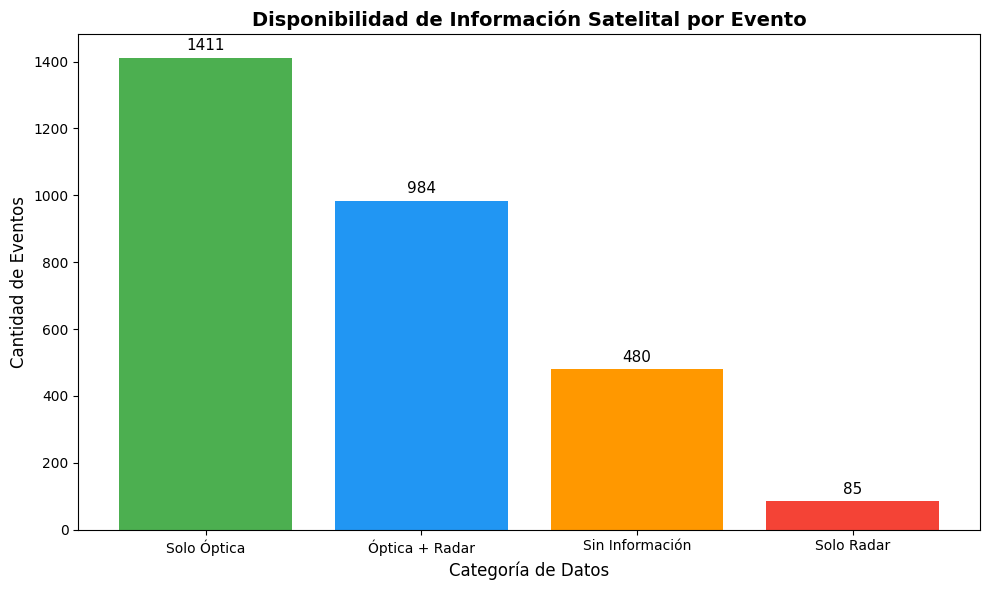

In [ ]:

import matplotlib.pyplot as plt

# Definir condiciones
has_opt = df['OPT_src'] != 'missing'
has_sar = df['SAR_src'] == 'real'

# Categorías utilizadas en el gráfico de barras
df['Category'] = 'Sin Información'
df.loc[has_opt & ~has_sar, 'Category'] = 'Solo Óptica'
df.loc[~has_opt & has_sar, 'Category'] = 'Solo Radar'
df.loc[has_opt & has_sar, 'Category'] = 'Óptica + Radar'

# Conteo de categorías
counts = df['Category'].value_counts()

# Organización descendente
counts = counts.sort_values(ascending=False)

# Cración de gráfico
plt.figure(figsize=(10, 6))
bars = plt.bar(counts.index, counts.values, color=['#4CAF50', '#2196F3', '#FF9800', '#F44336'])

# Estilo gráfico
plt.title('Disponibilidad de Información Satelital por Evento', fontweight='bold', fontsize=14)
plt.ylabel('Cantidad de Eventos', fontsize=12)
plt.xlabel('Categoría de Datos', fontsize=12)

# Add value labels on top of bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + (max(counts.values)*0.01), int(yval), ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.savefig('disponibilidad_datos.png')

# Print summary for the response
print(counts)
print(f"Total eventos: {len(df)}")

En general fue posible obtener información asociada a **2395 eventos y "no eventos" de deslizamientos de tierra**, lo que indica un buen cubrimiento de la zona por parte de Landsat y Sentinel 2. Por el contrario, en el caso de radar se evidencia un faltante muy amplio debido a la fecha de lanzamiento del Sentinel 1 (3 de abril del 2014) y a la adecuación inicial que en promedio tardo entre el 2014-2015.Se trato de atender este faltante de información haciendo uso de imágenes de radar proporcionadas por ALOS PALSAR, sin embargo en GEE solo se presenta una colección anual.

Total Óptico: 2395
Total Radar: 1069
Sin Información: 480


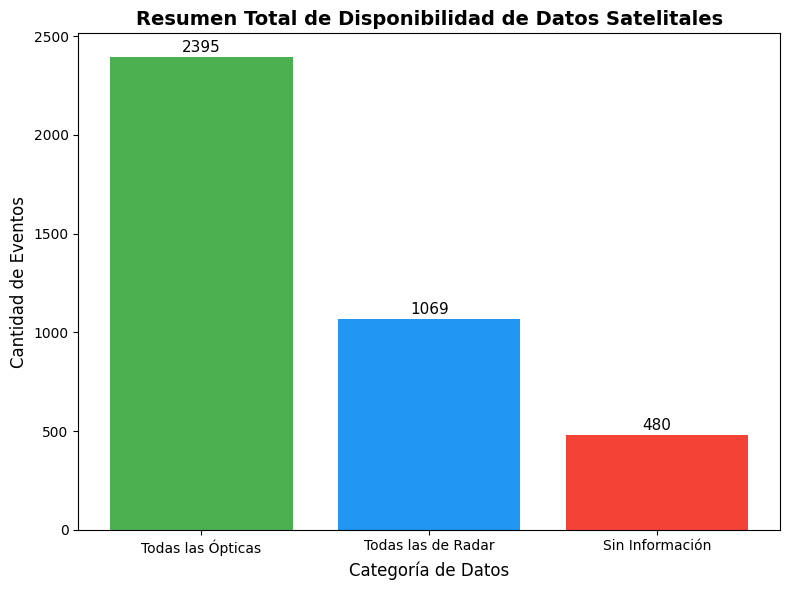

In [ ]:
# Calcular los totales independientes
# 'Todas las ópticas' incluye eventos que también tienen radar
total_optico = (df['OPT_src'] != 'missing').sum()

# 'Todas las de radar' incluye eventos que también tienen óptica
total_radar = (df['SAR_src'] == 'real').sum()

# 'Sin información' son los que no tienen absolutamente nada
total_ninguno = ((df['OPT_src'] == 'missing') & (df['SAR_src'] == 'missing')).sum()

# Preparar datos para el gráfico con formato LaTeX para negrita
etiquetas = ['Todas las Ópticas','Todas las de Radar','Sin Información']
valores = [total_optico, total_radar, total_ninguno]
colores = ['#4CAF50', '#2196F3', '#F44336']

# Crear el gráfico
plt.figure(figsize=(8, 6))
barras = plt.bar(etiquetas, valores, color=colores)

# Configuración de estilo
plt.title('Resumen Total de Disponibilidad de Datos Satelitales', fontweight='bold', fontsize=14)
plt.ylabel('Cantidad de Eventos', fontsize=12)
plt.xlabel('Categoría de Datos', fontsize=12)

# Añadir etiquetas de valor sobre las barras
for barra in barras:
    yval = barra.get_height()
    plt.text(barra.get_x() + barra.get_width()/2, yval + 10, int(yval),
             ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.savefig('resumen_total_disponibilidad.png')

# Resumen de consola
print(f"Total Óptico: {total_optico}")
print(f"Total Radar: {total_radar}")
print(f"Sin Información: {total_ninguno}")

Respecto a los años, se tiene un rezago bastante amplio relacionado con radar en los años 2010, 2014, 2015 y 2016.

      Sin_Opt  Sin_Rad  Sin_Gral
Year                            
2021        3        0         0
2022        2        0         0
2023        2        0         0
2024        1        0         0
2025        1        0         0


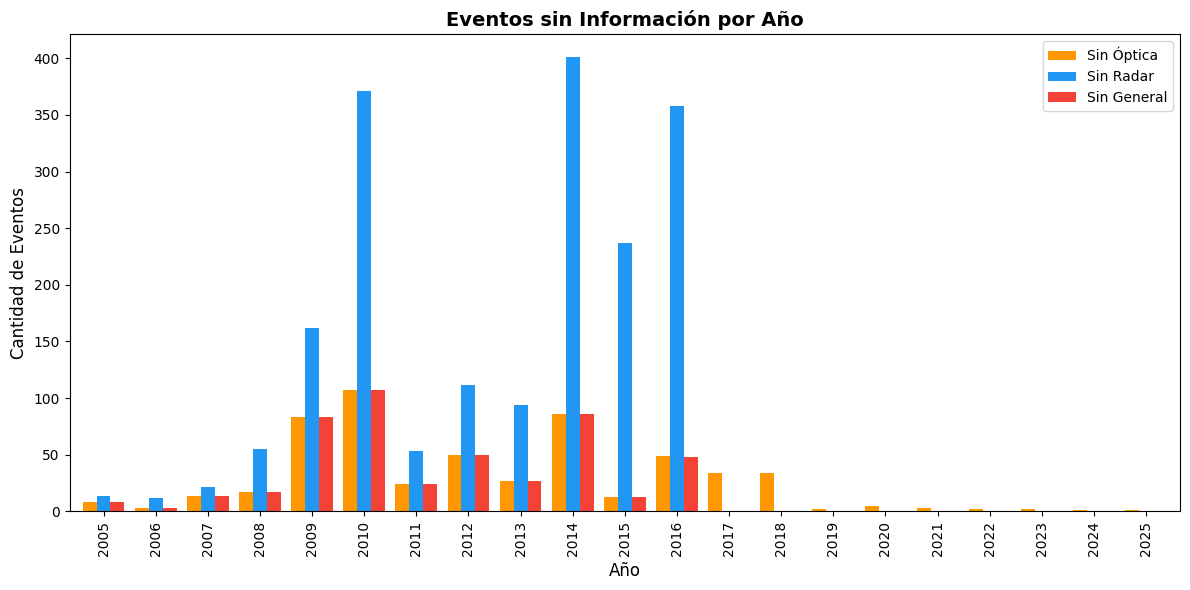

In [ ]:
# Extracción de año de fechas
df['Year'] = df['Fecha_E'].dt.year

# Versión ultra compacta
summary = df.assign(
    Sin_Opt = (df['OPT_src'] == 'missing'),
    Sin_Rad = (df['SAR_src'] != 'real'),
    Sin_Gral = (df['OPT_src'] == 'missing') & (df['SAR_src'] != 'real')
).groupby('Year')[['Sin_Opt', 'Sin_Rad', 'Sin_Gral']].sum()

# Graficar
ax = summary.plot(kind='bar', figsize=(12, 6), width=0.8, color=['#FF9800', '#2196F3', '#F44336'])
plt.title('Eventos sin Información por Año', fontweight='bold', fontsize=14)
plt.ylabel('Cantidad de Eventos', fontsize=12)
plt.xlabel('Año',fontsize=12)
plt.legend(['Sin Óptica', 'Sin Radar', 'Sin General'])
plt.tight_layout()
plt.savefig('faltantes_corto.png')

print(summary.tail())

**Como es posible observar en los anteriores gráficos, se evidencia la ausencia de información asociada tanto a variables derivadas de imágenes satelitáles ópticas como de radar. En el caso de la imágenes ópticas esta problemática se deriva por la prescencia de nubosidad continua en la zona de estudio y por consiguiente en la ubicación del evento y sus cercanías. Por otro lado, en el caso de radar, la falta de información se asocia principalmente a la disponibilidad histórica del sensor Sentinel-1, dado que su operación y adquisición sistemática inicia en años posteriores a varios eventos del periodo de análisis; en consecuencia, para esas fechas no existen escenas SAR en Earth Engine (o no cumplen los criterios mínimos de cobertura), generando ausencia de variables radar en los resultados.**

A continuación, se realiza un análisis para saber porque aunque para 2015 y 2016 , deberían haber imágenes de radar proporcionadas por Sentinel - 1, no se obtiene información.


In [ ]:
#. Filtrar todas las imágenes Sentinel-1 IW para 2015 y 2016
# No se filtra por fecha exacta del punto, sino por el año completo

s1_coleccion_2015 = ee.ImageCollection("COPERNICUS/S1_GRD") \
    .filterBounds(aoi) \
    .filterDate('2015-01-01', '2015-12-31') \
    .filter(ee.Filter.eq('instrumentMode', 'IW')) \
    .filter(ee.Filter.listContains("transmitterReceiverPolarisation", "VV")) \
    .filter(ee.Filter.listContains("transmitterReceiverPolarisation", "VH"))

s1_coleccion_2016 = ee.ImageCollection("COPERNICUS/S1_GRD") \
    .filterBounds(aoi) \
    .filterDate('2016-01-01', '2016-12-31') \
    .filter(ee.Filter.eq('instrumentMode', 'IW')) \
    .filter(ee.Filter.listContains("transmitterReceiverPolarisation", "VV")) \
    .filter(ee.Filter.listContains("transmitterReceiverPolarisation", "VH"))

# Se crean compuestos (mediana) para ver la cobertura espacial total
# Usamos la banda VV para la visualización general
mosaico_2015 = s1_coleccion_2015.select('VV').median().clip(aoi)
mosaico_2016 = s1_coleccion_2016.select('VV').median().clip(aoi)

# 4. Preparar puntos de éxito para referencia visual
df['Fecha_E'] = pd.to_datetime(df['Fecha_E'])
df_exito = df[(df['Fecha_E'].dt.year.isin([2015, 2016])) & (df['SAR_src'] == 'real')].copy()
features_exito = [ee.Feature(ee.Geometry.Point(json.loads(r['.geo'])['coordinates']), {'Codigo': str(r['Codigo'])}) for _, r in df_exito.iterrows()]
fc_exito = ee.FeatureCollection(features_exito)

# 5. Generar el mapa interactivo
Map = geemap.Map()
Map.centerObject(aoi, 8)

# Parámetros de visualización para radar (dB)
vis_params = {'min': -25, 'max': 0}

# Añadir las huellas de radar y los puntos
Map.addLayer(mosaico_2015, vis_params, 'Cobertura Radar 2015')
Map.addLayer(mosaico_2016, vis_params, 'Cobertura Radar 2016')
Map.addLayer(fc_exito, {'color': 'blue'}, 'Tus puntos con éxito (2015-2016)')

print(f"Imágenes encontradas en 2015: {s1_coleccion_2015.size().getInfo()}")
print(f"Imágenes encontradas en 2016: {s1_coleccion_2016.size().getInfo()}")

Map.add_colorbar(vis_params, label="Backscatter VV (dB)")
Map

Imágenes encontradas en 2015: 6
Imágenes encontradas en 2016: 30


Map(center=[2.282287079693607, -76.74297831918172], controls=(WidgetControl(options=['position', 'transparent_…

En el anterior caso se demuestra que tanto para el año 2015 como para el año 2016, hay poca de existencia de imágenes, pero algunas de estas se pueden asociar a lo eventos ocurridos en este periodo de tiempo.

In [ ]:
# Se filtra en donde el atributo SAR_src es 'missing'
df_gap = df[df['SAR_src'] == 'missing'].reset_index(drop=True)
len(df_gap)



1891

In [ ]:
# Verificación de datos
if not df_gap.empty:
    fila_test = df_gap.iloc[550] # Fila que se desea analizar (se analiza una fila especifica)

    def diagnostico_detallado(fila):
        fecha_evento = ee.Date(fila['Fecha_E'].strftime('%Y-%m-%d')) # Convierte fecha de evento en ee.date
        inicio = fecha_evento.advance(-24, 'day') # ventana temporal de 24 días como en el código inical
        punto = ee.Geometry.Point([fila['Longitud'], fila['Latitud']]) # Crea geometría de punto con Longitud y Latitud

       # Búsqueda de imágenes de Sentinel-1, sin filtros de banda

        col = ee.ImageCollection("COPERNICUS/S1_GRD") \
                .filterBounds(punto) \
                .filterDate(inicio, fecha_evento)

        num_images = col.size().getInfo() # Número de imágenes encontradas

        print(f"--- Diagnóstico para el punto {fila['Codigo']} ---")
        print(f"Imágenes totales encontradas en 24 días: {num_images}")

        if num_images > 0:
            info = col.toList(num_images).getInfo() # Use num_images as count
            for i, img in enumerate(info):
                bands = img['bands']  # (Como VV, VH, HH, HV).
                band_names = [b['id'] for b in bands]
                mode = img['properties']['instrumentMode']
                print(f"Imagen {i+1}:")
                print(f"  - Bandas disponibles: {band_names}")
                print(f"  - Modo: {mode}")
                if 'VH' not in band_names:
                    print("  - [!] FALLA: No tiene banda VH (código la descarta)")
                if mode != 'IW':
                    print(f"  - [!] FALLA: El modo es {mode}, no IW (código la descarta)")
        else:
            print("No se encontraron imágenes Sentinel-1 para este punto y rango de fechas.")

    diagnostico_detallado(fila_test)
else:
    print("No hay eventos con SAR_src == 'missing' para diagnosticar.")

--- Diagnóstico para el punto 55232 ---
Imágenes totales encontradas en 24 días: 1
Imagen 1:
  - Bandas disponibles: ['VV', 'angle']
  - Modo: IW
  - [!] FALLA: No tiene banda VH (código la descarta)


In [ ]:
con_imagenes_pero_sin_vh = 0
total_sin_imagenes = 0
otros_casos = 0
total_puntos = len(df_gap)

print(f"Iniciando análisis de {total_puntos} puntos...")


# Para cada punto: Se define la fecha del evento. Se construye una ventana temporal retrospectiva
# de 24 días, coherente con la lógica del análisis SAR. Se crea la geometría puntual a partir de
# las coordenadas del evento.

for i, fila in df_gap.iterrows():
    fecha_evento = ee.Date(fila['Fecha_E'].strftime('%Y-%m-%d')) # Definición fecha del evento
    inicio = fecha_evento.advance(-24, 'day') # Ventana temporal retrospectiva de 24 días
    punto = ee.Geometry.Point([fila['Longitud'], fila['Latitud']]) # Creación de geometría puntual

    col = ee.ImageCollection("COPERNICUS/S1_GRD") \
            .filterBounds(punto) \
            .filterDate(inicio, fecha_evento)

    num_images = col.size().getInfo()

    if num_images == 0:
        total_sin_imagenes += 1  # No hay imágenes
    else:
        # Analizamos las bandas de las imágenes encontradas, se inspeccionan todas las imágenes disponibles.
        info = col.toList(num_images).getInfo()
        tiene_vh_alguna = any(['VH' in [b['id'] for b in img['bands']] for img in info]) #Se verifica si al menos una imagen contiene la banda VH.

        # El satélite  pasó, pero las adquisiciones no cumplen el requisito mínimo de polarización.
        if not tiene_vh_alguna:
            con_imagenes_pero_sin_vh += 1
        else:
            otros_casos += 1

print("-" * 30)
print(f"RESULTADOS DEL DIAGNÓSTICO:")
print(f"Puntos donde NO hay satélite (0 imágenes): {total_sin_imagenes}")
print(f"Puntos con imágenes pero SIN banda VH: {con_imagenes_pero_sin_vh}")
print(f"Puntos que sí tienen VH (revisar otros filtros): {otros_casos}")

Iniciando análisis de 1891 puntos...
------------------------------
RESULTADOS DEL DIAGNÓSTICO:
Puntos donde NO hay satélite (0 imágenes): 1278
Puntos con imágenes pero SIN banda VH: 613
Puntos que sí tienen VH (revisar otros filtros): 0


In [ ]:
import pandas as pd

# Suponiendo que df_gap tiene la columna 'Fecha_E'
fecha_limite_s1 = pd.to_datetime('2014-10-01')

pre_s1 = df_gap[pd.to_datetime(df_gap['Fecha_E']) < fecha_limite_s1].shape[0]
post_s1 = df_gap[pd.to_datetime(df_gap['Fecha_E']) >= fecha_limite_s1].shape[0]

print(f"Puntos antes de Oct-2014 (Sin S1 disponible): {pre_s1}")
print(f"Puntos después de Oct-2014 (Posible falta de cobertura): {post_s1}")

Puntos antes de Oct-2014 (Sin S1 disponible): 1276
Puntos después de Oct-2014 (Posible falta de cobertura): 615


**En este caso se puede observar que de los 615 puntos de evenos y no eventos de deslizamientos 613 poseen información solo en la polarización VV, sin embargo los dos puntos restantes no tienen imágenes asociadas.**

In [ ]:
import pandas as pd

# Definir la fecha límite y filtrar los 615 puntos clave
fecha_limite_s1 = pd.to_datetime('2014-10-01')
df_post_s1 = df_gap[pd.to_datetime(df_gap['Fecha_E']) >= fecha_limite_s1].copy()

puntos_recuperados_vh = 0
puntos_persisten_solo_vv = 0
puntos_sin_datos_aun = 0

print(f"Analizando ventana de 24 días para {len(df_post_s1)} puntos...")

for i, fila in df_post_s1.iterrows():
    fecha_evento = ee.Date(pd.to_datetime(fila['Fecha_E']).strftime('%Y-%m-%d'))
    inicio = fecha_evento.advance(-24, 'day')
    punto = ee.Geometry.Point([fila['Longitud'], fila['Latitud']])

    col = ee.ImageCollection("COPERNICUS/S1_GRD") \
            .filterBounds(punto) \
            .filterDate(inicio, fecha_evento) \
            .filter(ee.Filter.eq('instrumentMode', 'IW'))

    count = col.size().getInfo()

    if count == 0:
        puntos_sin_datos_aun += 1
    else:
        # Verificamos si al menos UNA imagen de la colección tiene VH
        info = col.toList(count).getInfo()
        tiene_vh_alguna = any(['VH' in [b['id'] for b in img['bands']] for img in info])

        if tiene_vh_alguna:
            puntos_recuperados_vh += 1
        else:
            puntos_persisten_solo_vv += 1

print("-" * 30)
print(f"RESULTADOS CON VENTANA DE 24 DÍAS:")
print(f"Puntos que AHORA tienen VH: {puntos_recuperados_vh}")
print(f"Puntos que siguen siendo SOLO VV: {puntos_persisten_solo_vv}")
print(f"Puntos que siguen sin imágenes: {puntos_sin_datos_aun}")

Analizando ventana de 24 días para 615 puntos...
------------------------------
RESULTADOS CON VENTANA DE 24 DÍAS:
Puntos que AHORA tienen VH: 0
Puntos que siguen siendo SOLO VV: 613
Puntos que siguen sin imágenes: 2


**Como se pudo observar de acuerdo a los anteriores resultados, se establece que hay información que no contiene ambas polarizaciones, sino solo la VV, por lo tanto, a continuación se va a ingresar esta información en el csv resultante.**

In [ ]:
import ee
import geemap
import json
import pandas as pd
from google.colab import drive

# ================================================
# Conexión con Google Drive y Google Earth Engine
# ================================================

drive.mount("/content/drive")

PROJECT_ID = "ee-linapaolagarcia"
try:
    ee.Initialize(project=PROJECT_ID)
except Exception:
    ee.Authenticate()
    ee.Initialize(project=PROJECT_ID)

print("GEE listo ✅")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
GEE listo ✅


In [ ]:
# ============================================================
# Inclusión de valores de VV cuando existan.
# ============================================================

# =============================
# 1) Asignación de rutas
# =============================

CSV_BASE = "/content/drive/MyDrive/TESIS_GEE/ExtracionVariables_OPT90_SAR24_BUF60_30m_CAUCA_COMPLETO_210226_defajustadoV2.csv"

# Carpeta Drive y nombre del parche
PATCH_FOLDER = "TESIS_GEE"
PATCH_DESC   = "PARCHE_SAR24_BUF60_VVONLY_2014_10_2016_12_CAUCAV2"

# Salida final fusionada
CSV_OUT_UPDATED = "/content/drive/MyDrive/TESIS_GEE/ExtracionVariables_OPT90_SAR24_BUF60_30m_CAUCA_COMPLETO_ACTUALIZADO_VVONLYajusteV2.csv"

# Ruta esperada del parche (NO existirá hasta que termine la tarea EE)
CSV_PATCH_EXPECTED = f"/content/drive/MyDrive/{PATCH_FOLDER}/{PATCH_DESC}.csv"

# ==================================================
# 2) PARÁMETROS SAR (Derivados de código principal)
# =================================================

SCALE = 30
SAR_DAYS = 24
BUF_M = 60

MIN_VALID_FRAC_S1  = 0.10
TILE_SCALE = 16
MAX_PIXELS = 1e8

S1_PASS  = None
S1_ORBIT = None
S1_LIMIT = 60
S1_SPECKLE_RADIUS_M = 30
S1_DB_MIN = -35
S1_DB_MAX = 5

# ====================================================
# 3) LEER BASE + EXTRAER COORDS (.geo) y DEFINIR GAP
# ====================================================

base = pd.read_csv(CSV_BASE) # Leer csv base

# Verificación de la existencia de la columna de geometría
if ".geo" not in base.columns:
    raise ValueError("No existe la columna '.geo' en el CSV base. Verifica que sea un export de GEE con geometría.")

def get_coords(geo_str):
    try:
        g = json.loads(geo_str)
        return g.get("coordinates", [None, None])
    except Exception:
        return [None, None]

base["Longitud"] = base[".geo"].apply(lambda x: get_coords(x)[0])
base["Latitud"]  = base[".geo"].apply(lambda x: get_coords(x)[1])

# Normalizar llave
base["Codigo"]  = base["Codigo"].astype(str).str.strip()
base["Fecha_E"] = pd.to_datetime(base["Fecha_E"], errors="coerce")

# Filtrar filas con info mínima
base = base.dropna(subset=["Codigo", "Fecha_E", "Latitud", "Longitud"]).copy()

# Rango temporal situaciones donde se encuentra solo información de
# la polarización VV
fecha_inicio = pd.Timestamp("2014-10-01")
fecha_fin    = pd.Timestamp("2016-12-31")
cond_fecha = (base["Fecha_E"] >= fecha_inicio) & (base["Fecha_E"] <= fecha_fin)

# Criterio de “SAR incompleto”, selecciona las puntos que tiene el atributo SAR-src como
# missing y que por consiguiente VV_mean_24d_30m esta vacío.
col_sarsrc = "SAR_src"
col_vv = f"VV_mean_{SAR_DAYS}d_30m"

cond_missing = (base[col_sarsrc].astype(str) == "missing") if col_sarsrc in base.columns else False
cond_vv_nan  = base[col_vv].isna() if col_vv in base.columns else False

gap = base[cond_fecha & (cond_missing | cond_vv_nan)].copy()

print("CSV base:", CSV_BASE)
print("Eventos objetivo (2014-10-01 a 2016-12-31 con SAR incompleto):", len(gap))
print("Rango fechas GAP:", gap["Fecha_E"].min(), "→", gap["Fecha_E"].max())

if len(gap) == 0:
    raise ValueError("No hay eventos 'gap' con SAR incompleto en el rango indicado. Revisa filtros/columnas.")

# =================================================
# 4) Construcción de FeatureCollection (solo gap)
# =================================================
# Se conviertesn los datos procesados con pandas en un formato
# complatible con GEE.
def to_feat(row):
    pt = ee.Geometry.Point([float(row["Longitud"]), float(row["Latitud"])])
    return ee.Feature(pt, {
        "Codigo": str(row["Codigo"]).strip(),
        "Fecha_E": row["Fecha_E"].strftime("%Y-%m-%d")
    })

fc_gap = ee.FeatureCollection([to_feat(r) for _, r in gap.iterrows()])
print("N (FeatureCollection gap):", fc_gap.size().getInfo())

# =============================
# 5) Funciones de ayuda
# =============================
# Convierte un valor lógico (boolean) en un número 0/1 en entorno GEE
def b2i(b):
    return ee.Number(ee.Algorithms.If(b, 1, 0))

# Implementa un AND lógico robusto en GEE.
def band_and(a, b):
    return b2i(a).multiply(b2i(b)).eq(1)

# Evita que el codigo falle cuando un valor NO existe en
# un diccionario.

def dict_get_safe(dct, key, default=None):
    dct = ee.Dictionary(dct)
    key = ee.String(key)
    return ee.Algorithms.If(dct.contains(key), dct.get(key), default)


# Calcula media y desviación estándar (estadísticos zonales) de las bandas de una imagen dentro de una geometría (buffer).
def zonal_mean_std(img, geom, scale):
    reducer = ee.Reducer.mean().combine(ee.Reducer.stdDev(), sharedInputs=True)
    return ee.Dictionary(img.reduceRegion(
        reducer=reducer,
        geometry=geom,
        scale=scale,
        maxPixels=MAX_PIXELS,
        bestEffort=False,
        tileScale=TILE_SCALE
    ))

# Estima la fracción de píxeles válidos (0 a 1) dentro del buffer.
def valid_fraction(img_band, geom, scale):
    m = img_band.mask().gt(0).unmask(0).toFloat().rename("valid")
    d = ee.Dictionary(m.reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=geom,
        scale=scale,
        maxPixels=MAX_PIXELS,
        bestEffort=False,
        tileScale=TILE_SCALE
    ))
    return ee.Number(d.get("valid"))

# Crea una banda “vacía” (enmascarada), con el nombre indicado.
def empty_band(name):
    return ee.Image.constant(0).rename(name).updateMask(ee.Image.constant(0))

# Convierte un valor en dB a escala lineal.
def db_to_lin(db_value):
    return ee.Number(10).pow(ee.Number(db_value).divide(10))

# Aplica un suavizado espacial (mediana focal) para reducir el speckle del radar.
def speckle_smooth_db(img_db, radius_m=S1_SPECKLE_RADIUS_M):
    radius_m = ee.Number(radius_m)
    return ee.Image(ee.Algorithms.If(
        radius_m.lte(0),
        img_db,
        img_db.focal_median(radius=radius_m, units="meters")
    ))

# ELimina píxeles problemáticos en Sentinel-1 (VV/VH) usando:
# las máscara nativa de las bansas así como el rango de retrodispersión fijado.
def mask_s1_edges_db_vvvh(img):
    vv = img.select("VV")
    vh = img.select("VH")
    m = (vv.mask().And(vh.mask())
         .And(vv.gt(S1_DB_MIN)).And(vv.lt(S1_DB_MAX))
         .And(vh.gt(S1_DB_MIN)).And(vh.lt(S1_DB_MAX)))
    return img.updateMask(m)

# ===============================================
# Extracción de variable SAR permitiendo VV_only
# ==============================================

# Extrae variables SAR de Sentinel-1 en una ventana temporal fde 24 días con un buffer 60m, pero con una diferencia clave frente al código original:
# Si existen imágenes con VV y VH → calcula métricas completas y marca SAR_src = "real".
# Si no existen imágenes con VH, pero sí con VV → calcula solo VV, deja las métricas que requieren VH como None y marca SAR_src = "vv_only".
# Si no hay imágenes → marca SAR_src = "missing".

def get_s1_sar_vv_or_vvvh(geom, d, sar_days):
    start = d.advance(-sar_days, "day")

    s1_base = (ee.ImageCollection("COPERNICUS/S1_GRD")
               .filterBounds(geom)
               .filterDate(start, d)
               .filter(ee.Filter.eq("instrumentMode", "IW"))
               .filter(ee.Filter.listContains("transmitterReceiverPolarisation", "VV")))

    if S1_PASS is not None:
        s1_base = s1_base.filter(ee.Filter.eq("orbitProperties_pass", S1_PASS))
    if S1_ORBIT is not None:
        s1_base = s1_base.filter(ee.Filter.eq("relativeOrbitNumber_start", S1_ORBIT))

    s1_base = s1_base.sort("system:time_start", False).limit(S1_LIMIT)
    n_all = s1_base.size()

# Indicaciones para llenar el csv en caso de que no existan imágenes.

    def out_missing():
        return ee.Dictionary({
            "SAR_sensor": "S1_GRD_IW",
            "SAR_src": "missing",
            "SAR_valid_frac": 0,
            "VV_mean": None, "VV_std": None,
            "VH_mean": None, "VH_std": None,
            "VVminusVH": None,
            "VVdivVH": None
        })

# En caso de que si hayan  imágenes.

    def out_real():
        col_vvvh = s1_base.filter(ee.Filter.listContains("transmitterReceiverPolarisation", "VH")) # contiene solo imágenes que además de VV tienen VH.
        use_vvvh = col_vvvh.size().gt(0) # es True si hay al menos una.

        col = ee.ImageCollection(ee.Algorithms.If(use_vvvh, col_vvvh, s1_base)) # Si hay VH → usa la colección VV+VH. Si no hay VH → usa la colección solo VV.

        def select_bands(img):
            return ee.Image(ee.Algorithms.If(use_vvvh, img.select(["VV", "VH"]), img.select(["VV"])))
        col_sel = col.map(select_bands)

        def clean(img):
            return ee.Image(ee.Algorithms.If(use_vvvh, mask_s1_edges_db_vvvh(img), img)) # limpia SOLO si hay VV y VH

         # crea una sola imagen compuesta, donde cada píxel es la mediana de todos los píxeles en el tiempo.
        med = col_sel.map(clean).median()

        #  Suavizado VV
        vv_db = speckle_smooth_db(med.select("VV"), S1_SPECKLE_RADIUS_M).rename("VV")

        # Si existe banda VH la suaviza de lo contrario crea una banda "VH" vacia
        # en,ascarada
        vh_db = ee.Image(ee.Algorithms.If(
            use_vvvh,
            speckle_smooth_db(med.select("VH"), S1_SPECKLE_RADIUS_M).rename("VH"),
            empty_band("VH")
        ))

        # Imagen final con bandas consistentes
        img_db = vv_db.addBands(vh_db)

        # Calculo de estadísticos zonales

        stats = zonal_mean_std(img_db, geom, SCALE)

        # Confirma si realmente existen valores
        hasVV = stats.contains("VV_mean")
        hasVH = ee.Algorithms.If(use_vvvh, stats.contains("VH_mean"), False)

        # Extraer VV y su dispersión solo si existe
        vv_mean = ee.Algorithms.If(hasVV, stats.get("VV_mean"), None)
        vv_std  = ee.Algorithms.If(stats.contains("VV_stdDev"), stats.get("VV_stdDev"), None)

        # Extraer VH y su dispersión solo si existe
        vh_mean = ee.Algorithms.If(hasVH, stats.get("VH_mean"), None)
        vh_std  = ee.Algorithms.If(stats.contains("VH_stdDev"), stats.get("VH_stdDev"), None)

        # Detecta si falta VH
        missing_vh = b2i(ee.Algorithms.IsEqual(vh_mean, None)).eq(1)

        # Si no falta VH calcula VV − VH y VV/VH en escala lineal
        vv_minus_vh = ee.Algorithms.If(
            missing_vh, None,
            ee.Number(vv_mean).subtract(ee.Number(vh_mean))
        )

        vv_lin = ee.Algorithms.If(missing_vh, None, db_to_lin(vv_mean))
        vh_lin = ee.Algorithms.If(missing_vh, None, db_to_lin(vh_mean))

        vv_div_vh = ee.Algorithms.If(
            missing_vh, None,
            ee.Number(vv_lin).divide(ee.Number(vh_lin).add(1e-6))
        )

        # Fracción de píxeles válidos en el buffer
        sar_valid = valid_fraction(img_db.select("VV"), geom, SCALE)

        # Clasificación.
       # Si NO hay VV_mean → "missing"
       # Si hay VV_mean y hay VH_mean → "real"
       # Si hay VV_mean pero no VH_mean → "vv_only"

        sar_src0 = ee.String(ee.Algorithms.If(
            hasVV,
            ee.Algorithms.If(hasVH, "real", "vv_only"),
            "missing"
        ))

        # Reglas de calidad: si cobertura es baja → “missing”
        not_missing = b2i(ee.String(sar_src0).equals("missing")).eq(0)

        sar_src = ee.String(ee.Algorithms.If(
            band_and(not_missing, ee.Number(sar_valid).gte(MIN_VALID_FRAC_S1)),
            sar_src0,
            "missing"
        ))

        # Si quedó missing, borrar valores para no “contaminar” el CSV

        ok = b2i(ee.String(sar_src).equals("missing")).eq(0)

        vv_mean = ee.Algorithms.If(ok, vv_mean, None)
        vv_std  = ee.Algorithms.If(ok, vv_std,  None)
        vh_mean = ee.Algorithms.If(ok, vh_mean, None)
        vh_std  = ee.Algorithms.If(ok, vh_std,  None)
        vv_minus_vh = ee.Algorithms.If(ok, vv_minus_vh, None)
        vv_div_vh   = ee.Algorithms.If(ok, vv_div_vh,   None)
        sar_valid   = ee.Number(ee.Algorithms.If(ok, sar_valid, 0))

        # Salida del diccionario.

        return ee.Dictionary({
            "SAR_sensor": "S1_GRD_IW",
            "SAR_src": sar_src,
            "SAR_valid_frac": sar_valid,
            "VV_mean": vv_mean, "VV_std": vv_std,
            "VH_mean": vh_mean, "VH_std": vh_std,
            "VVminusVH": vv_minus_vh,
            "VVdivVH": vv_div_vh
        })

    return ee.Dictionary(ee.Algorithms.If(n_all.gt(0), out_real(), out_missing()))

# =========================================================================
# 7) CREA proceso en GEE y exporta archivo csv con esta información de los
# puntos problemáticos.
# =========================================================================
def extract_sar_patch(feat):
    d = ee.Date(ee.String(feat.get("Fecha_E")))
    geom = feat.geometry().buffer(BUF_M)
    sar = ee.Dictionary(get_s1_sar_vv_or_vvvh(geom, d, SAR_DAYS))

    return feat.set({
        "SAR_sensor": dict_get_safe(sar, "SAR_sensor", None),
        "SAR_src": dict_get_safe(sar, "SAR_src", None),
        "SAR_valid_frac": dict_get_safe(sar, "SAR_valid_frac", None),
        f"VV_mean_{SAR_DAYS}d_30m": dict_get_safe(sar, "VV_mean", None),
        f"VV_std_{SAR_DAYS}d_30m":  dict_get_safe(sar, "VV_std", None),
        f"VH_mean_{SAR_DAYS}d_30m": dict_get_safe(sar, "VH_mean", None),
        f"VH_std_{SAR_DAYS}d_30m":  dict_get_safe(sar, "VH_std", None),
        f"VVminusVH_{SAR_DAYS}d_30m": dict_get_safe(sar, "VVminusVH", None),
        f"VVdivVH_{SAR_DAYS}d_30m":   dict_get_safe(sar, "VVdivVH", None),
    })

fc_patch = fc_gap.map(extract_sar_patch)

patch_cols = [
    "Codigo", "Fecha_E",
    "SAR_sensor", "SAR_src", "SAR_valid_frac",
    f"VV_mean_{SAR_DAYS}d_30m", f"VV_std_{SAR_DAYS}d_30m",
    f"VH_mean_{SAR_DAYS}d_30m", f"VH_std_{SAR_DAYS}d_30m",
    f"VVminusVH_{SAR_DAYS}d_30m", f"VVdivVH_{SAR_DAYS}d_30m"
]
fc_patch_small = fc_patch.select(patch_cols)


task = ee.batch.Export.table.toDrive(
    collection=fc_patch_small,
    description=PATCH_DESC,
    folder=PATCH_FOLDER,
    fileFormat="CSV"
)
task.start()

print("\n✅ PARCHE exportándose:", PATCH_DESC)
print("Ruta esperada:", CSV_PATCH_EXPECTED)



CSV base: /content/drive/MyDrive/TESIS_GEE/ExtracionVariables_OPT90_SAR24_BUF60_30m_CAUCA_COMPLETO_210226_defajustadoV2.csv
Eventos objetivo (2014-10-01 a 2016-12-31 con SAR incompleto): 615
Rango fechas GAP: 2014-10-01 00:00:00 → 2016-10-01 00:00:00
N (FeatureCollection gap): 615

✅ PARCHE exportándose: PARCHE_SAR24_BUF60_VVONLY_2014_10_2016_12_CAUCAV2
Ruta esperada: /content/drive/MyDrive/TESIS_GEE/PARCHE_SAR24_BUF60_VVONLY_2014_10_2016_12_CAUCAV2.csv


In [ ]:
# =======================================
# Fusión del parche con el archivo base
# =======================================

# Vefica que el documento exista
import os
if not os.path.exists(CSV_PATCH_EXPECTED):
    raise FileNotFoundError(f"No existe todavía el parche en Drive: {CSV_PATCH_EXPECTED}")

patch = pd.read_csv(CSV_PATCH_EXPECTED)

base2 = pd.read_csv(CSV_BASE)

# Se normaliza tanto el codigo como la fecha del csv inical y del generado en el paso anterior
base2["Codigo"]  = base2["Codigo"].astype(str).str.strip()
patch["Codigo"]  = patch["Codigo"].astype(str).str.strip()

base2["Fecha_E"] = pd.to_datetime(base2["Fecha_E"], errors="coerce").dt.strftime("%Y-%m-%d")
patch["Fecha_E"] = pd.to_datetime(patch["Fecha_E"], errors="coerce").dt.strftime("%Y-%m-%d")

# Se define la llave de la unión.
key = ["Codigo", "Fecha_E"]

# Definir qué columnas SAR se van a actualizar
sar_cols = [
    "SAR_sensor", "SAR_src", "SAR_valid_frac",
    f"VV_mean_{SAR_DAYS}d_30m", f"VV_std_{SAR_DAYS}d_30m",
    f"VH_mean_{SAR_DAYS}d_30m", f"VH_std_{SAR_DAYS}d_30m",
    f"VVminusVH_{SAR_DAYS}d_30m", f"VVdivVH_{SAR_DAYS}d_30m"
]

# Convertir ambos a índices por llave y alinear filas
sar_cols = [c for c in sar_cols if (c in base2.columns and c in patch.columns)]

base_i  = base2.set_index(key)
patch_i = patch.set_index(key).reindex(base_i.index)

# Si el parche tiene dato → reemplaza el base
# Si el parche es NaN → conserva lo del base

for c in sar_cols:
    base_i[c] = base_i[c].where(~patch_i[c].notna(), patch_i[c])

# Guardar el CSV final
out = base_i.reset_index()
out.to_csv(CSV_OUT_UPDATED, index=False)

print("\n✅ CSV FINAL actualizado guardado en:", CSV_OUT_UPDATED)
print("Conteo SAR_src (real/missing/vv_only):")
print(out["SAR_src"].value_counts(dropna=False).head(20))


✅ CSV FINAL actualizado guardado en: /content/drive/MyDrive/TESIS_GEE/ExtracionVariables_OPT90_SAR24_BUF60_30m_CAUCA_COMPLETO_ACTUALIZADO_VVONLYajusteV2.csv
Conteo SAR_src (real/missing/vv_only):
SAR_src
missing    1278
real       1069
vv_only     613
Name: count, dtype: int64


In [ ]:
import ee
import geemap
import json
import pandas as pd

# 1. Definir el área de estudio basada en la envolvente de tus puntos
df = pd.read_csv('/content/drive/MyDrive/TESIS_GEE/ExtracionVariables_OPT90_SAR24_BUF60_30m_CAUCA_COMPLETO_ACTUALIZADO_VVONLYajusteV2.csv')
# Convertir la columna 'Fecha_E' a tipo datetime
df['Fecha_E'] = pd.to_datetime(df['Fecha_E'])
def get_coords(geo_str):
    g = json.loads(geo_str)
    return g['coordinates']

# Extract Longitud and Latitud from the '.geo' column
df['Longitud'] = df['.geo'].apply(lambda x: get_coords(x)[0])
df['Latitud'] = df['.geo'].apply(lambda x: get_coords(x)[1])

coords = df['.geo'].apply(get_coords).tolist()
aoi = ee.Geometry.MultiPoint(coords).convexHull().buffer(20000)

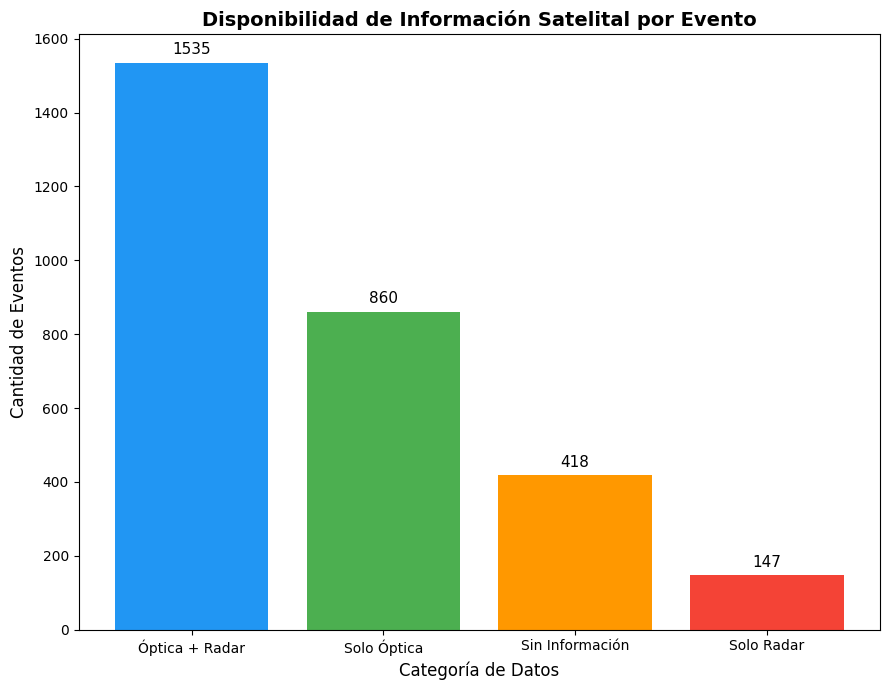

Category
Óptica + Radar     1535
Solo Óptica         860
Sin Información     418
Solo Radar          147
Name: count, dtype: int64
Total eventos: 2960


In [ ]:
import matplotlib.pyplot as plt

# ---------------------------
# Condiciones simples
# ---------------------------
has_opt = df['OPT_src'] != 'missing'
has_sar = df['SAR_src'].isin(['real', 'vv_only'])

# ---------------------------
# Categorías claras
# ---------------------------
df['Category'] = 'Sin Información'
df.loc[has_opt & has_sar, 'Category'] = 'Óptica + Radar'
df.loc[has_opt & ~has_sar, 'Category'] = 'Solo Óptica'
df.loc[~has_opt & has_sar, 'Category'] = 'Solo Radar'

# ---------------------------
# Conteo
# ---------------------------
counts = df['Category'].value_counts().sort_values(ascending=False)

# ---------------------------
# Gráfico
# ---------------------------
plt.figure(figsize=(9, 7))

# Define colores a través del diccionario
colors_map = {
    'Óptica + Radar': '#2196F3' ,
    'Solo Óptica':'#4CAF50' ,
    'Sin Información': '#FF9800',
    'Solo Radar': '#F44336'  # Assigning a specific color to 'Solo Radar'
}

# Ensure the order of colors matches the order of counts.index
ordered_colors = [colors_map[cat] for cat in counts.index]

bars = plt.bar(
    counts.index,
    counts.values,
    color=ordered_colors
)

plt.title('Disponibilidad de Información Satelital por Evento', fontsize=14, fontweight='bold')
plt.ylabel('Cantidad de Eventos', fontsize=12)
plt.xlabel('Categoría de Datos', fontsize=12)

for bar in bars:
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        yval + max(counts.values)*0.01,
        int(yval),
        ha='center',
        va='bottom',
        fontsize=11
    )

plt.tight_layout()
plt.savefig('disponibilidad_datos_simplificada.png', dpi=300)
plt.show()

print(counts)
print(f"Total eventos: {len(df)}")

      Sin_Opt  Sin_Rad  Sin_Gral
Year                            
2021        3        0         0
2022        2        0         0
2023        2        0         0
2024        1        0         0
2025        1        0         0


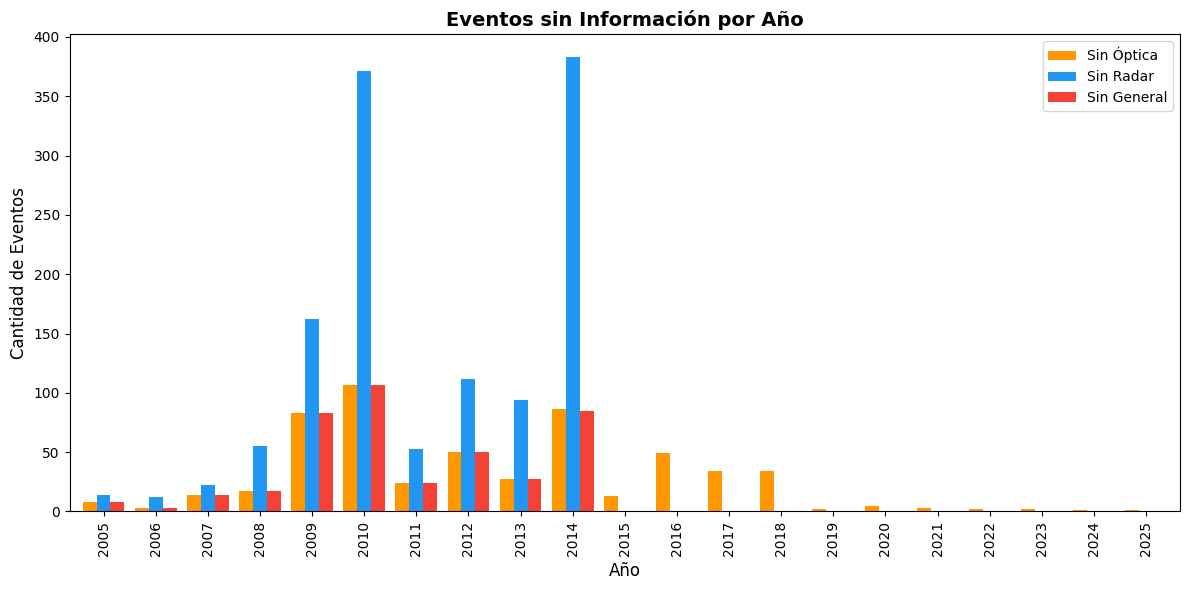

In [ ]:
# Extracción de año de fechas
df['Year'] = df['Fecha_E'].dt.year

# Versión ultra compacta
summary = df.assign(
    Sin_Opt = (df['OPT_src'] == 'missing'),
    Sin_Rad = (~df['SAR_src'].isin(['real', 'vv_only'])), # Corrected: Use isin() and invert the condition for 'missing' radar
    Sin_Gral = (df['OPT_src'] == 'missing') & (~df['SAR_src'].isin(['real', 'vv_only'])) # Corrected: Use isin() and invert the condition for 'missing' radar
).groupby('Year')[['Sin_Opt', 'Sin_Rad', 'Sin_Gral']].sum()

# Graficar
ax = summary.plot(kind='bar', figsize=(12, 6), width=0.8, color=['#FF9800', '#2196F3', '#F44336'])
plt.title('Eventos sin Información por Año', fontweight='bold', fontsize=14)
plt.ylabel('Cantidad de Eventos', fontsize=12)
plt.xlabel('Año',fontsize=12)
plt.legend(['Sin Óptica', 'Sin Radar', 'Sin General'])
plt.tight_layout()
plt.savefig('faltantes_corto.png')

print(summary.tail())

In [ ]:
import pandas as pd
import ee
import json

# ===============
# Carga de CSV
# ===============

df = pd.read_csv('/content/drive/MyDrive/TESIS_GEE/ExtracionVariables_OPT90_SAR24_BUF60_30m_CAUCA_COMPLETO_ACTUALIZADO_VVONLYajusteV2.csv')

print("Filas:", len(df))
print("Columnas:", df.columns.tolist()[:30], "...")

# Ajusta de nombres en el CSV
COL_LON  = "Longitud"
COL_LAT  = "Latitud"
COL_DATE = "Fecha_E"
COL_ID   = "Codigo"

if COL_ID not in df.columns:
    df[COL_ID] = df.index.astype(int)

# Extracción de Longitud and Latitud a partir de la columna '.geo'
def get_coords(geo_str):
    g = json.loads(geo_str)
    return g['coordinates']

df[COL_LON] = df['.geo'].apply(lambda x: get_coords(x)[0])
df[COL_LAT] = df['.geo'].apply(lambda x: get_coords(x)[1])

# Normalización de fechas
df[COL_DATE] = pd.to_datetime(df[COL_DATE], errors="coerce").dt.strftime("%Y-%m-%d")
df = df.dropna(subset=[COL_DATE, COL_LAT, COL_LON]).copy()
print("Filas válidas:", len(df))


# =============================================
# 1) Definición de funciones ALOS PALSAR anual
# =============================================

# Convierte DN → retrodispersión radar en dB
def palsar_dn_to_db(img, band):
    """gamma0(dB) = 10*log10(DN^2) - 83"""
    dn = img.select(band).toFloat()
    db = dn.pow(2).log10().multiply(10.0).subtract(83.0)
    return db.rename(f"{band}_db")

def get_palsar_annual_image(year):
    """
    Selecciona mosaico anual:
    - <2015: JAXA/ALOS/PALSAR/YEARLY/SAR
    - >=2015: JAXA/ALOS/PALSAR/YEARLY/SAR_EPOCH
    Maneja gap 2011-2014 devolviendo None.
    """
    year = ee.Number(year)
    in_gap = year.gte(2011).And(year.lte(2014)) # Vacío entre 2011-2014

    col_old = ee.ImageCollection("JAXA/ALOS/PALSAR/YEARLY/SAR") \
        .filter(ee.Filter.calendarRange(year, year, "year"))

    col_new = ee.ImageCollection("JAXA/ALOS/PALSAR/YEARLY/SAR_EPOCH") \
        .filter(ee.Filter.calendarRange(year, year, "year"))

    chosen = ee.ImageCollection(ee.Algorithms.If(year.gte(2015), col_new, col_old))
    img = ee.Image(ee.Algorithms.If(chosen.size().gt(0), chosen.first(), None))
    img = ee.Image(ee.Algorithms.If(in_gap, None, img))
    return img

# Convierte un conjunto de píxeles en un valor estadístico.
def zonal_mean_std(img, geom, scale=25):
    reducer = ee.Reducer.mean().combine(
        reducer2=ee.Reducer.stdDev(),
        sharedInputs=True
    )
    return img.reduceRegion(
        reducer=reducer,
        geometry=geom,
        scale=scale,
        bestEffort=True,
        maxPixels=1e13
    )

def add_palsar_to_feature(ft, buffer_m=60, scale=25):
    """
    ft debe tener propiedades: Fecha_E, y geometría en punto.
    Agrega HH_db/HV_db (mean y stdDev) + HH_HV_db (mean y stdDev) + año.
    """
    d = ee.Date(ft.get("Fecha_E"))
    year = ee.Number(d.get("year"))
    geom = ft.geometry().buffer(buffer_m)

    img = get_palsar_annual_image(year)

    def when_missing():
        return ft.set({
            "PALSAR_year": year,
            "HH_db_mean": None, "HH_db_stdDev": None,
            "HV_db_mean": None, "HV_db_stdDev": None,
            "HH_HV_db_mean": None, "HH_HV_db_stdDev": None,
            "PALSAR_ok": 0
        })

    def when_available():
        hh_db = palsar_dn_to_db(img, "HH")
        hv_db = palsar_dn_to_db(img, "HV")
        hh_hv = hh_db.subtract(hv_db).rename("HH_HV_db")
        stack = hh_db.addBands(hv_db).addBands(hh_hv)

        stats = zonal_mean_std(stack, geom, scale=scale)
        return ft.set(stats).set({"PALSAR_year": year, "PALSAR_ok": 1})

    return ee.Feature(ee.Algorithms.If(img, when_available(), when_missing()))


# ===================================
# 2) Pasar df -> FeatureCollection
# ===================================
def df_to_fc(df_slice):
    feats = [] #Preparacion de lista vacia
    for _, r in df_slice.iterrows():
        pt = ee.Geometry.Point([float(r[COL_LON]), float(r[COL_LAT])]) # Ubicacion del punto en entorno GEE
        feats.append(
            ee.Feature(pt, {
                "Codigo": str(r[COL_ID]),
                "Fecha_E": str(r[COL_DATE])
            })
        )
    return ee.FeatureCollection(feats)

# Parámetros
BUFFER_M = 60
SCALE    = 25   # PALSAR anual trabaja bien en 25 m (mosaico)

# Tamaño de lote
BATCH = 300

fc_list = []
n = len(df)

for i in range(0, n, BATCH):
    df_b = df.iloc[i:i+BATCH]
    fc_b = df_to_fc(df_b).map(lambda f: add_palsar_to_feature(f, buffer_m=BUFFER_M, scale=SCALE))
    fc_list.append(fc_b)

fc_all = ee.FeatureCollection(fc_list).flatten()
print("FeatureCollection listo.")


# ============================================================
# 3) Exportar a Drive (CSV)
# ============================================================
task = ee.batch.Export.table.toDrive(
    collection=fc_all,
    description="PALSAR_ANUAL_CAUCA_BUF60",
    folder="TESIS_GEE",
    fileNamePrefix="PALSAR_ANUAL_CAUCA_BUF60_090226V2",
    fileFormat="CSV"
)
task.start()
print("Exportación iniciada: revisa Tasks en Earth Engine / Colab.")

Filas: 2960
Columnas: ['Codigo', 'Fecha_E', 'system:index', 'EVI_mean_90d_30m', 'EVI_std_90d_30m', 'HH_mean_24d_25m', 'HH_std_24d_25m', 'HHdivHV_24d_25m', 'HHminusHV_24d_25m', 'HV_mean_24d_25m', 'HV_std_24d_25m', 'NBR_mean_90d_30m', 'NBR_std_90d_30m', 'NDVI_mean_90d_30m', 'NDVI_std_90d_30m', 'NDWI_mean_90d_30m', 'NDWI_std_90d_30m', 'OPT_src', 'OPT_valid_frac', 'SAR_sensor', 'SAR_src', 'SAR_valid_frac', 'VH_mean_24d_30m', 'VH_std_24d_30m', 'VV_mean_24d_30m', 'VV_std_24d_30m', 'VVdivVH_24d_30m', 'VVminusVH_24d_30m', 'conf_BUFFER_M', 'conf_OPT_DAYS'] ...
Filas válidas: 2960
FeatureCollection listo.
Exportación iniciada: revisa Tasks en Earth Engine / Colab.


In [ ]:
import pandas as pd

# 1. Cargar ambos archivos
df_principal = pd.read_csv('/content/drive/MyDrive/TESIS_GEE/ExtracionVariables_OPT90_SAR24_BUF60_30m_CAUCA_COMPLETO_ACTUALIZADO_VVONLYajusteV2.csv')
df_palsar = pd.read_csv('/content/drive/MyDrive/TESIS_GEE/PALSAR_ANUAL_CAUCA_BUF60_090226V2.csv')

# 2. Asegurar que las llaves de unión tengan el mismo formato
# Se convierte el 'Codigo' a numérico y 'Fecha_E' a texto para evitar errores de coincidencia
df_principal['Codigo'] = pd.to_numeric(df_principal['Codigo'], errors='coerce')
df_palsar['Codigo'] = pd.to_numeric(df_palsar['Codigo'], errors='coerce')

df_principal['Fecha_E'] = df_principal['Fecha_E'].astype(str)
df_palsar['Fecha_E'] = df_palsar['Fecha_E'].astype(str)

# 3. Seleccionar y renombrar las columnas del archivo PALSAR para que coincidan con el destino
# Se usa un diccionario para mapear los nombres del archivo de GEE a los nombres de tu tesis
palsar_subset = df_palsar[[
    'Codigo',
    'Fecha_E',
    'HH_db_mean',
    'HH_db_stdDev',
    'HV_db_mean',
    'HV_db_stdDev',
    'HH_HV_db_mean',
    'HH_HV_db_stdDev',
    'PALSAR_ok',
    'PALSAR_year'
]].copy()

# 4. Realizar la unión
# Esto mantiene todos los datos originales y pega los de PALSAR donde haya coincidencia
df_final = pd.merge(df_principal, palsar_subset, on=['Codigo', 'Fecha_E'], how='left')

# 5. Asignar los valores a las columnas específicas que mencionaste
df_final['HH_mean_24d_25m'] = df_final['HH_db_mean']
df_final['HH_std_24d_25m'] = df_final['HH_db_stdDev']
df_final['HV_mean_24d_25m'] = df_final['HV_db_mean']
df_final['HV_std_24d_25m'] = df_final['HV_db_stdDev']
df_final['HHminusHV_24d_25m'] = df_final['HH_HV_db_mean']
df_final['HHdivHV_24d_25m'] = df_final['HH_HV_db_mean'] # En escala logarítmica (dB), la resta es el ratio

# 6. Limpieza: Eliminar las columnas temporales que ya no necesarias.
columnas_a_borrar = ['HH_db_mean', 'HH_db_stdDev', 'HV_db_mean', 'HV_db_stdDev', 'HH_HV_db_mean']
df_final = df_final.drop(columns=columnas_a_borrar)

# 7. Guardar el resultado
ruta= '/content/drive/MyDrive/TESIS_GEE/Extracion_Consolidada_FinalajustadaV2.csv'
df_final.to_csv(ruta, index=False)
print("¡Unión completada! El archivo 'Extracion_Consolidada_Final.csv' ha sido generado.")

¡Unión completada! El archivo 'Extracion_Consolidada_Final.csv' ha sido generado.


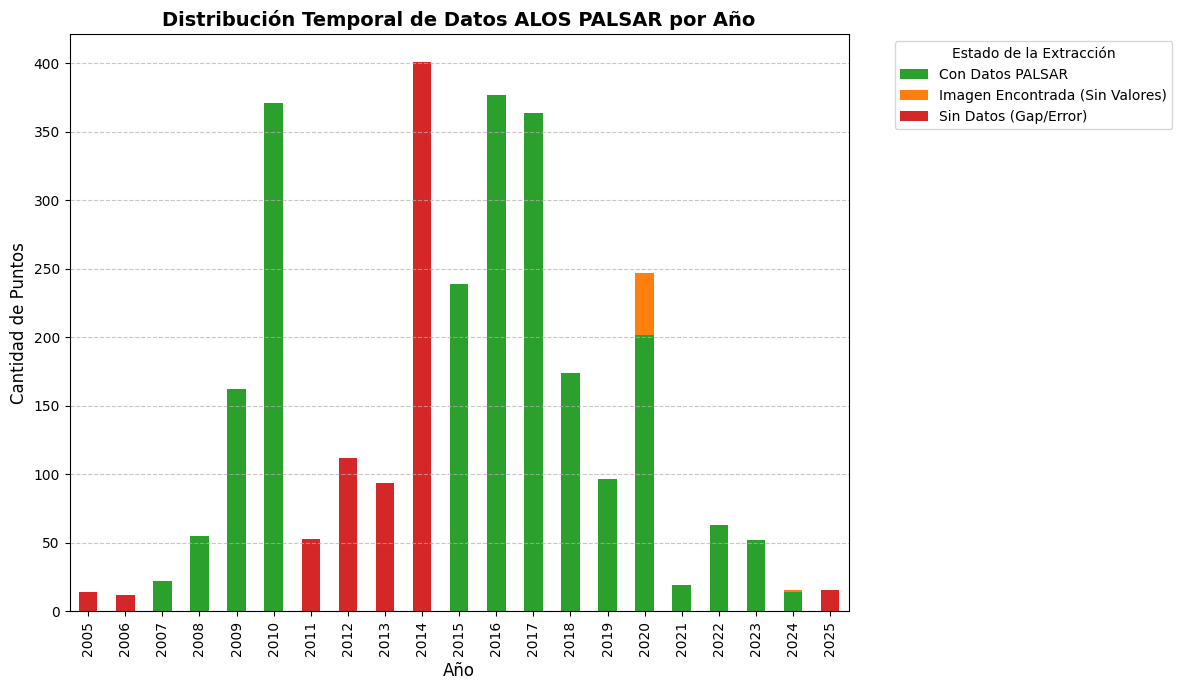

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load the PALSAR data
df_palsar = pd.read_csv('/content/drive/MyDrive/TESIS_GEE/Extracion_Consolidada_FinalajustadaV2.csv')

# Convert PALSAR_year to integer for better plotting
df_palsar['PALSAR_year'] = df_palsar['PALSAR_year'].fillna(0).astype(int)

# Group by year and PALSAR_ok status
# PALSAR_ok = 1 means success, 0 means no data found
# Let's also check where HH_mean_24d_25m is null vs not null within PALSAR_ok == 1
df_palsar['Status'] = 'Sin Datos (Gap/Error)'
df_palsar.loc[(df_palsar['PALSAR_ok'] == 1) & (df_palsar['HH_mean_24d_25m'].notnull()), 'Status'] = 'Con Datos PALSAR'
df_palsar.loc[(df_palsar['PALSAR_ok'] == 1) & (df_palsar['HH_mean_24d_25m'].isnull()), 'Status'] = 'Imagen Encontrada (Sin Valores)'

summary = df_palsar.groupby(['PALSAR_year', 'Status']).size().unstack(fill_value=0)

# Reorder status if they exist
cols = [c for c in ['Con Datos PALSAR', 'Imagen Encontrada (Sin Valores)', 'Sin Datos (Gap/Error)'] if c in summary.columns]
summary = summary[cols]

# Plotting
plt.figure(figsize=(12, 7))
summary.plot(kind='bar', stacked=True, color=['#2ca02c', '#ff7f0e', '#d62728'], ax=plt.gca())

plt.title('Distribución Temporal de Datos ALOS PALSAR por Año', fontsize=14, fontweight='bold')
plt.xlabel('Año', fontsize=12)
plt.ylabel('Cantidad de Puntos', fontsize=12)
plt.legend(title='Estado de la Extracción', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

plt.savefig('distribucion_temporal_palsar.png')



Encontrados: 2258, Con datos: 2211, Sin info: 749


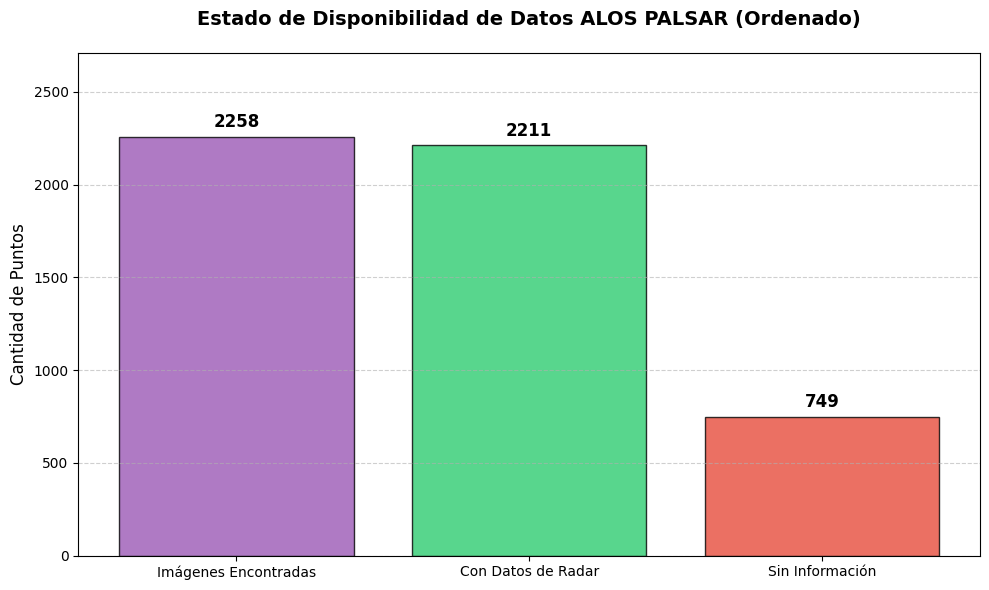

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Cargar el archivo procesado
df_palsar = pd.read_csv('/content/drive/MyDrive/TESIS_GEE/Extracion_Consolidada_FinalajustadaV2.csv')

# Cálculos dinámicos
total = len(df_palsar)
con_datos = df_palsar['HH_mean_24d_25m'].notnull().sum()
sin_info = total - con_datos
encontrados = int(df_palsar['PALSAR_ok'].sum())

# Reordenar: Sin Información al final
categorias = ['Imágenes Encontradas', 'Con Datos de Radar', 'Sin Información']
valores = [encontrados, con_datos, sin_info]
colores = ['#9b59b6', '#2ecc71', '#e74c3c']

# Creación del gráfico
plt.figure(figsize=(10, 6))
barras = plt.bar(categorias, valores, color=colores, edgecolor='black', alpha=0.8)

# Etiquetas de valores
for bar in barras:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 30, int(yval),
             ha='center', va='bottom', fontweight='bold', fontsize=12)

plt.title('Estado de Disponibilidad de Datos ALOS PALSAR (Ordenado)', fontsize=14, fontweight='bold', pad=20)
plt.ylabel('Cantidad de Puntos', fontsize=12)
plt.ylim(0, max(valores) * 1.2)
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig('resumen_palsar_final_ordenado.png')

print(f"Encontrados: {encontrados}, Con datos: {con_datos}, Sin info: {sin_info}")

# **GENERACIÓN DE DATASET CON VARIABLES DERIVADAS DE IMAGENES**

In [ ]:
# Importación de librerias y conexión con Google drive

import os, numpy as np, pandas as pd, geopandas as gpd, fiona

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
Datasetfinal = gpd.read_file('/content/drive/MyDrive/TESIS/DATASET_CAUCA/Final210226.gpkg', layer="DatasetFinal", driver="GPKG")
df_img = pd.read_csv('/content/drive/MyDrive/TESIS_GEE/Extracion_Consolidada_FinalajustadaV2.csv')

Datasetfinal.head(2)


,Codigo,P0_evento,P1_excl,P3_excl,P5_excl,P7_excl,P9_excl,P15_excl,P30_excl,P180_excl,...,Elevacion,CurvaturaN,CurvaturaT,TWI,Eastness,Northness,Pendiente,Acum_flujo,clase,geometry
0,40407,5.716318,2.570153,28.335768,71.649261,76.618492,83.014481,169.734161,341.425934,1687.828003,...,1590,-0.005164,-0.00117,5.094604,-0.905066,0.425272,20.912285,0.69897,1,POINT (-77.0871 1.69459)
1,40441,11.618964,40.066071,54.249153,68.398132,76.684601,102.450218,157.128922,364.965820,1713.425659,...,1590,-0.005164,-0.00117,5.094604,-0.905066,0.425272,20.912285,0.69897,1,POINT (-77.0871 1.69459)


In [ ]:
df_img.head(2)

,Codigo,Fecha_E,system:index,EVI_mean_90d_30m,EVI_std_90d_30m,HH_mean_24d_25m,HH_std_24d_25m,HHdivHV_24d_25m,HHminusHV_24d_25m,HV_mean_24d_25m,...,VVdivVH_24d_30m,VVminusVH_24d_30m,conf_BUFFER_M,conf_OPT_DAYS,conf_SAR_DAYS,date_str,.geo,HH_HV_db_stdDev,PALSAR_ok,PALSAR_year
0,40407,2017-03-25,0,0.430163,0.112358,-9.228485,3.164992,6.152597,6.152597,-15.381082,...,3.702644,5.685233,60,90,24,2017-03-25,"{""type"":""Point"",""coordinates"":[-77.08709596999...",3.285954,1,2017
1,40441,2017-03-31,1,0.430163,0.112358,-9.228485,3.164992,6.152597,6.152597,-15.381082,...,3.073026,4.875775,60,90,24,2017-03-31,"{""type"":""Point"",""coordinates"":[-77.08709596999...",3.285954,1,2017


In [ ]:
print("CSV filas:", len(df_img))
print("GPKG filas:", len(Datasetfinal))
print("CSV cols:", df_img.columns.tolist())
print("GPKG cols:", Datasetfinal.columns.tolist())


CSV filas: 2960
GPKG filas: 2960
CSV cols: ['Codigo', 'Fecha_E', 'system:index', 'EVI_mean_90d_30m', 'EVI_std_90d_30m', 'HH_mean_24d_25m', 'HH_std_24d_25m', 'HHdivHV_24d_25m', 'HHminusHV_24d_25m', 'HV_mean_24d_25m', 'HV_std_24d_25m', 'NBR_mean_90d_30m', 'NBR_std_90d_30m', 'NDVI_mean_90d_30m', 'NDVI_std_90d_30m', 'NDWI_mean_90d_30m', 'NDWI_std_90d_30m', 'OPT_src', 'OPT_valid_frac', 'SAR_sensor', 'SAR_src', 'SAR_valid_frac', 'VH_mean_24d_30m', 'VH_std_24d_30m', 'VV_mean_24d_30m', 'VV_std_24d_30m', 'VVdivVH_24d_30m', 'VVminusVH_24d_30m', 'conf_BUFFER_M', 'conf_OPT_DAYS', 'conf_SAR_DAYS', 'date_str', '.geo', 'HH_HV_db_stdDev', 'PALSAR_ok', 'PALSAR_year']
GPKG cols: ['Codigo', 'P0_evento', 'P1_excl', 'P3_excl', 'P5_excl', 'P7_excl', 'P9_excl', 'P15_excl', 'P30_excl', 'P180_excl', 'Latitud', 'Longitud', 'Humedad_T', 'Temp_T', 'Fecha_E', 'Dist_vias', 'Dist_DD', 'Dist_Falla', 'Geologia_U', 'Paisaje', 'Elevacion', 'CurvaturaN', 'CurvaturaT', 'TWI', 'Eastness', 'Northness', 'Pendiente', 'Acum_fl

In [ ]:
# Normalizar fechas a YYYY-MM-DD (soporta 'YYYY-MM-DD HH:MM:SS' y '5/10/2005')
dt1 = pd.to_datetime(Datasetfinal["Fecha_E"], errors="coerce", infer_datetime_format=True)
mask_na = dt1.isna()
dt2 = pd.to_datetime(Datasetfinal.loc[mask_na, "Fecha_E"], errors="coerce", dayfirst=True, infer_datetime_format=True)
dt1.loc[mask_na] = dt2

bad_dates = dt1.isna().sum()
if bad_dates > 0:
    print(f"⚠️ Fechas no interpretables: {bad_dates}")
    print("Ejemplos:", Datasetfinal.loc[dt1.isna(), "Fecha_E"].head(10).tolist())

Datasetfinal["Fecha_E"] = dt1.dt.strftime("%Y-%m-%d")
Datasetfinal = Datasetfinal.dropna(subset=["Fecha_E"]).copy()

# Listado de fechas adecuadas.
print("Filas finales (fecha válida):", len(Datasetfinal))
display(Datasetfinal.head(3))

#Guardar csv con solución del formato de fecha
Datasetfinal.to_file('/content/drive/MyDrive/TESIS/DATASET_CAUCA/Final120226ajusteV2.gpkg', layer="DatasetFinal", driver="GPKG")
print("\nGuardado:", '/content/drive/MyDrive/TESIS/DATASET_CAUCA/Final120226ajusteV2.gpkg')

Filas finales (fecha válida): 2960


,Codigo,P0_evento,P1_excl,P3_excl,P5_excl,P7_excl,P9_excl,P15_excl,P30_excl,P180_excl,...,Elevacion,CurvaturaN,CurvaturaT,TWI,Eastness,Northness,Pendiente,Acum_flujo,clase,geometry
0,40407,5.716318,2.570153,28.335768,71.649261,76.618492,83.014481,169.734161,341.425934,1687.828003,...,1590,-0.005164,-0.001170,5.094604,-0.905066,0.425272,20.912285,0.698970,1,POINT (-77.0871 1.69459)
1,40441,11.618964,40.066071,54.249153,68.398132,76.684601,102.450218,157.128922,364.965820,1713.425659,...,1590,-0.005164,-0.001170,5.094604,-0.905066,0.425272,20.912285,0.698970,1,POINT (-77.0871 1.69459)
2,40481,22.682497,26.044447,46.293716,58.558861,66.430016,74.460121,84.908333,220.069580,1503.159424,...,2073,-0.000451,-0.001463,6.600117,-0.999846,0.017541,25.411135,1.447158,1,POINT (-76.96338 1.8541)



Guardado: /content/drive/MyDrive/TESIS/DATASET_CAUCA/Final120226ajusteV2.gpkg


In [ ]:
def normalize_codigo(series):
    # Convertimos a numérico, redondeamos y pasamos a Int64 para quitar el .0
    temp = pd.to_numeric(series, errors="coerce").round(0).astype("Int64")
    # Limpiamos nulos y espacios en blanco
    return temp.astype(str).replace('<NA>', np.nan).str.strip()

# Aplicamos a los Códigos
df_img["Codigo"] = normalize_codigo(df_img["Codigo"])
Datasetfinal["Codigo"] = normalize_codigo(Datasetfinal["Codigo"])

In [ ]:
# 1. Asegurar que NO existan espacios ocultos en las llaves de ambos archivos
Datasetfinal["Codigo"] = Datasetfinal["Codigo"].astype(str).str.strip()
df_img["Codigo"] = df_img["Codigo"].astype(str).str.strip()

Datasetfinal["Fecha_E"] = Datasetfinal["Fecha_E"].astype(str).str.strip()
df_img["Fecha_E"] = df_img["Fecha_E"].astype(str).str.strip()

In [ ]:
# =======================================
# Selección de variables predictoras
# =======================================
opt_vars = [
    "EVI_mean_90d_30m","EVI_std_90d_30m",
    "NDVI_mean_90d_30m","NDVI_std_90d_30m",
    "NDWI_mean_90d_30m","NDWI_std_90d_30m",
    "NBR_mean_90d_30m","NBR_std_90d_30m",
]

s1_vars = [
    "VV_mean_24d_30m","VV_std_24d_30m",
    "VH_mean_24d_30m","VH_std_24d_30m",
    "VVdivVH_24d_30m","VVminusVH_24d_30m",
]

palsar_vars = [
    "HH_mean_24d_25m","HH_std_24d_25m",
    "HV_mean_24d_25m","HV_std_24d_25m",
    "HHdivHV_24d_25m","HHminusHV_24d_25m",
    "HH_HV_db_stdDev",
]

key_cols = ["Codigo", "Fecha_E"]

vars_keep = key_cols + opt_vars + s1_vars + palsar_vars
vars_keep_existing = [c for c in vars_keep if c in df_img.columns]

df_img1 = df_img[vars_keep_existing].copy()

# ============================================================
# Control de duplicados por (Codigo + Fecha_E)
# ============================================================
df_img1 = df_img1.drop_duplicates(subset=["Codigo","Fecha_E"], keep="first")

# ============================================================
# Se aplica Merge por Codigo + Fecha_E
# ============================================================
gdf_join = Datasetfinal.merge(
    df_img1,
    on=["Codigo","Fecha_E"],
    how="left",
    validate="1:1"
)

# ============================================================
# Auditoría rápida
# ============================================================
new_cols = [c for c in df_img1.columns if c not in ["Codigo","Fecha_E"]]

n_total = len(gdf_join)
n_any = gdf_join[new_cols].notna().any(axis=1).sum()

print(f"Total registros: {n_total}")
print(f"Registros con variables satelitales: {n_any} ({n_any/n_total:.2%})")

# ============================================================
# Guardar GPKG final
# ============================================================
out_gpkg  = "/content/drive/MyDrive/TESIS/DATASET_CAUCA/Final_vars_satelitalesajusteV2_240226.gpkg"
out_layer= "DatasetFinalVar"
gdf_join.to_file(out_gpkg, layer=out_layer, driver="GPKG")
print("Guardado en:", out_gpkg)



Total registros: 2960
Registros con variables satelitales: 2763 (93.34%)
Guardado en: /content/drive/MyDrive/TESIS/DATASET_CAUCA/Final_vars_satelitalesajusteV2_240226.gpkg


In [ ]:
Datasetfinal2 = gpd.read_file('/content/drive/MyDrive/TESIS/DATASET_CAUCA/Final_vars_satelitalesajusteV2_240226.gpkg')


In [ ]:
Datasetfinal2.head(2)


,Codigo,P0_evento,P1_excl,P3_excl,P5_excl,P7_excl,P9_excl,P15_excl,P30_excl,P180_excl,...,VVdivVH_24d_30m,VVminusVH_24d_30m,HH_mean_24d_25m,HH_std_24d_25m,HV_mean_24d_25m,HV_std_24d_25m,HHdivHV_24d_25m,HHminusHV_24d_25m,HH_HV_db_stdDev,geometry
0,40407,5.716318,2.570153,28.335768,71.649261,76.618492,83.014481,169.734161,341.425934,1687.828003,...,3.702644,5.685233,-9.228485,3.164992,-15.381082,3.55894,6.152597,6.152597,3.285954,POINT (-77.0871 1.69459)
1,40441,11.618964,40.066071,54.249153,68.398132,76.684601,102.450218,157.128922,364.965820,1713.425659,...,3.073026,4.875775,-9.228485,3.164992,-15.381082,3.55894,6.152597,6.152597,3.285954,POINT (-77.0871 1.69459)


In [ ]:
Datasetfinal2.columns

Index(['Codigo', 'P0_evento', 'P1_excl', 'P3_excl', 'P5_excl', 'P7_excl',
       'P9_excl', 'P15_excl', 'P30_excl', 'P180_excl', 'Latitud', 'Longitud',
       'Humedad_T', 'Temp_T', 'Fecha_E', 'Dist_vias', 'Dist_DD', 'Dist_Falla',
       'Geologia_U', 'Paisaje', 'Elevacion', 'CurvaturaN', 'CurvaturaT', 'TWI',
       'Eastness', 'Northness', 'Pendiente', 'Acum_flujo', 'clase',
       'EVI_mean_90d_30m', 'EVI_std_90d_30m', 'NDVI_mean_90d_30m',
       'NDVI_std_90d_30m', 'NDWI_mean_90d_30m', 'NDWI_std_90d_30m',
       'NBR_mean_90d_30m', 'NBR_std_90d_30m', 'VV_mean_24d_30m',
       'VV_std_24d_30m', 'VH_mean_24d_30m', 'VH_std_24d_30m',
       'VVdivVH_24d_30m', 'VVminusVH_24d_30m', 'HH_mean_24d_25m',
       'HH_std_24d_25m', 'HV_mean_24d_25m', 'HV_std_24d_25m',
       'HHdivHV_24d_25m', 'HHminusHV_24d_25m', 'HH_HV_db_stdDev', 'geometry'],
      dtype='object')

In [ ]:
Datasetfinal2.shape

(2960, 51)

In [ ]:
# ============================================================
# 1. CORREGIR NOTEBOOK PARA GITHUB SIN BORRAR SALIDAS
# ============================================================
from google.colab import drive
drive.mount('/content/drive')
import nbformat
from pathlib import Path
import shutil

# Ruta del notebook original en Drive
ruta_original = Path("/content/drive/MyDrive/Colab Notebooks/Dataset_imagenessatelitales.ipynb")

# Crear una copia corregida para GitHub
ruta_corregida = ruta_original.with_name(ruta_original.stem + "_GH.ipynb")

# Crear copia de seguridad adicional
ruta_backup = ruta_original.with_name(ruta_original.stem + "_BACKUP.ipynb")
shutil.copy(ruta_original, ruta_backup)

# Leer notebook
nb = nbformat.read(ruta_original, as_version=4)

# Eliminar SOLO el metadato problemático
# Esto NO borra salidas, gráficos, tablas ni resultados de celdas
nb.metadata.pop("widgets", None)

# Guardar versión corregida
nbformat.write(nb, ruta_corregida)

print("Notebook corregido correctamente.")
print("Archivo original:", ruta_original)
print("Copia de seguridad:", ruta_backup)
print("Archivo para subir a GitHub:", ruta_corregida)

Mounted at /content/drive
Notebook corregido correctamente.
Archivo original: /content/drive/MyDrive/Colab Notebooks/GENERACIONPUNTOS_NO DESLIZAMIENTOSV2.ipynb
Copia de seguridad: /content/drive/MyDrive/Colab Notebooks/GENERACIONPUNTOS_NO DESLIZAMIENTOSV2_BACKUP.ipynb
Archivo para subir a GitHub: /content/drive/MyDrive/Colab Notebooks/GENERACIONPUNTOS_NO DESLIZAMIENTOSV2_GH.ipynb
